## Load and Preprocess the Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Number of rows from each downloaded dataset
NROWS = 10000000

# Define the file paths
file_paths = {
    'title_basics': '../data/download/title.basics.tsv',
    'title_akas': '../data/download/title.akas.tsv',
    'title_crew': '../data/download/title.crew.tsv',
    'title_episode': '../data/download/title.episode.tsv',
    'title_principals': '../data/download/title.principals.tsv',
    'title_ratings': '../data/download/title.ratings.tsv',
    'name_basics': '../data/download/name.basics.tsv',
}

# Read the first NROWS from the datasets
df_title_basics = pd.read_csv(file_paths['title_basics'], delimiter='\t', nrows=NROWS, na_values='\\N')
df_title_ratings = pd.read_csv(file_paths['title_ratings'], delimiter='\t', nrows=NROWS, na_values='\\N')

# Merge the datasets on 'tconst'
df = pd.merge(df_title_basics, df_title_ratings, on='tconst')

# 1. Data Exploration
def explore_data(df):
    """Basic exploration of the dataset."""
    print("\nDataset Head:\n", df.head())
    print("\nDataset Info:\n")
    df.info()
    print("\nSummary Statistics:\n", df.describe())

# 2. Data Cleaning
def clean_data(df):
    """Clean and preprocess the dataset."""
    df = df.dropna(subset=['startYear', 'averageRating'])  # Drop rows with missing years or ratings
    df['startYear'] = df['startYear'].astype(int)         # Convert Year to integer
    df['averageRating'] = df['averageRating'].astype(float) # Ensure Rating is float
    return df

# 3. Visualization
def visualize_trends(df):
    """Visualize trends in the dataset."""
    plt.figure(figsize=(12, 6))
    
    # Average Rating Over Time
    avg_rating = df.groupby('startYear')['averageRating'].mean()
    plt.plot(avg_rating.index, avg_rating.values, marker='o', label='Average Rating')
    plt.title('Average Film Rating Over Time')
    plt.xlabel('Year')
    plt.ylabel('Average Rating')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # Count of Films Per Year
    film_count = df.groupby('startYear').size()
    plt.figure(figsize=(12, 6))
    plt.bar(film_count.index, film_count.values, color='skyblue', label='Film Count')
    plt.title('Number of Films Released Per Year')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

# 4. Prediction (Simple Linear Regression)
def predict_trends(df):
    """Predict future trends using Linear Regression."""
    data = df.groupby('startYear')['averageRating'].mean().reset_index()
    X = data['startYear'].values.reshape(-1, 1)
    y = data['averageRating'].values

    model = LinearRegression()
    model.fit(X, y)
    
    future_years = np.arange(data['startYear'].max() + 1, data['startYear'].max() + 6).reshape(-1, 1)
    predictions = model.predict(future_years)

    plt.figure(figsize=(12, 6))
    plt.plot(data['startYear'], y, marker='o', label='Historical Ratings')
    plt.plot(future_years, predictions, marker='x', linestyle='--', label='Predicted Ratings', color='red')
    plt.title('Predicted Average Film Ratings')
    plt.xlabel('Year')
    plt.ylabel('Average Rating')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Predicted Ratings for Future Years:\n")
    for year, rating in zip(future_years.flatten(), predictions):
        print(f"Year {year}: {rating:.2f}")

/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_11752/63746669.py:21: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_title_basics = pd.read_csv(file_paths['title_basics'], delimiter='\t', nrows=NROWS, na_values='\\N')



Dataset Head:
       tconst titleType            primaryTitle           originalTitle  \
0  tt0000001     short              Carmencita              Carmencita   
1  tt0000002     short  Le clown et ses chiens  Le clown et ses chiens   
2  tt0000003     short            Poor Pierrot          Pauvre Pierrot   
3  tt0000004     short             Un bon bock             Un bon bock   
4  tt0000005     short        Blacksmith Scene        Blacksmith Scene   

   isAdult  startYear  endYear runtimeMinutes                    genres  \
0      0.0     1894.0      NaN            1.0         Documentary,Short   
1      0.0     1892.0      NaN            5.0           Animation,Short   
2      0.0     1892.0      NaN            5.0  Animation,Comedy,Romance   
3      0.0     1892.0      NaN           12.0           Animation,Short   
4      0.0     1893.0      NaN            1.0                     Short   

   averageRating  numVotes  
0            5.7      2116  
1            5.6       285  
2

/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_11752/63746669.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['startYear'] = df['startYear'].astype(int)         # Convert Year to integer
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_11752/63746669.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['averageRating'] = df['averageRating'].astype(float) # Ensure Rating is float


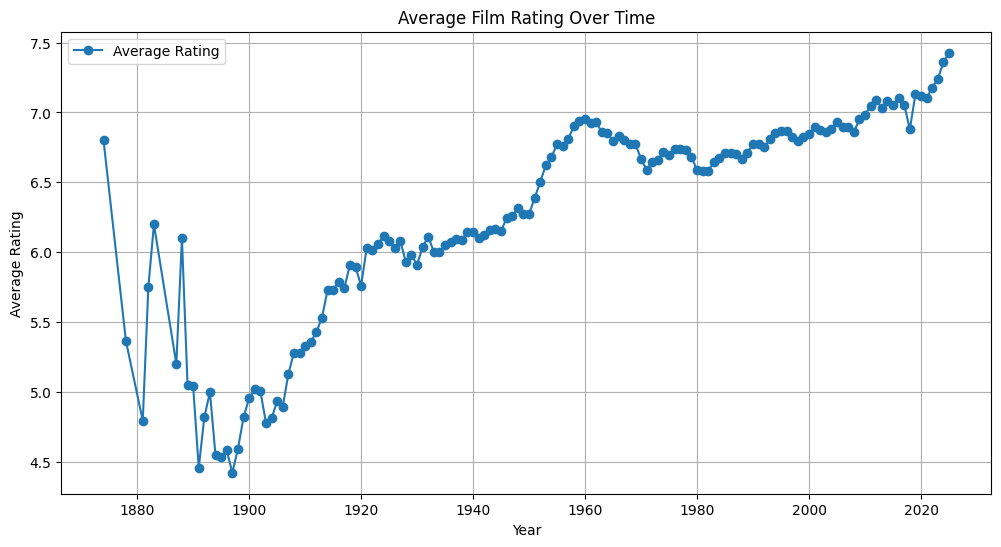

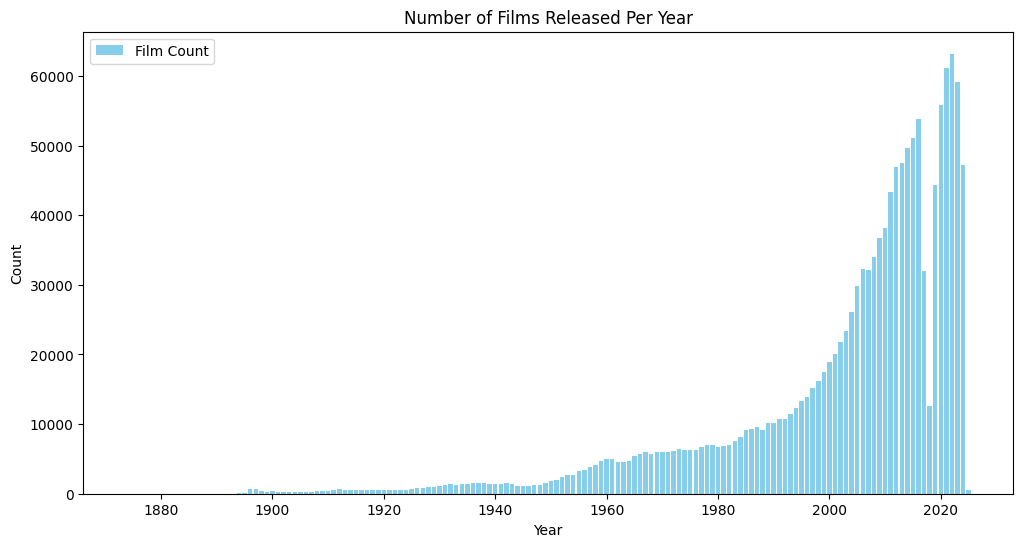

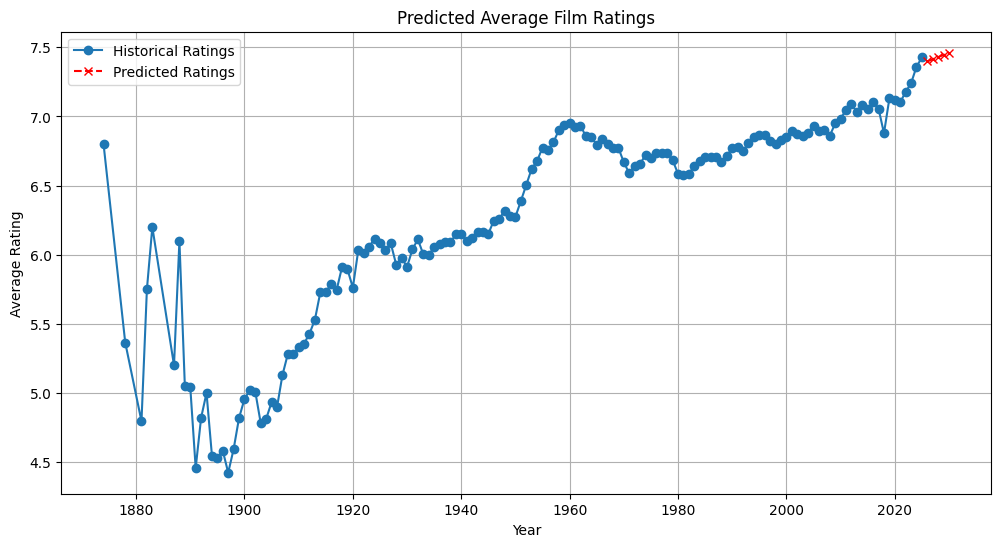

Predicted Ratings for Future Years:

Year 2026: 7.40
Year 2027: 7.41
Year 2028: 7.43
Year 2029: 7.45
Year 2030: 7.46


In [11]:
# Load and preprocess data
explore_data(df)
df = clean_data(df)

# Visualize trends
visualize_trends(df)

# Predict trends
predict_trends(df)

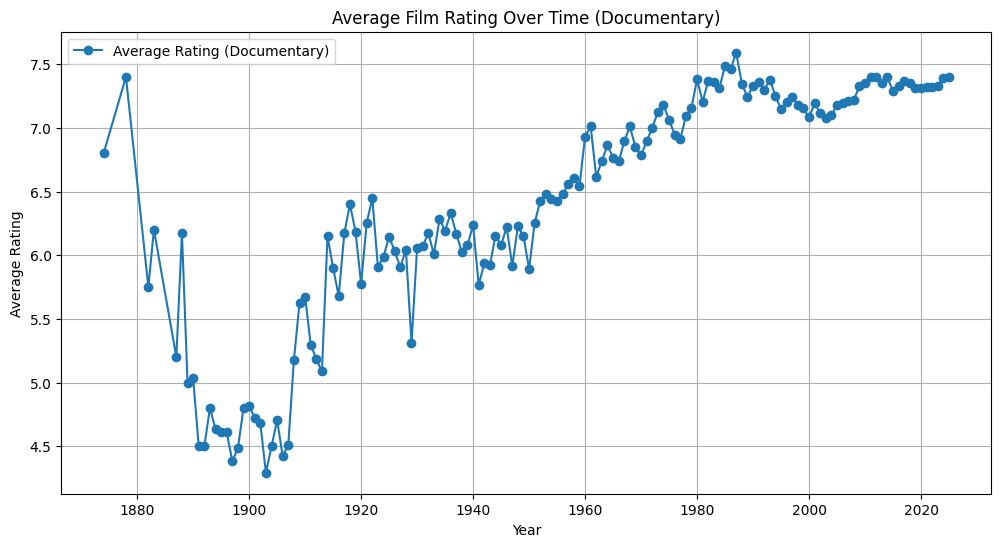

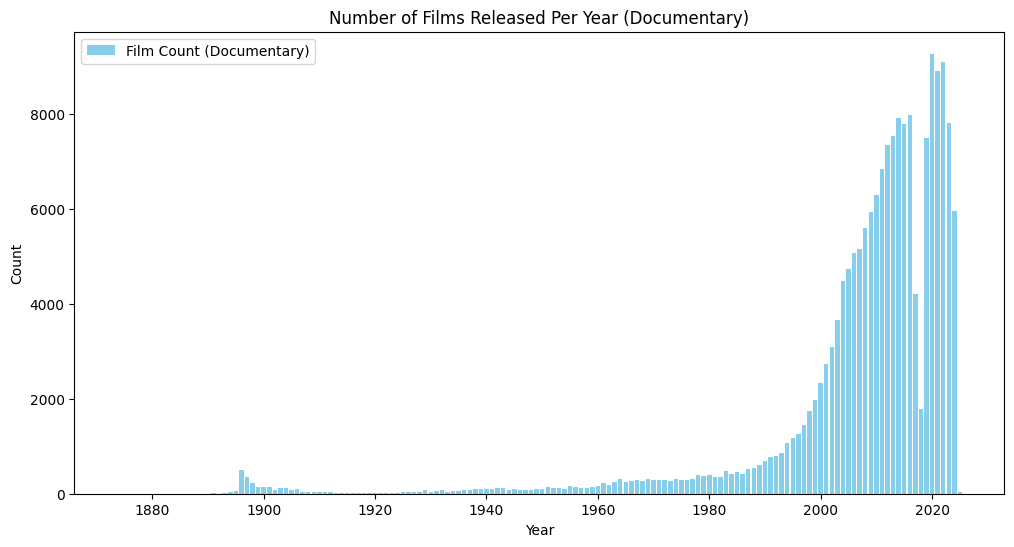

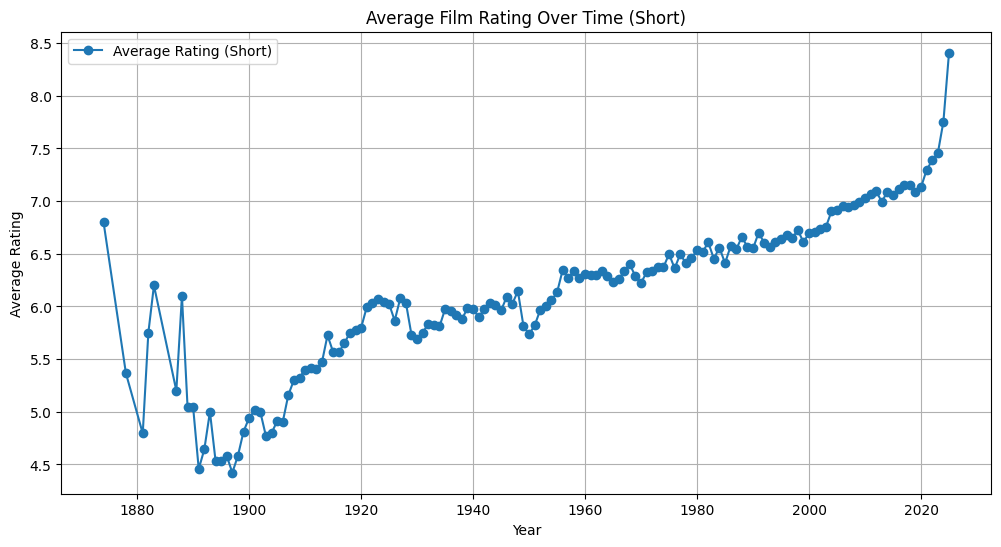

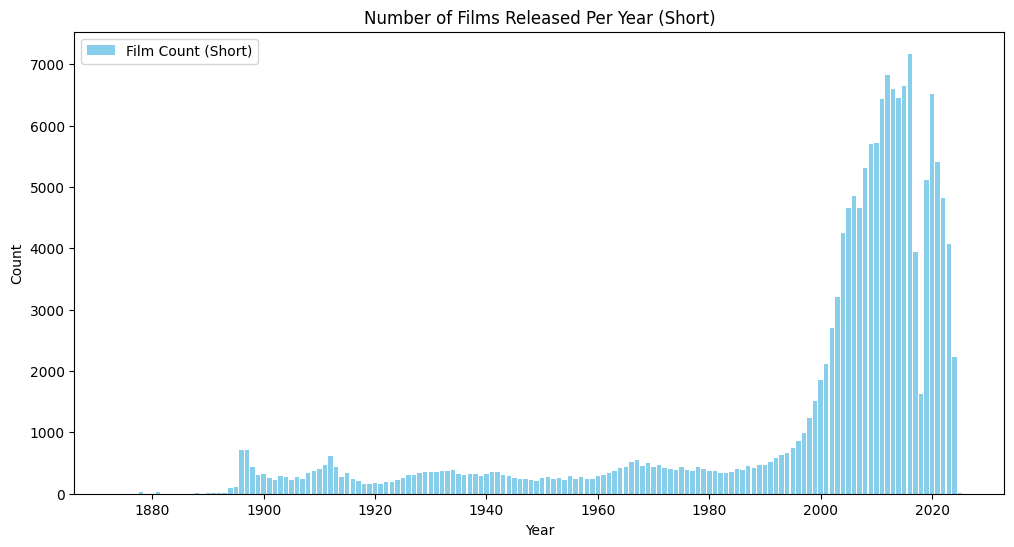

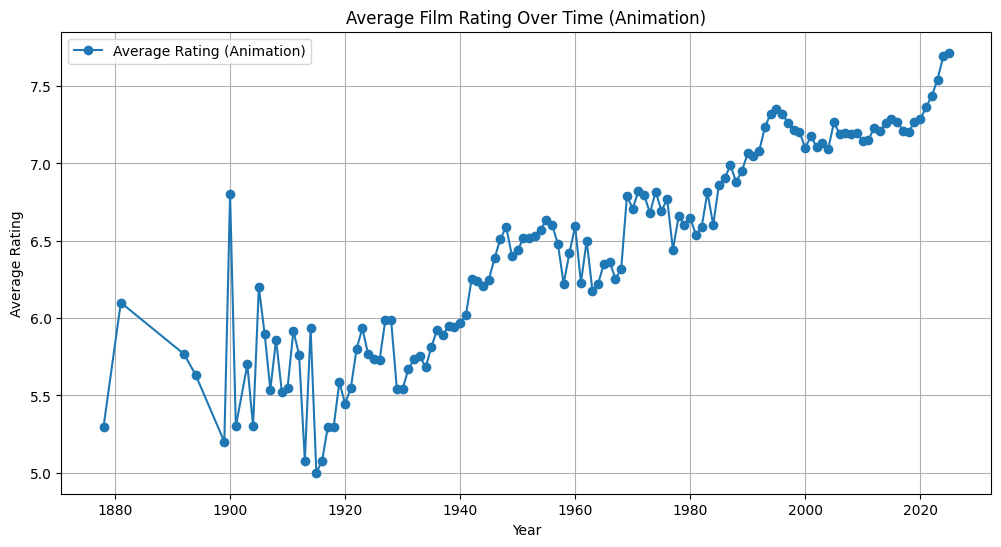

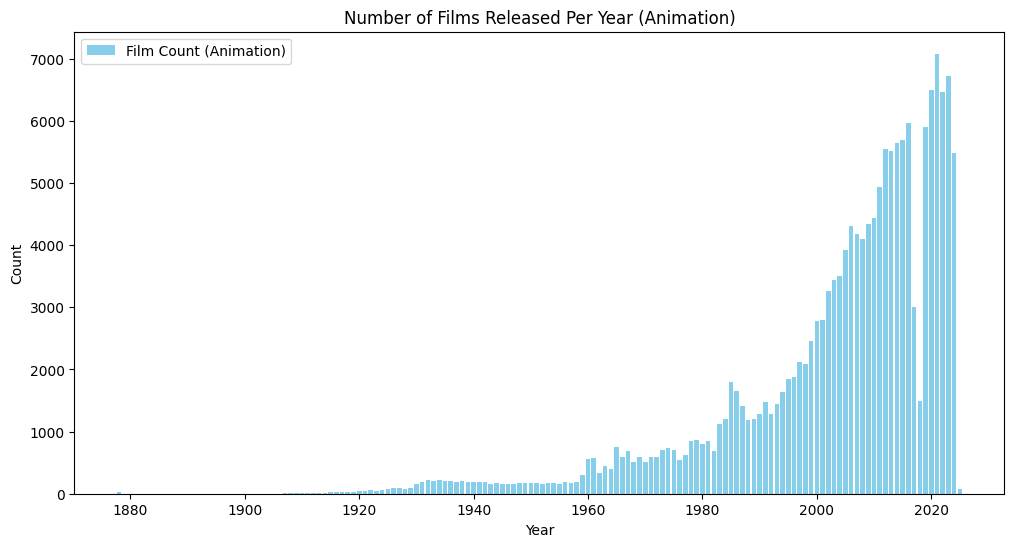

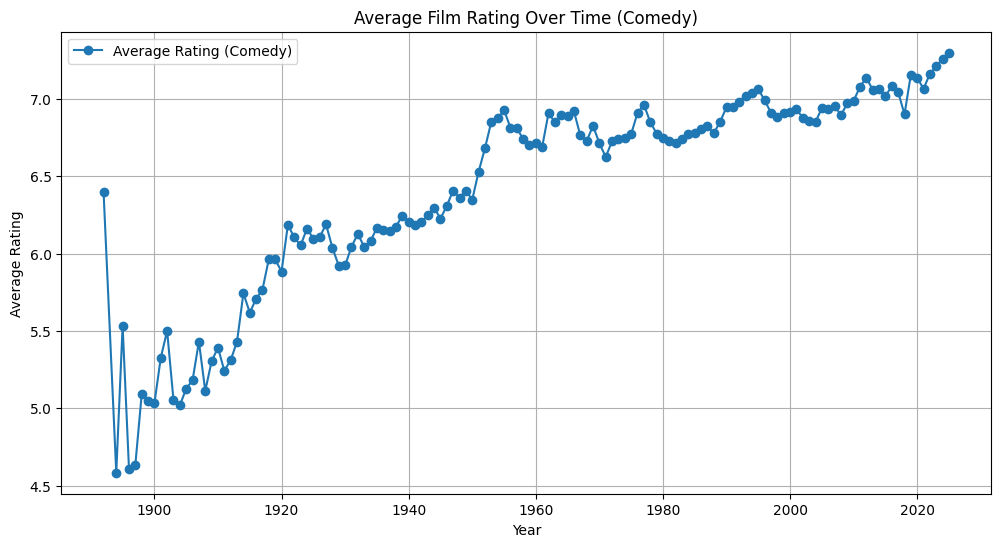

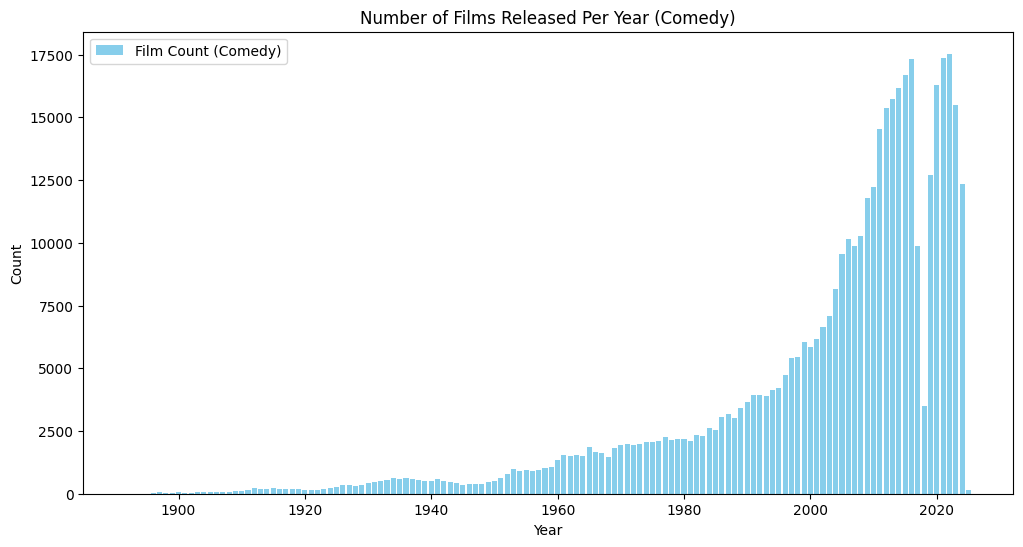

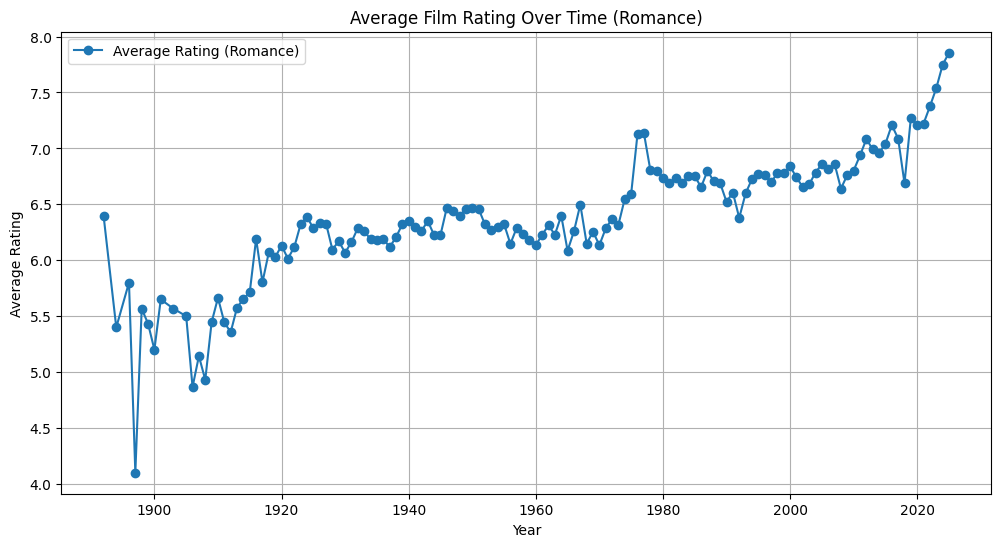

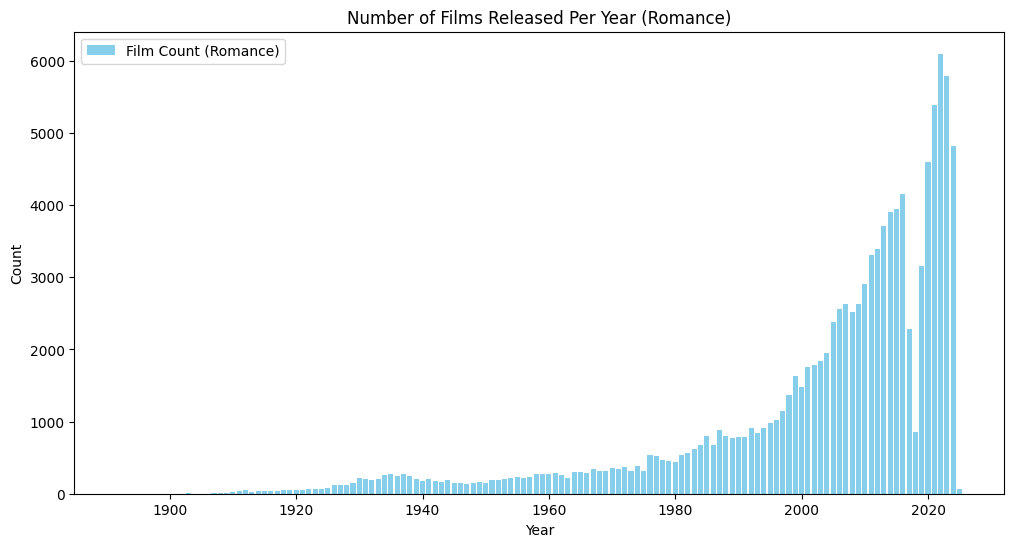

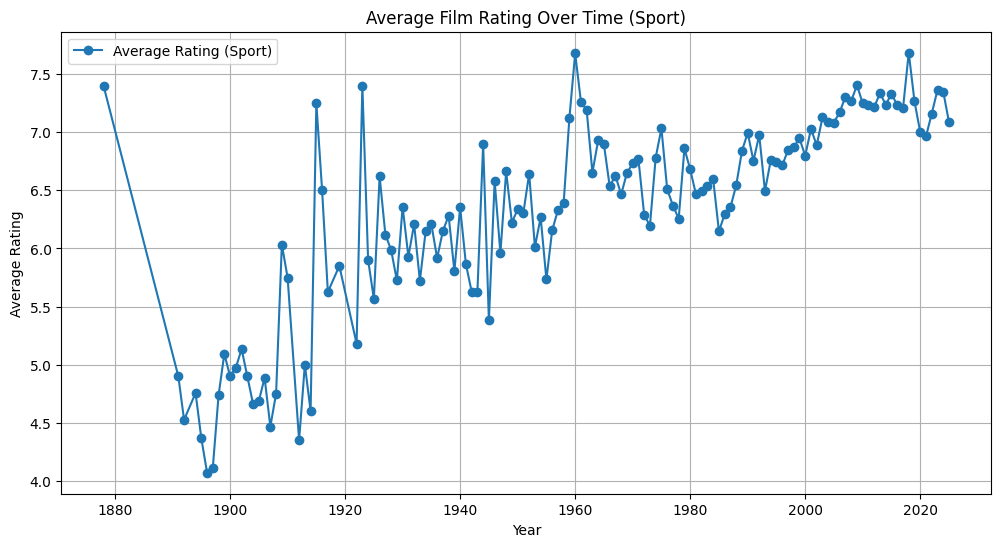

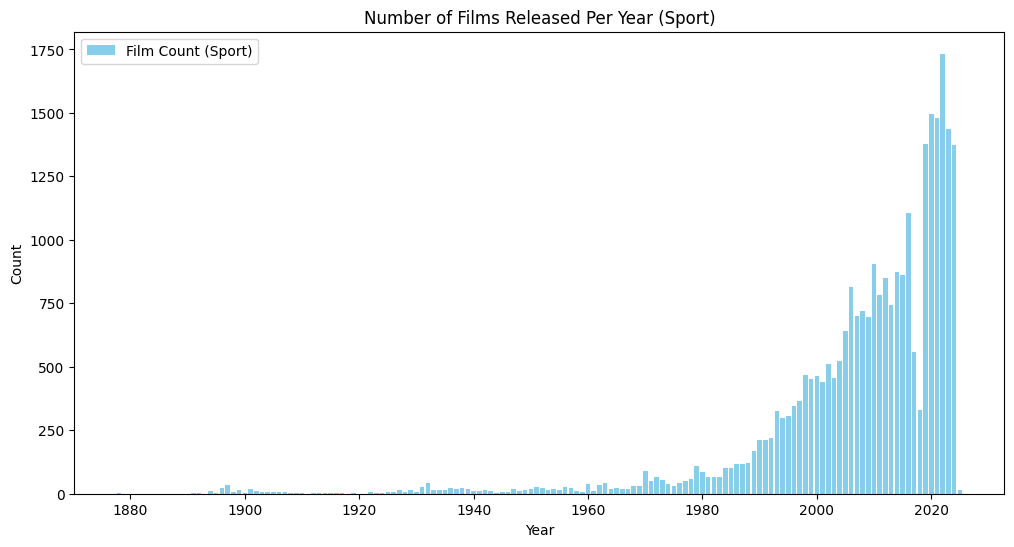

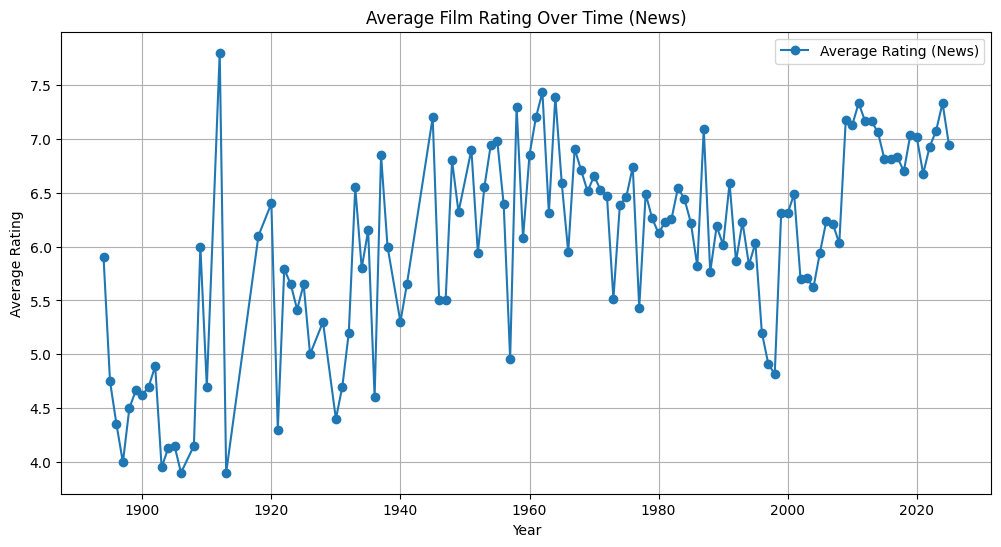

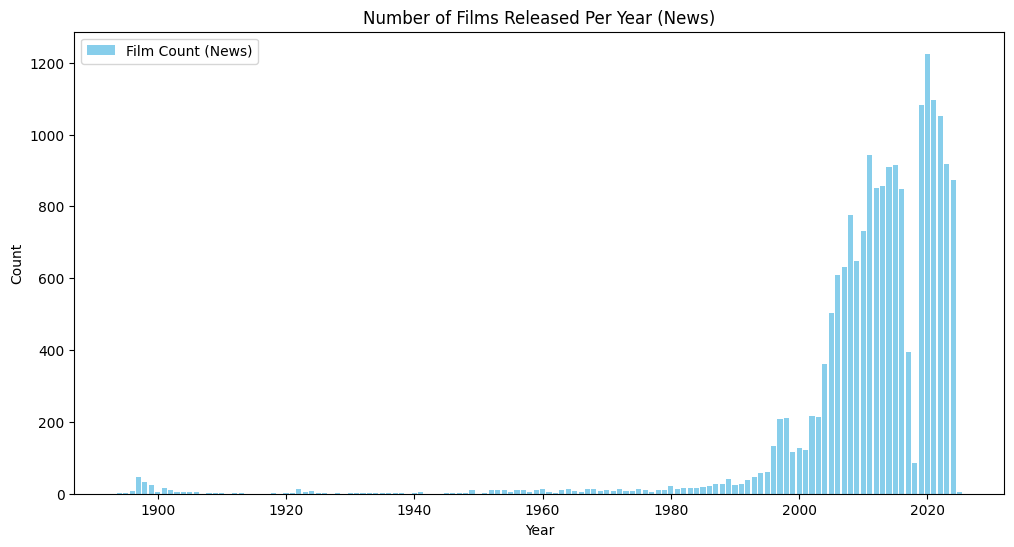

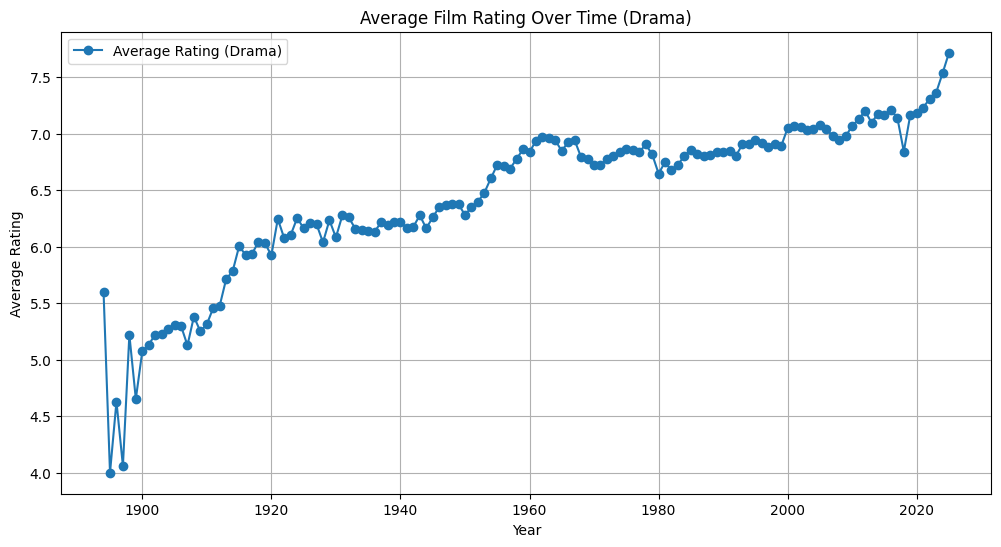

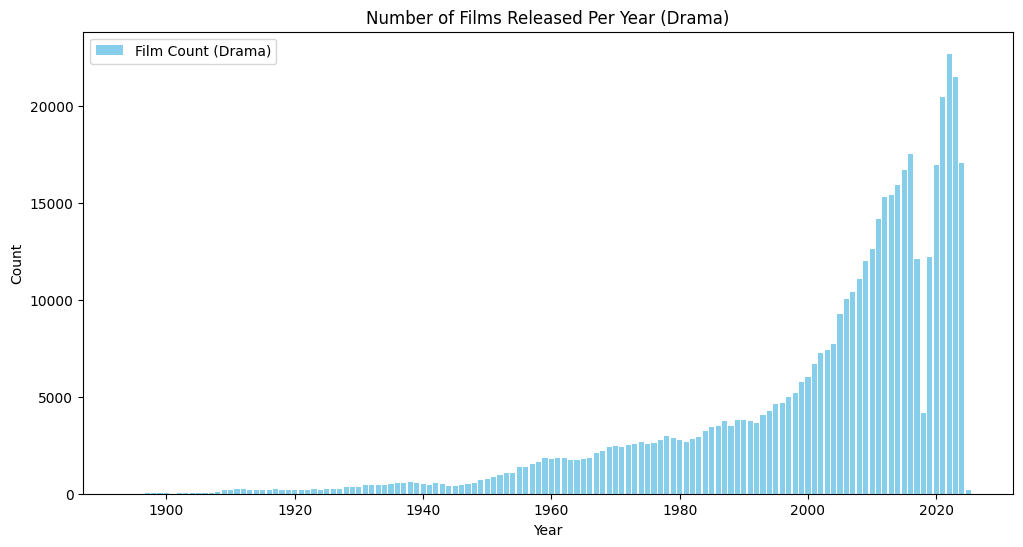

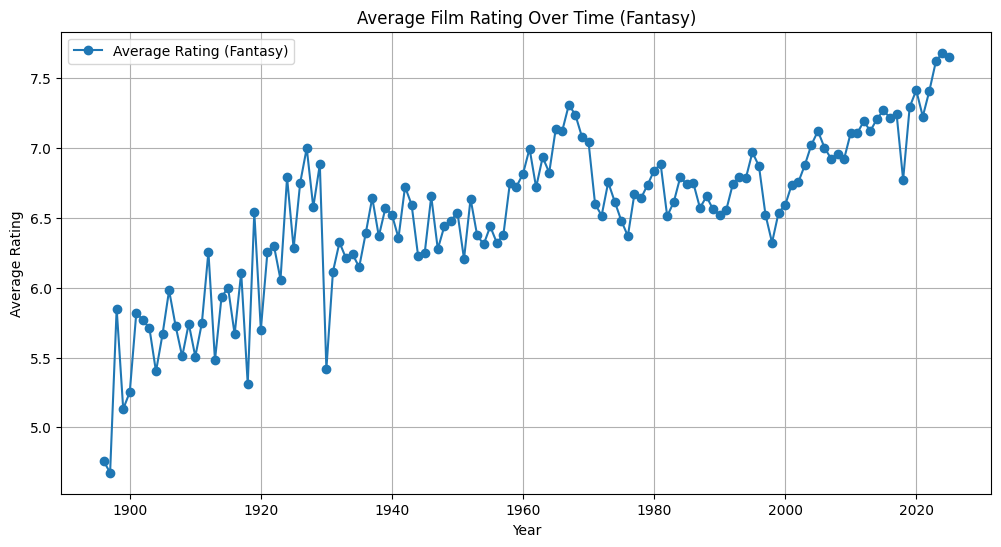

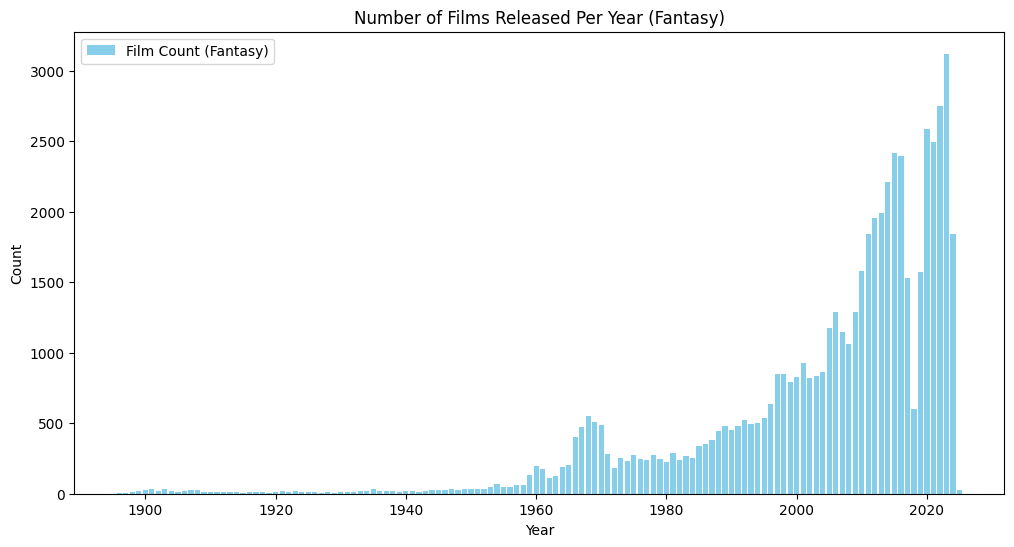

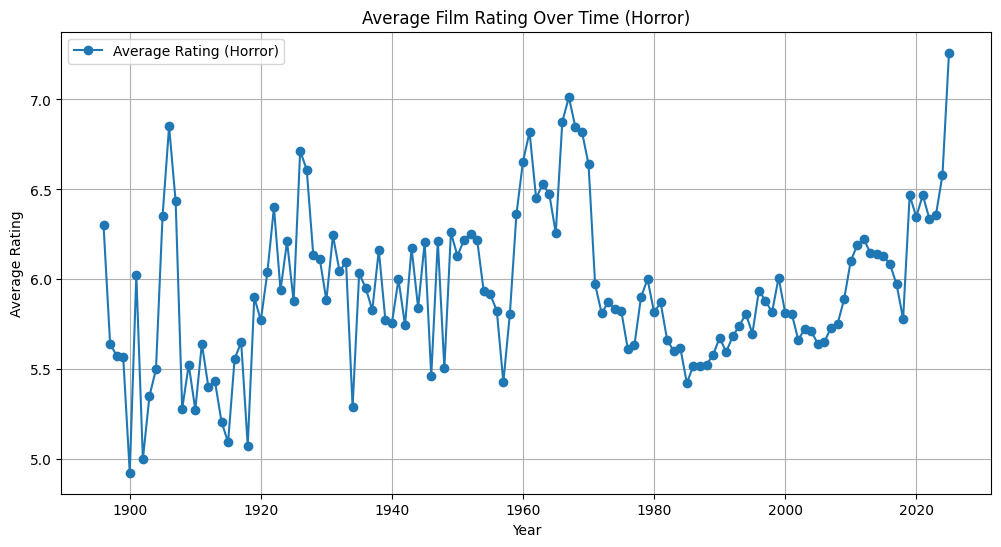

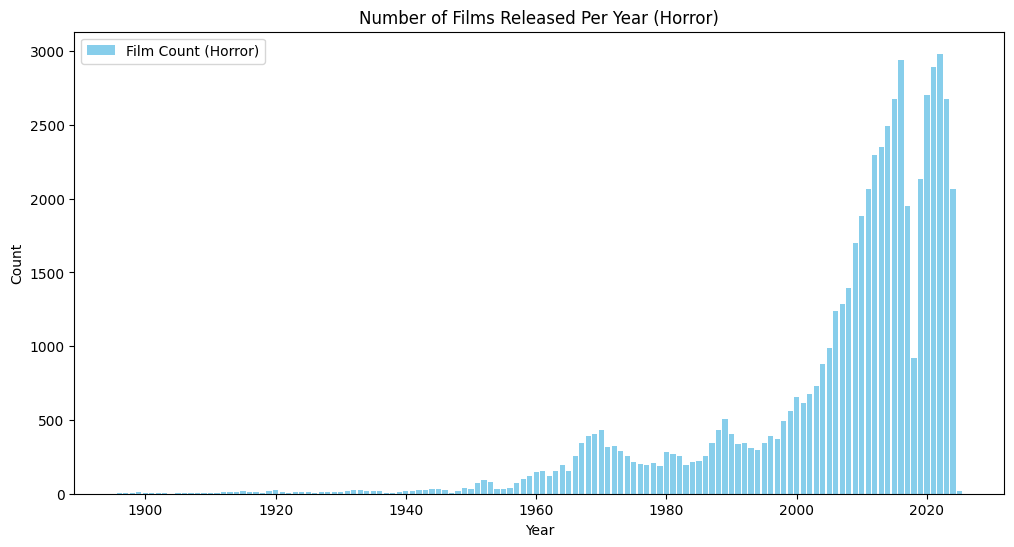

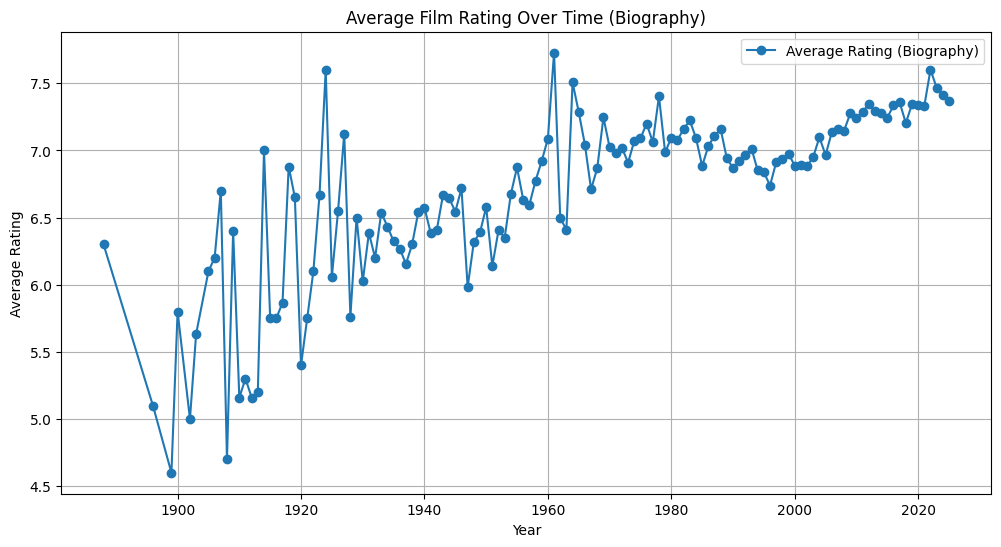

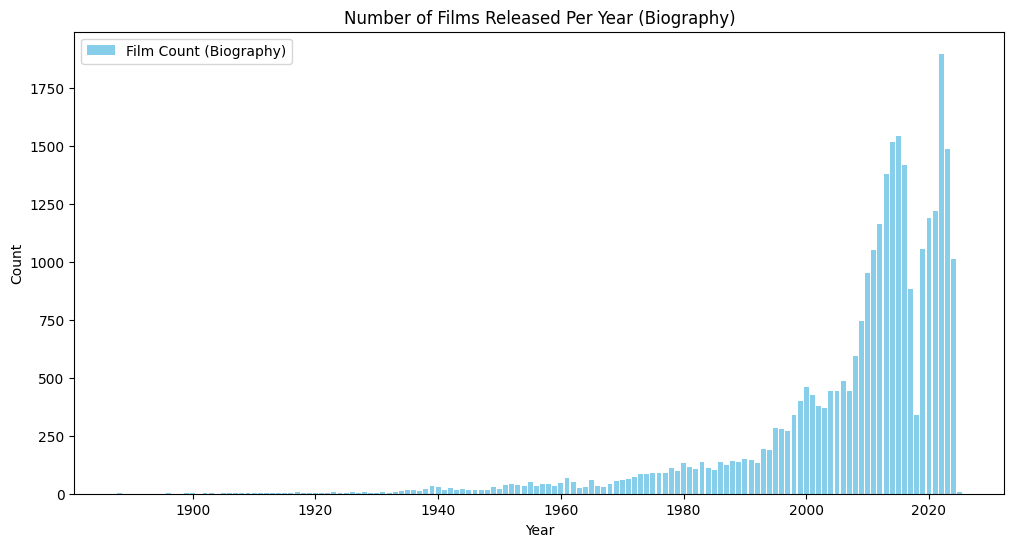

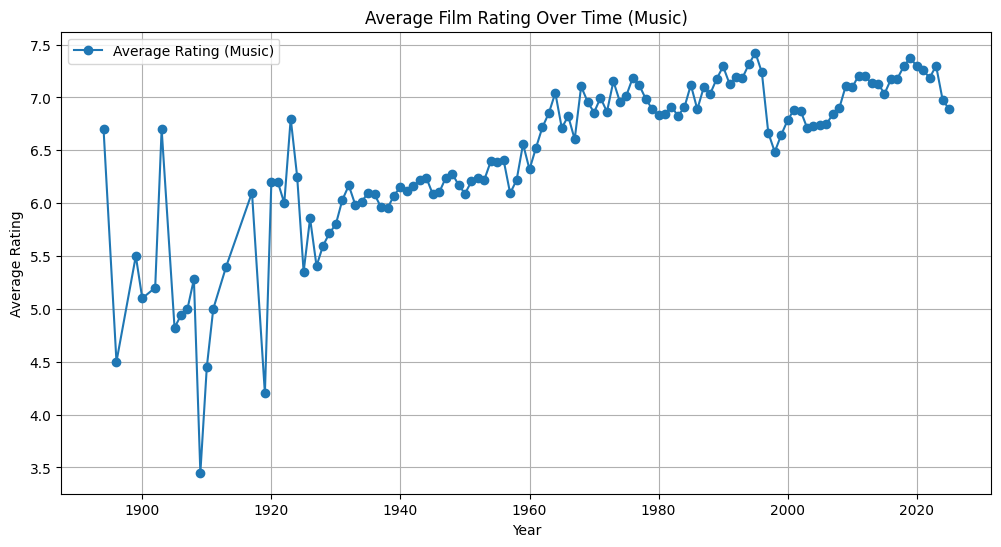

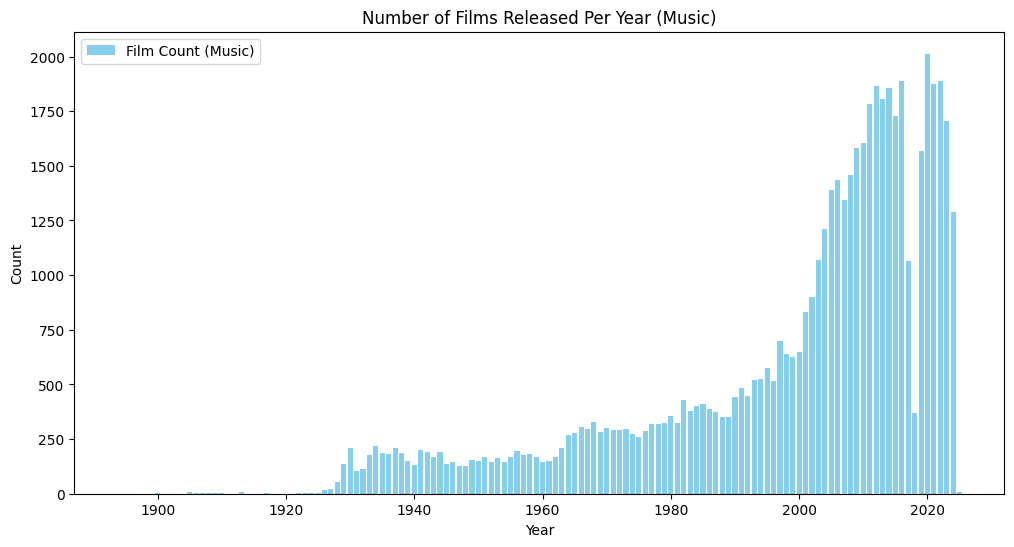

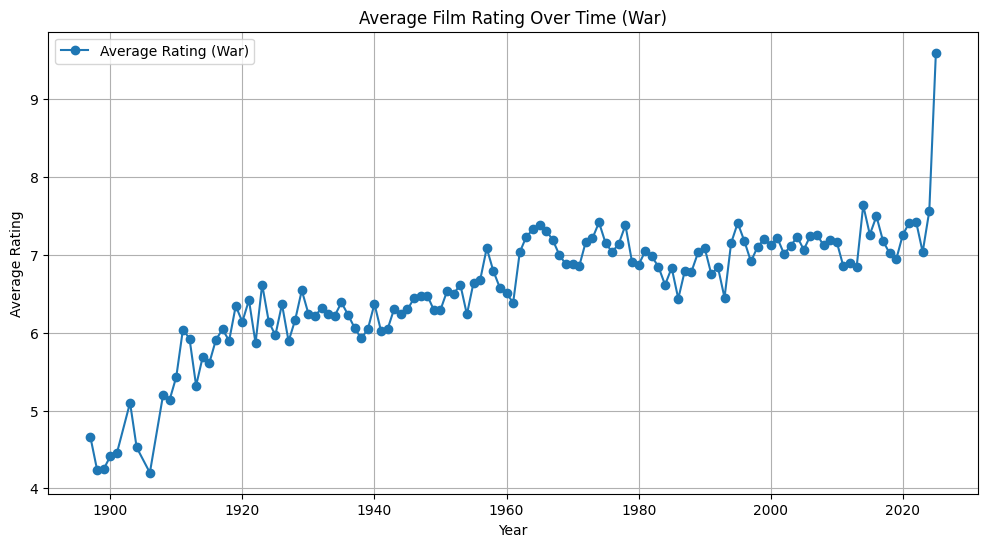

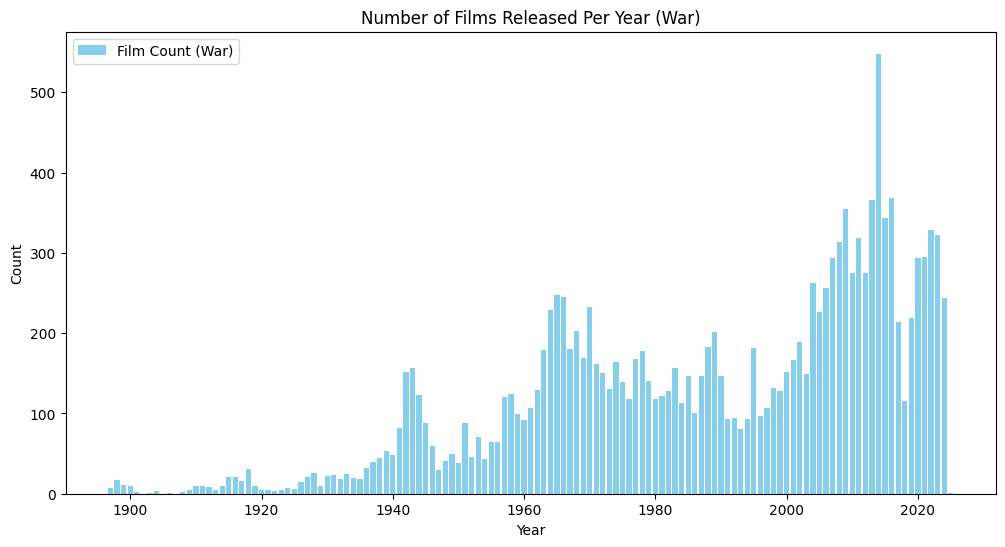

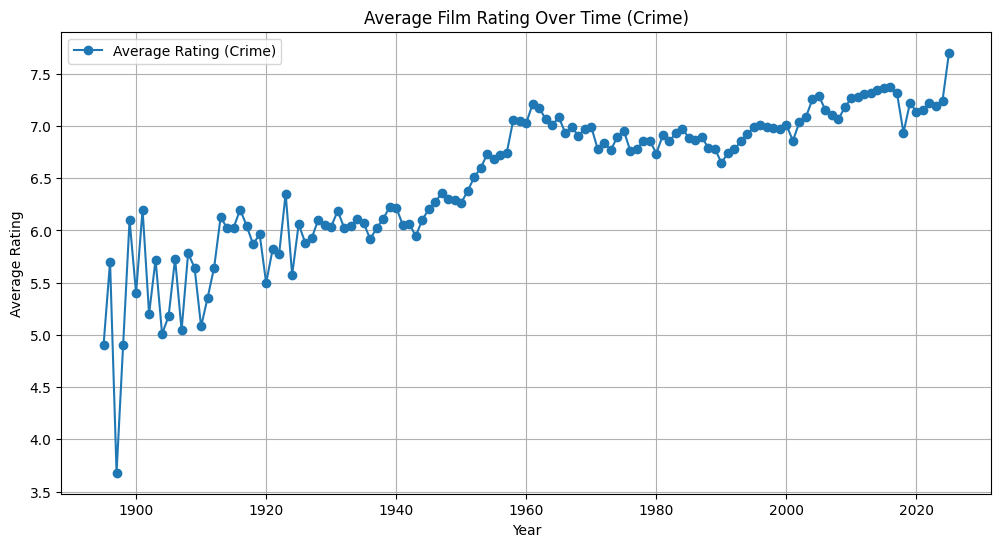

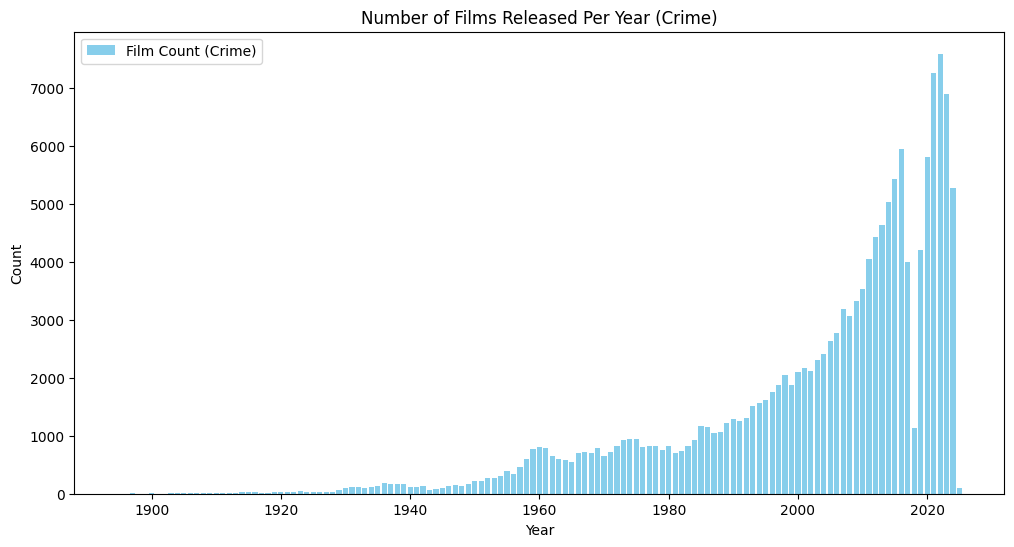

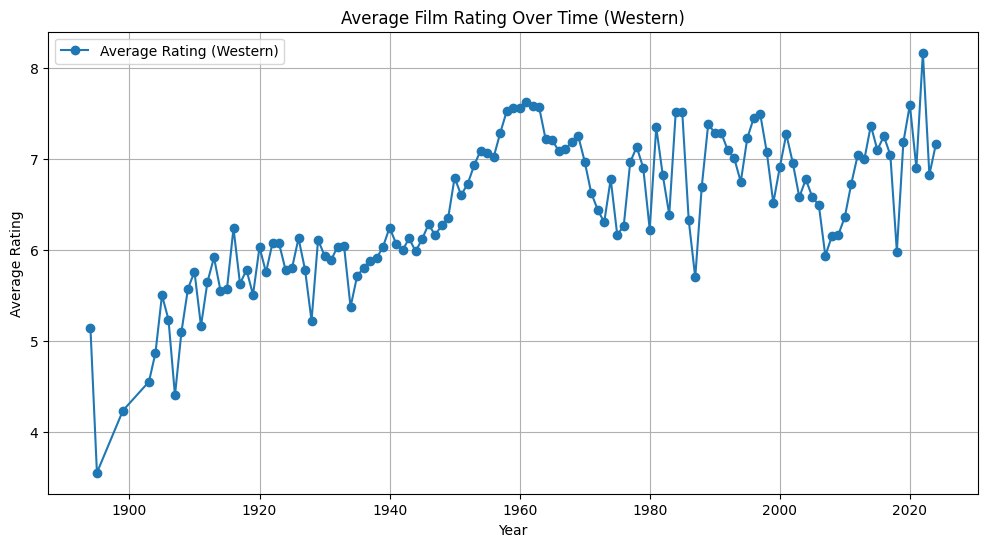

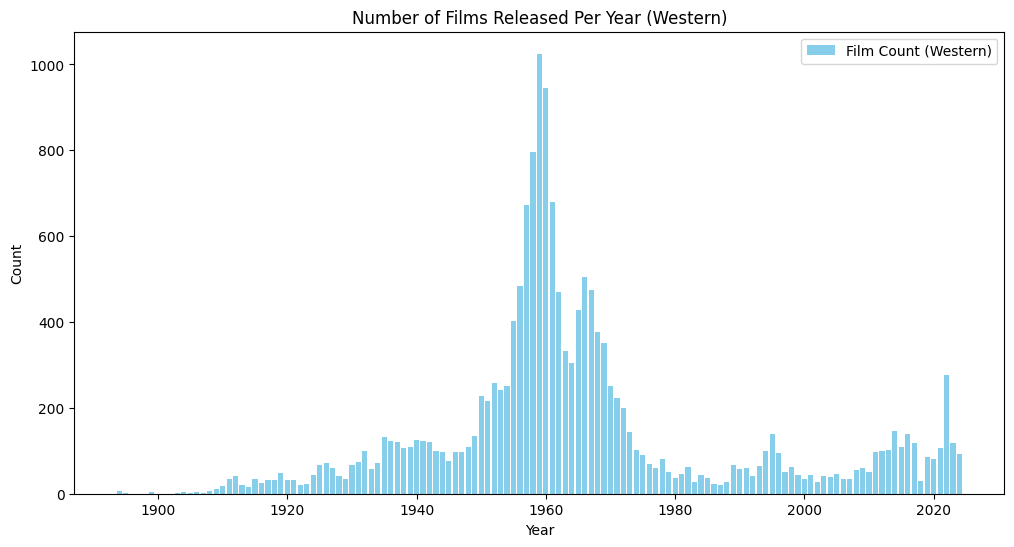

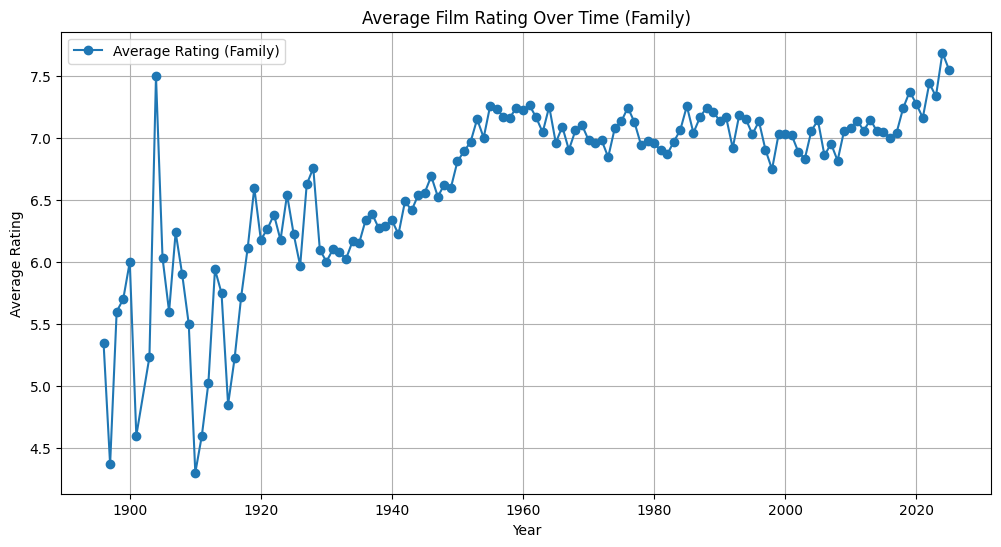

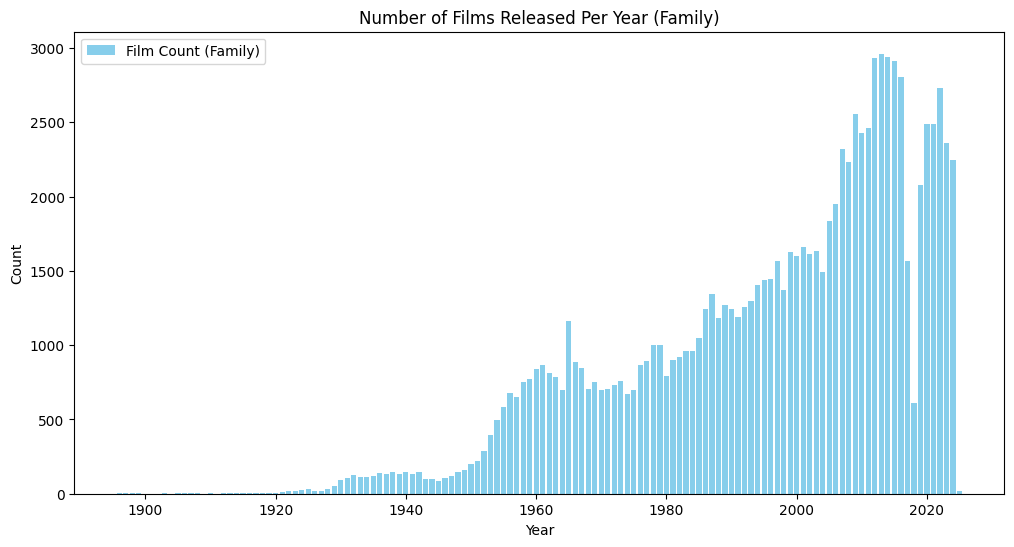

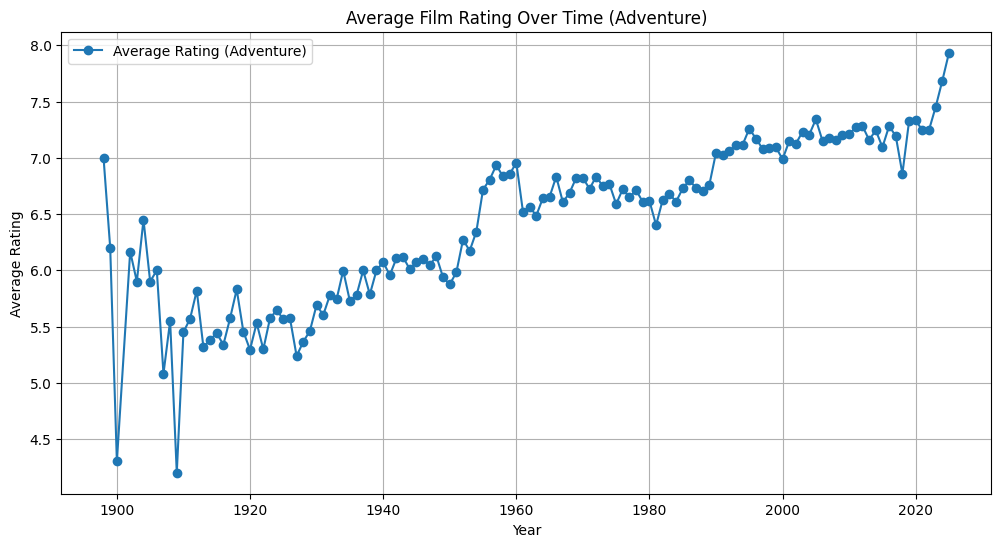

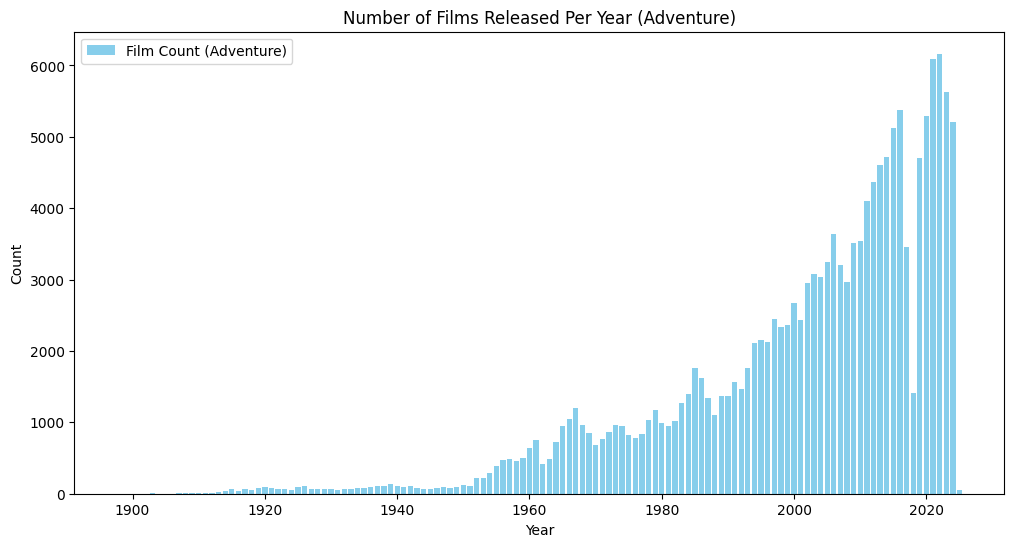

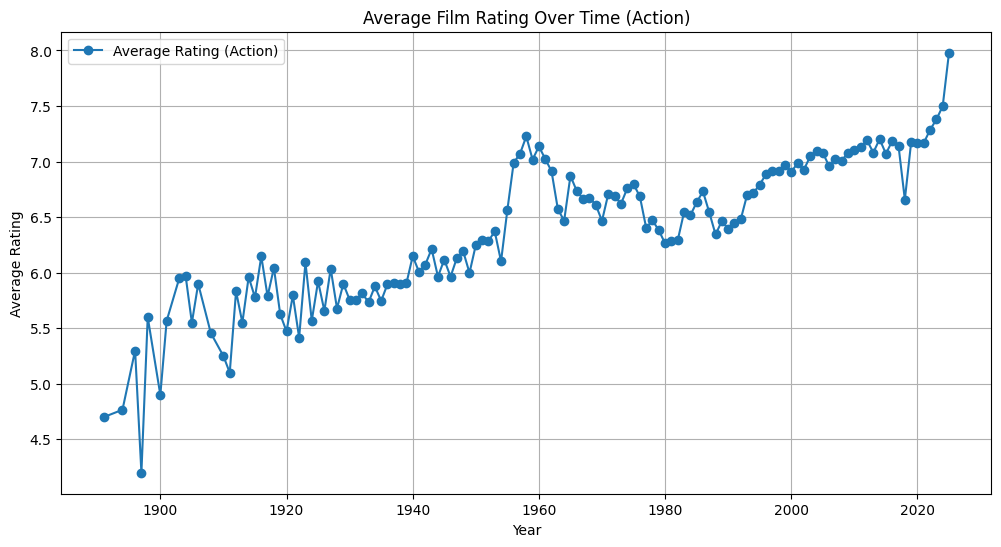

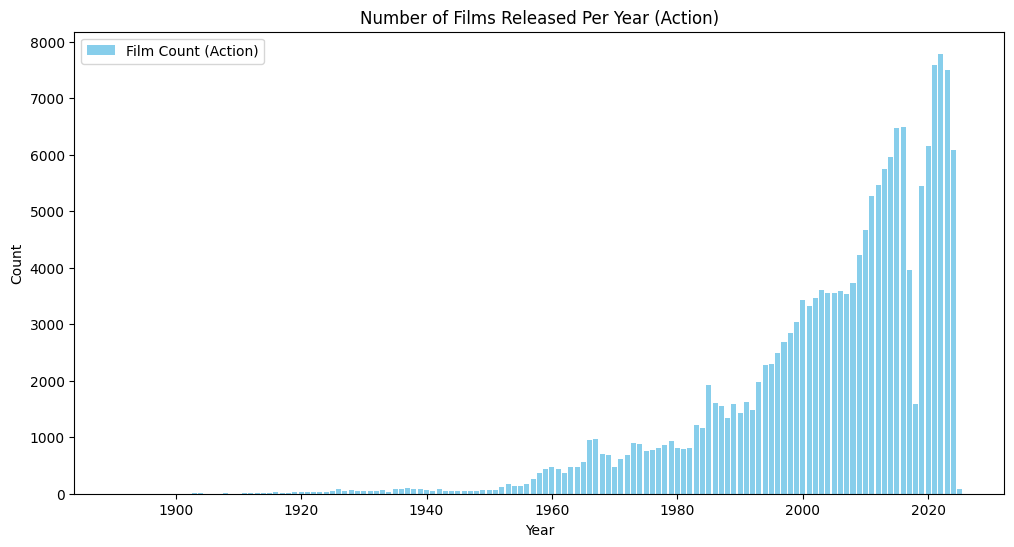

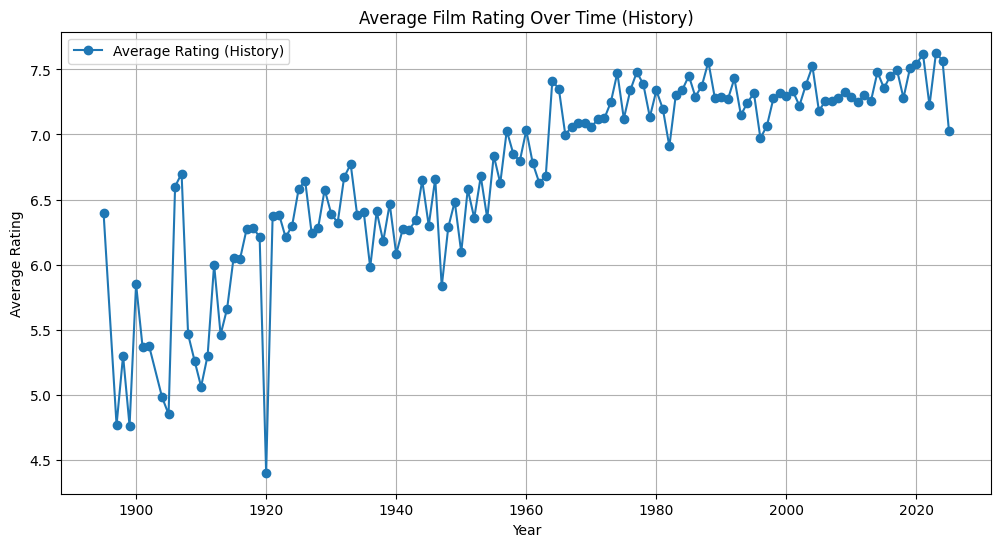

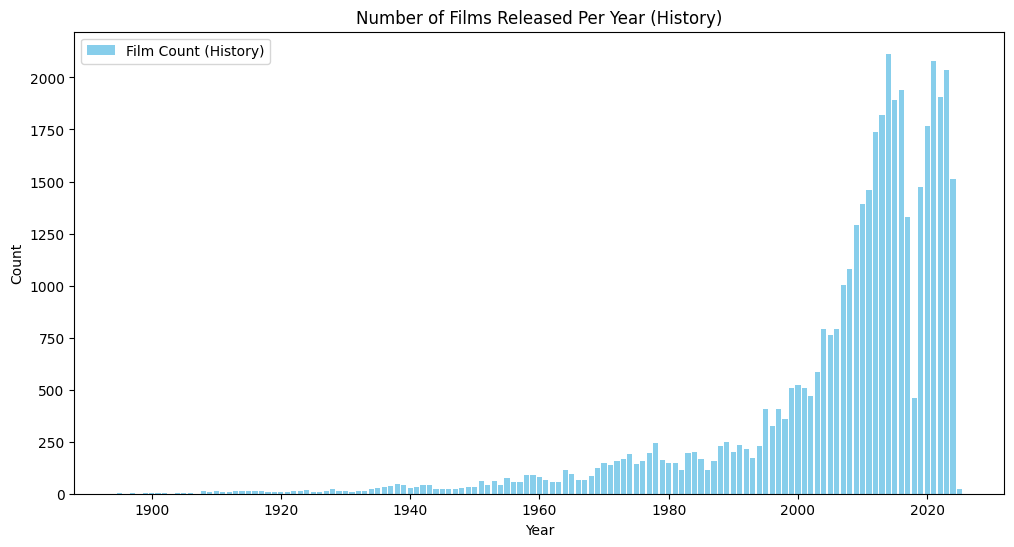

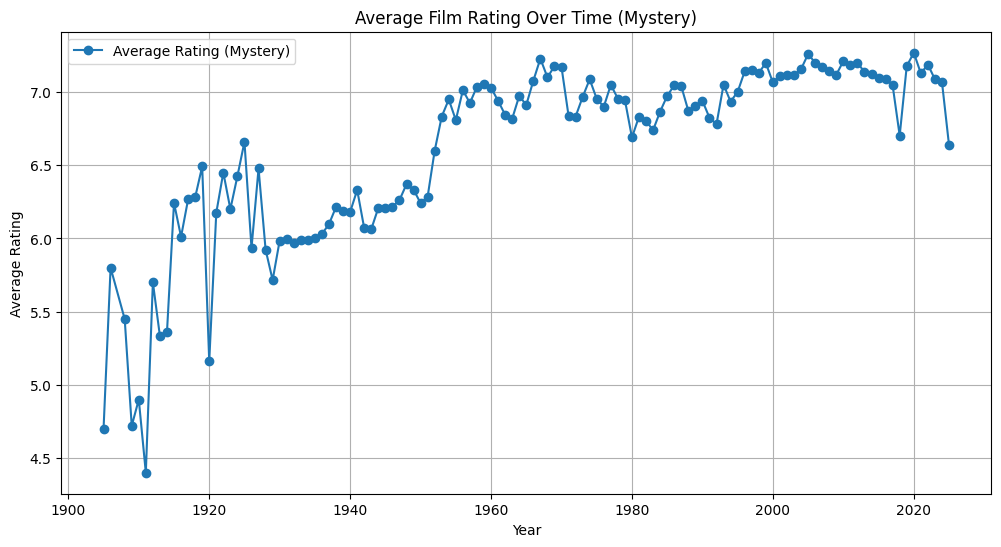

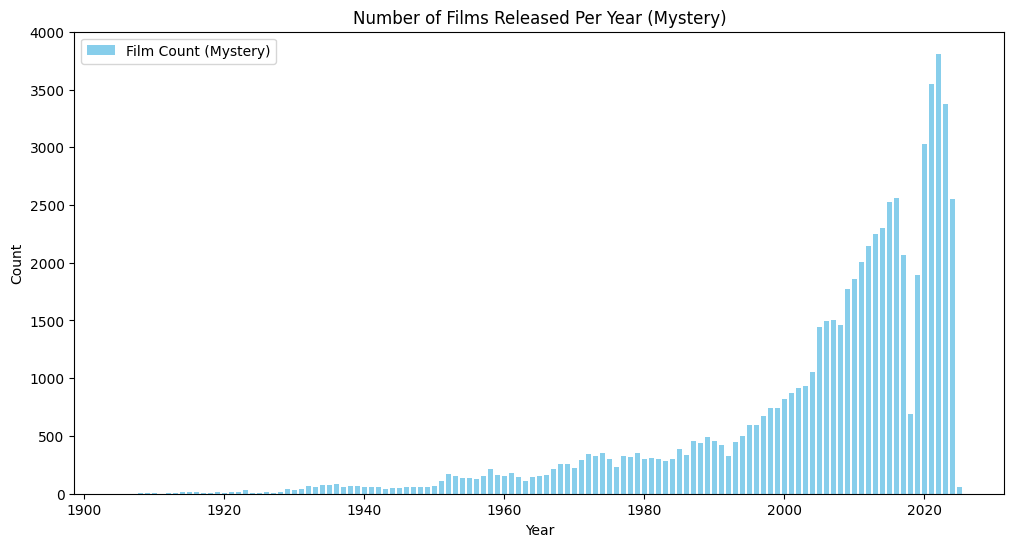

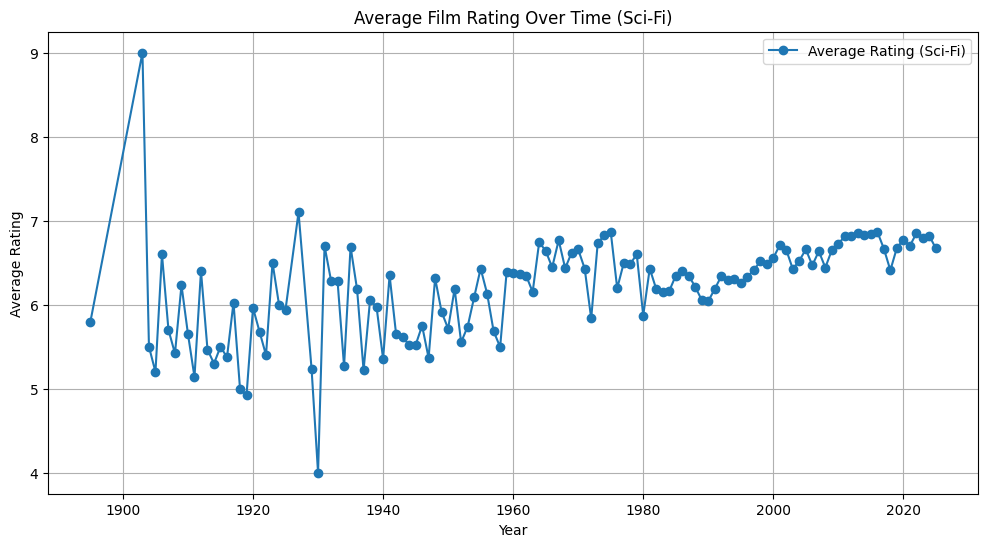

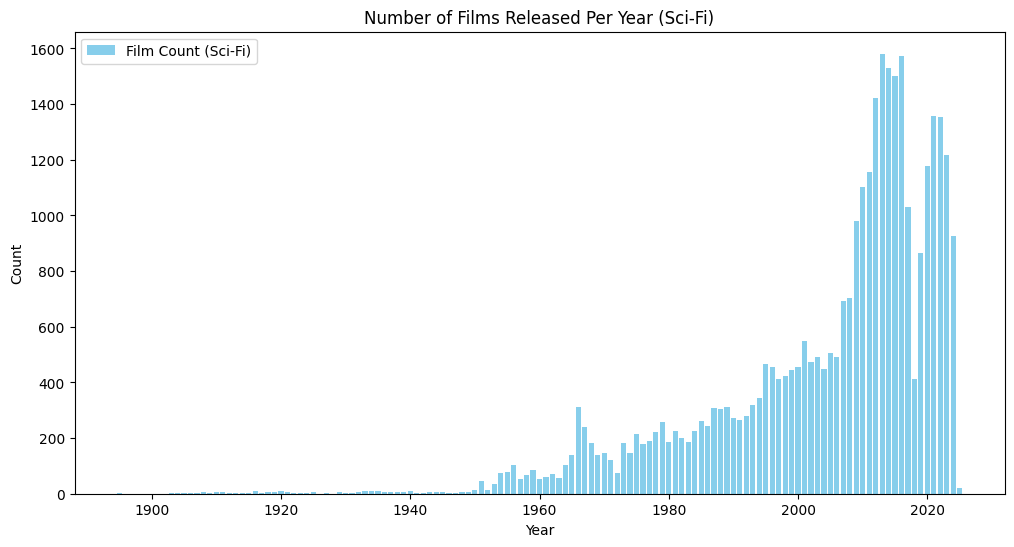

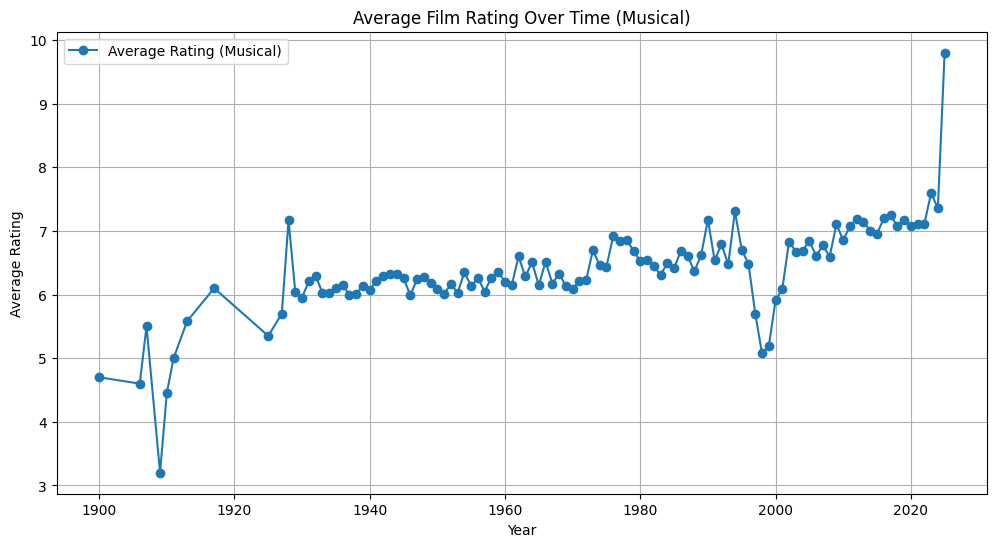

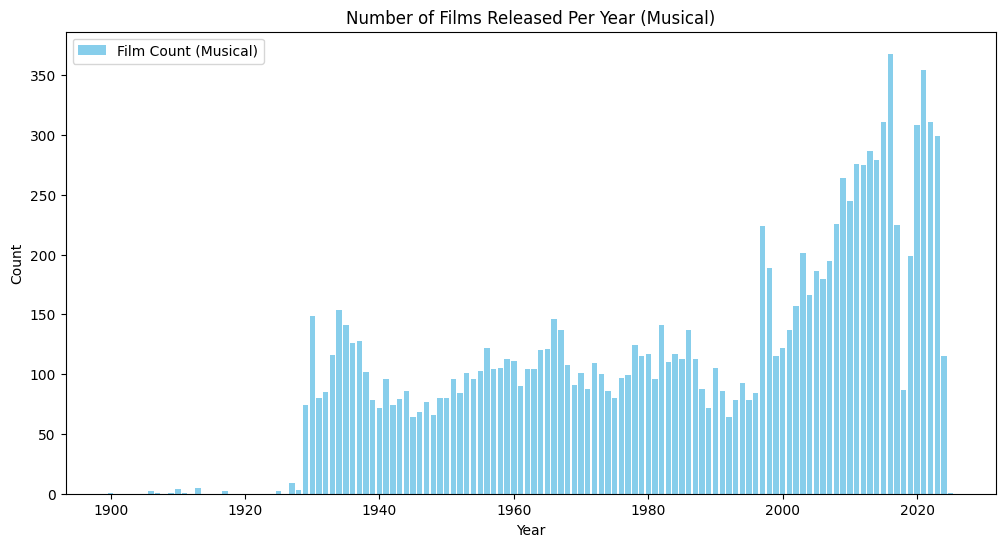

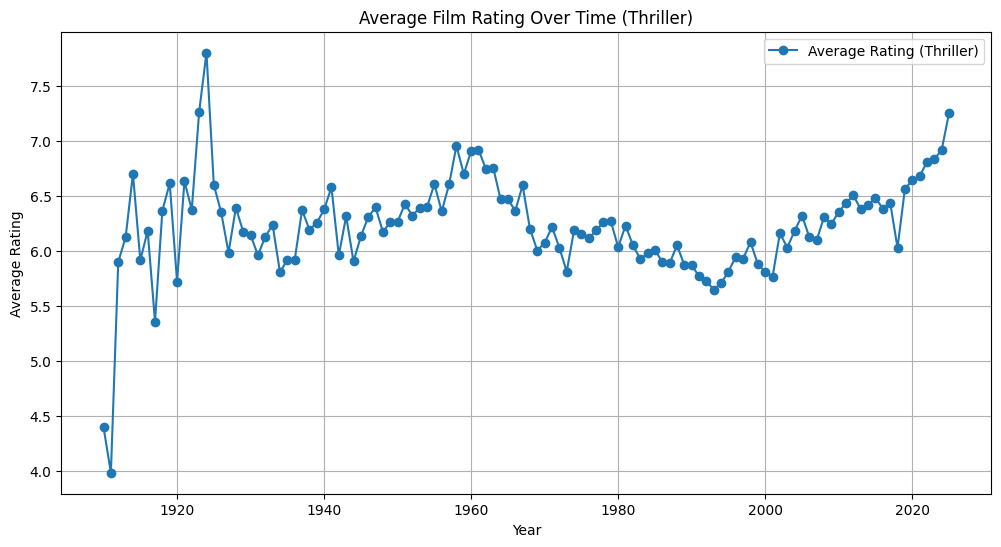

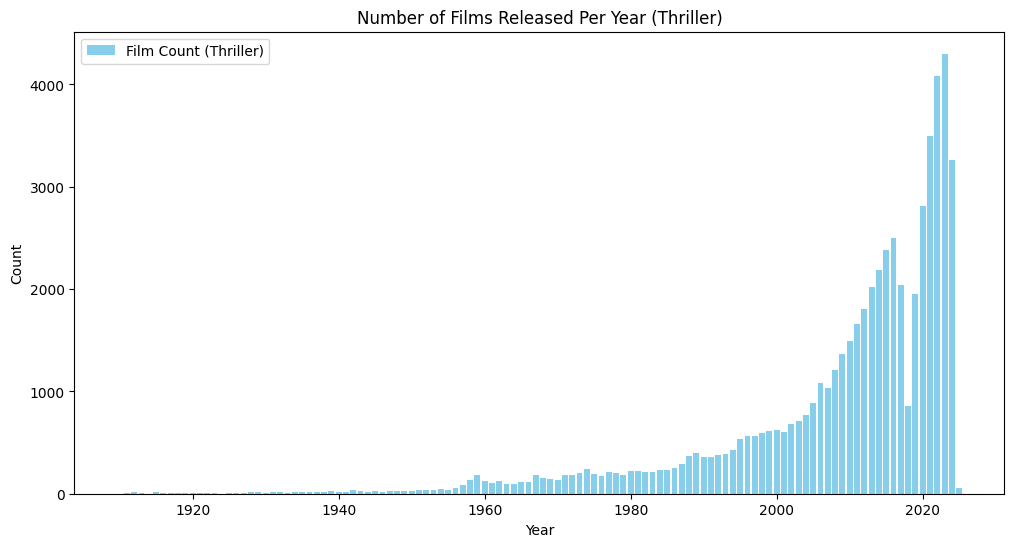

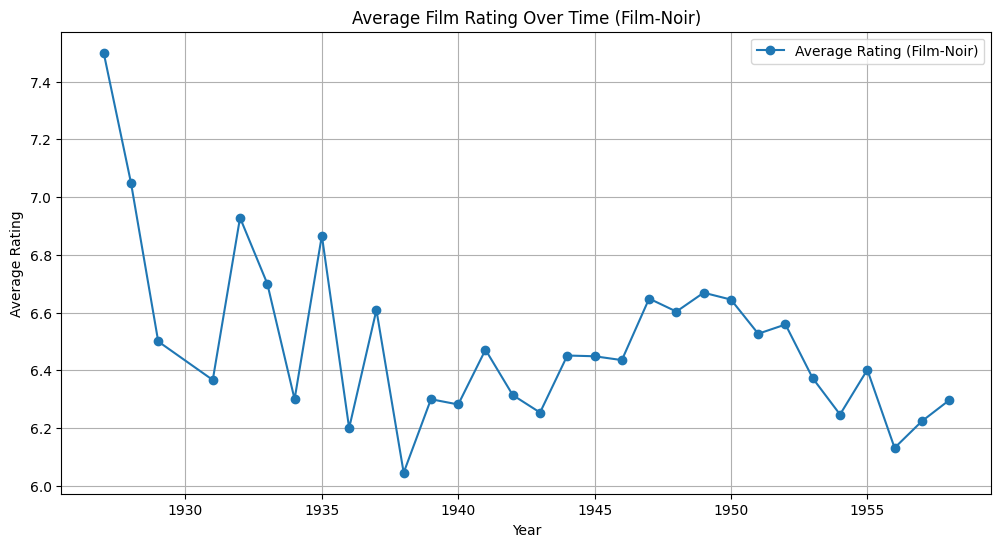

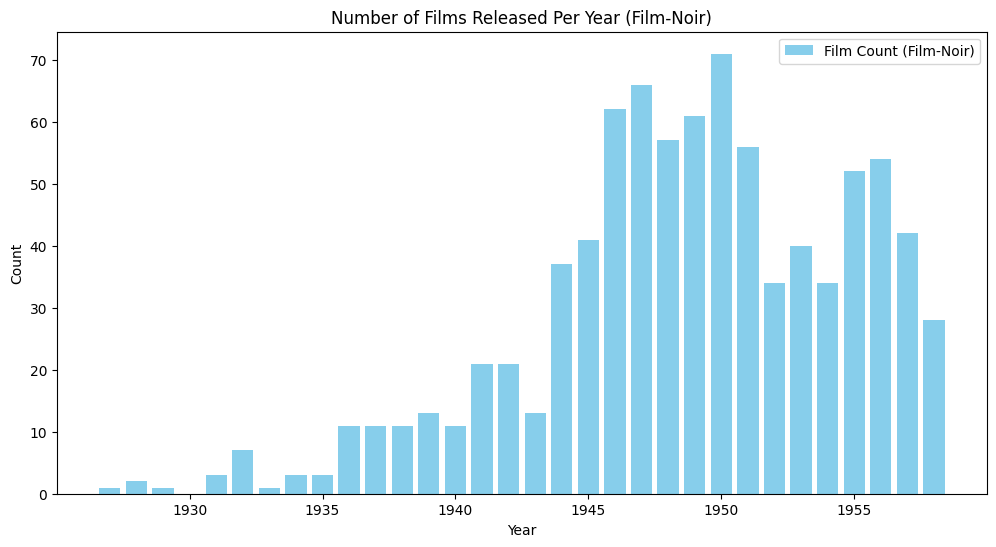

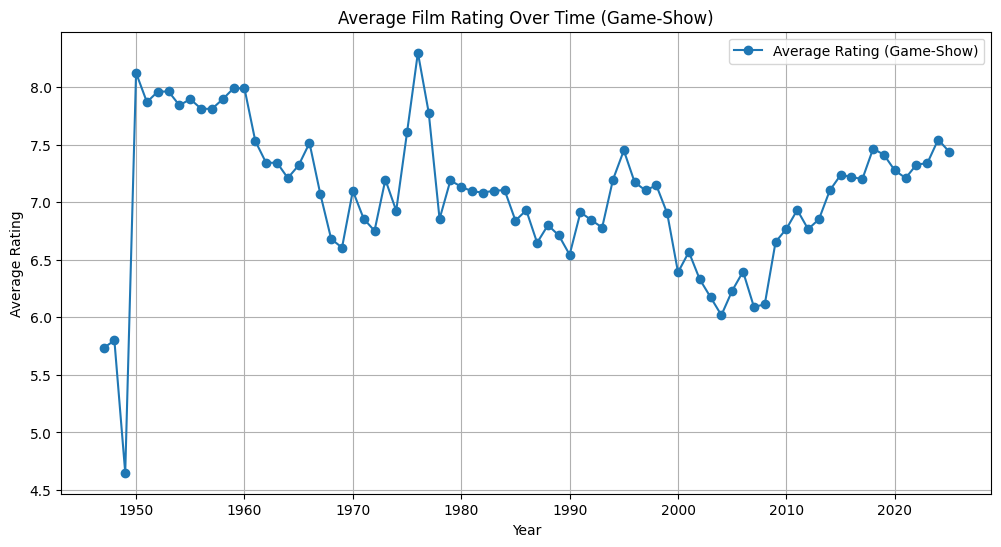

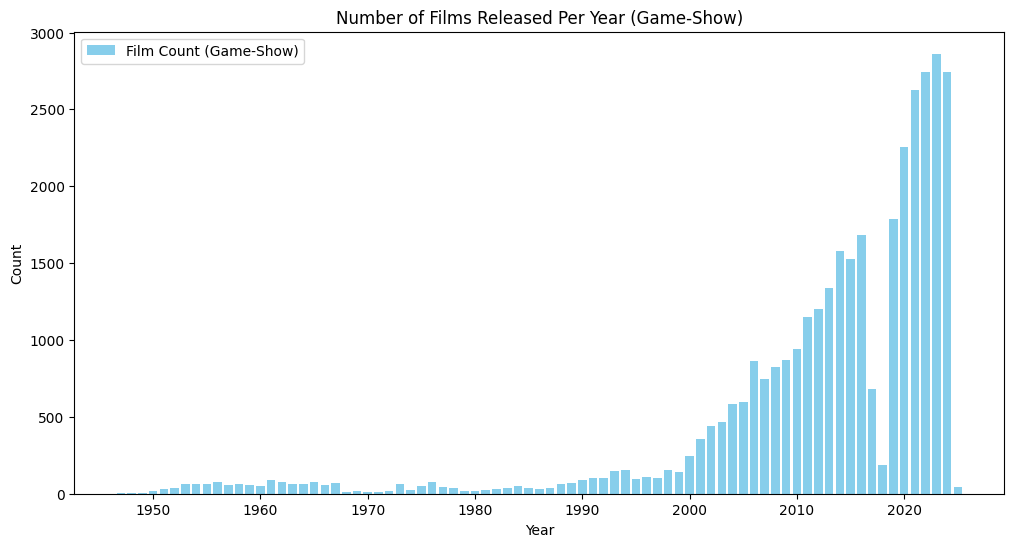

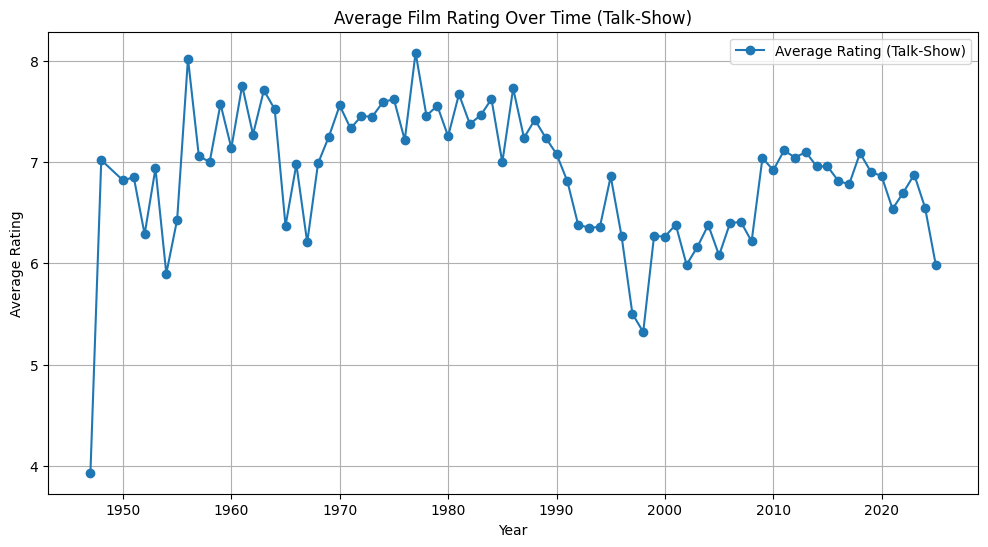

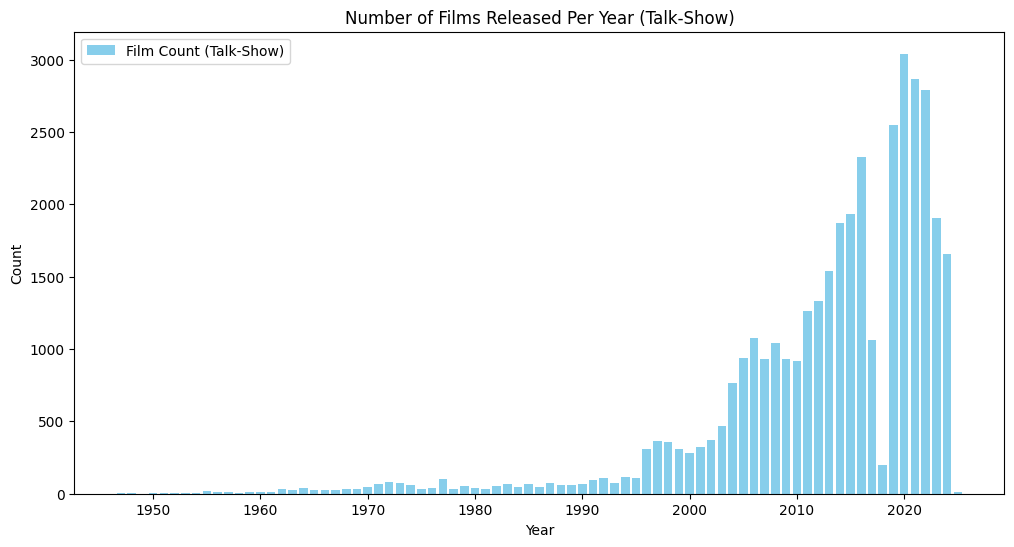

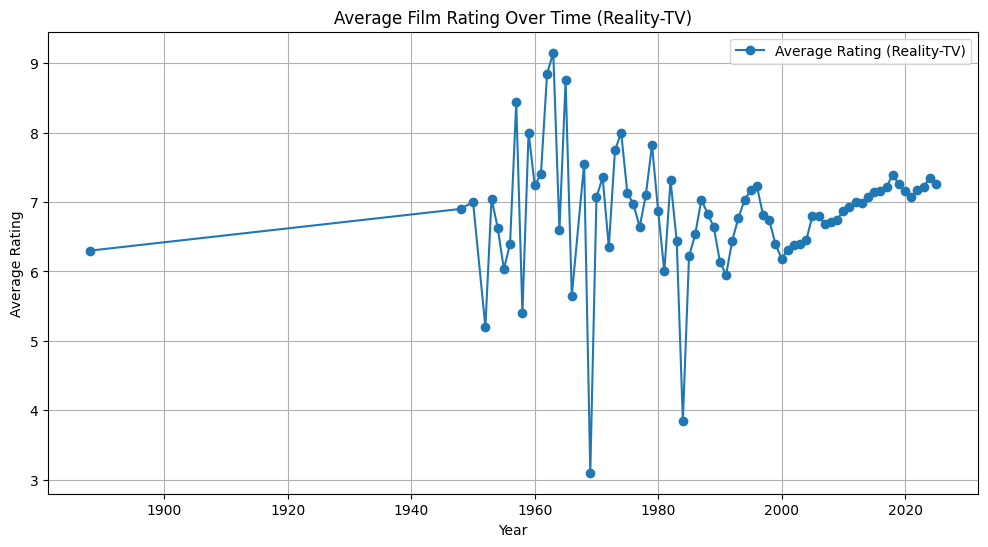

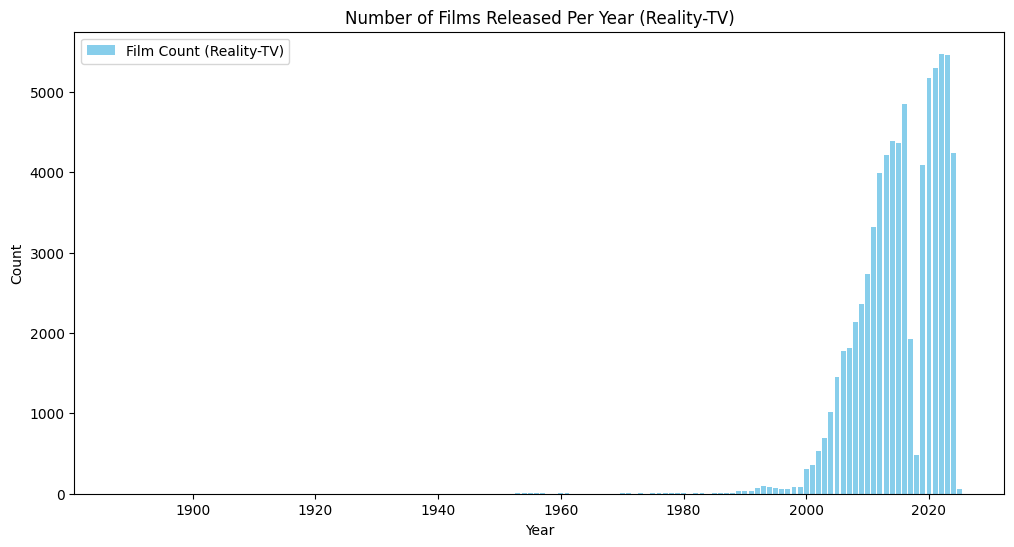

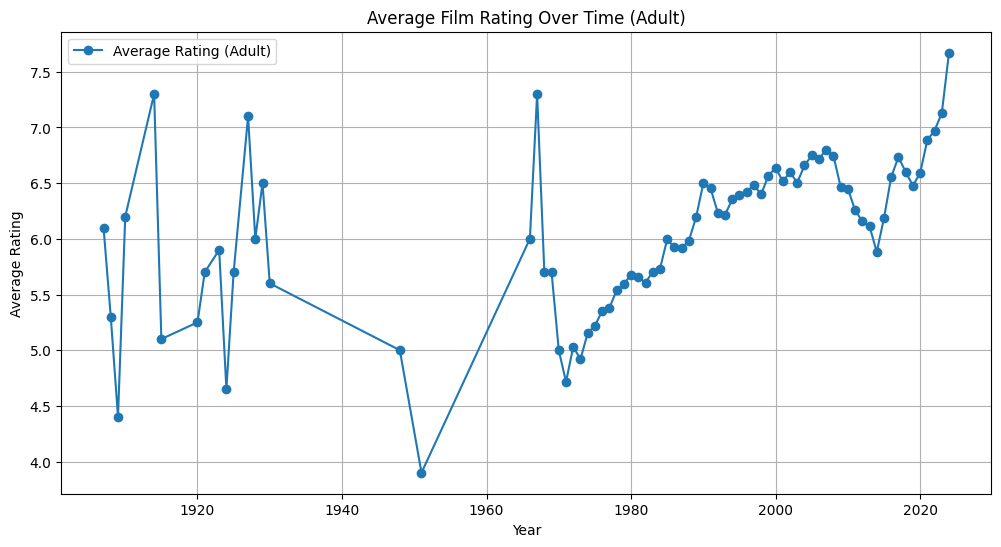

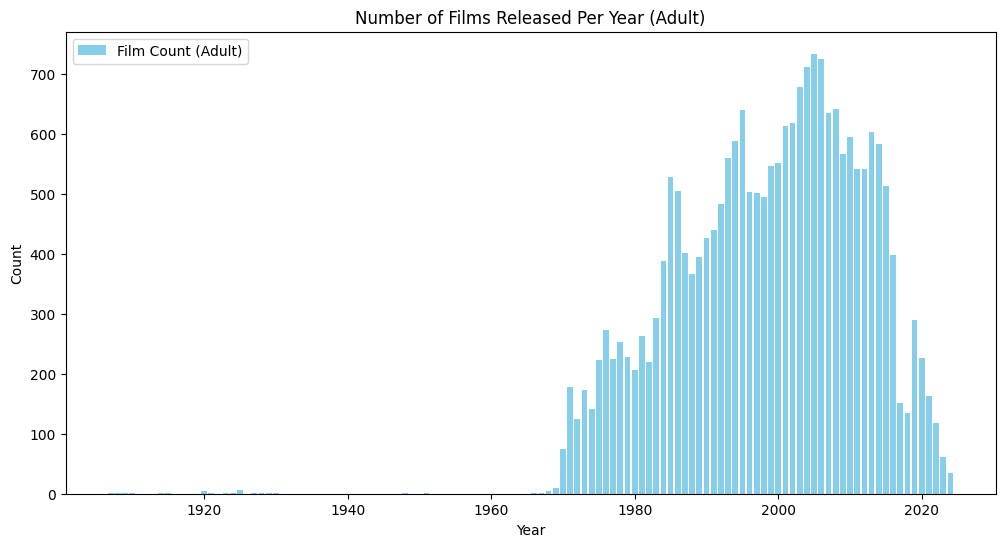

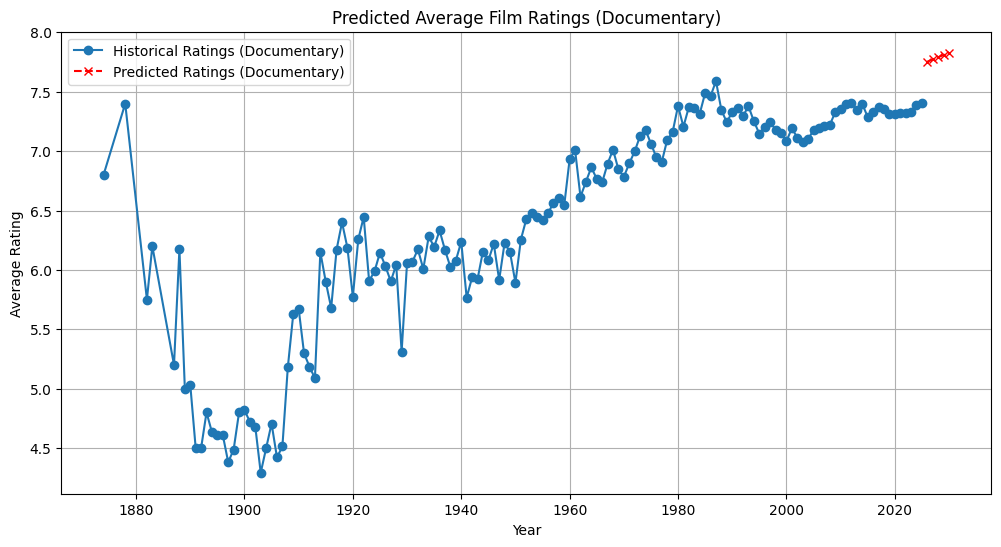

Predicted Ratings for Future Years (Documentary):

Year 2026: 7.75
Year 2027: 7.77
Year 2028: 7.79
Year 2029: 7.81
Year 2030: 7.83


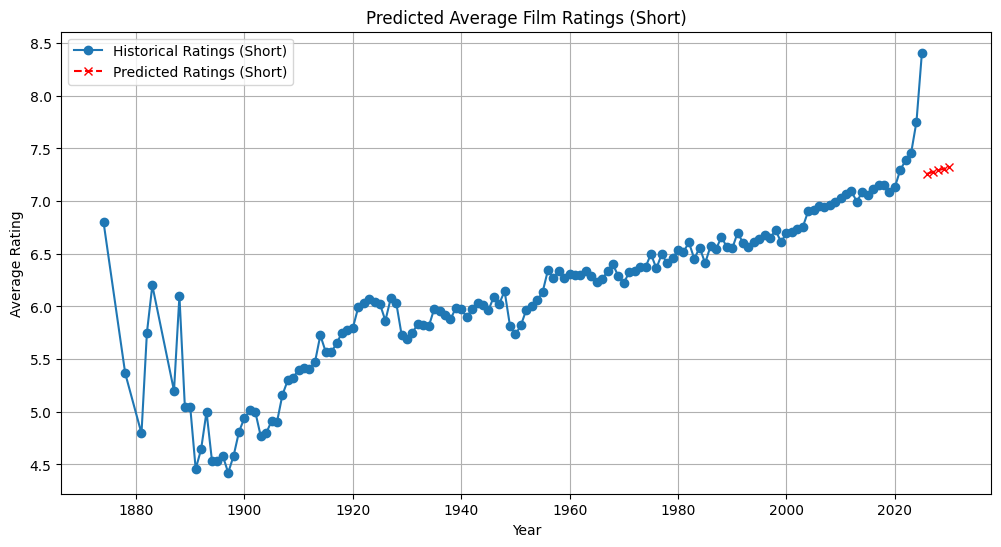

Predicted Ratings for Future Years (Short):

Year 2026: 7.26
Year 2027: 7.28
Year 2028: 7.29
Year 2029: 7.31
Year 2030: 7.32


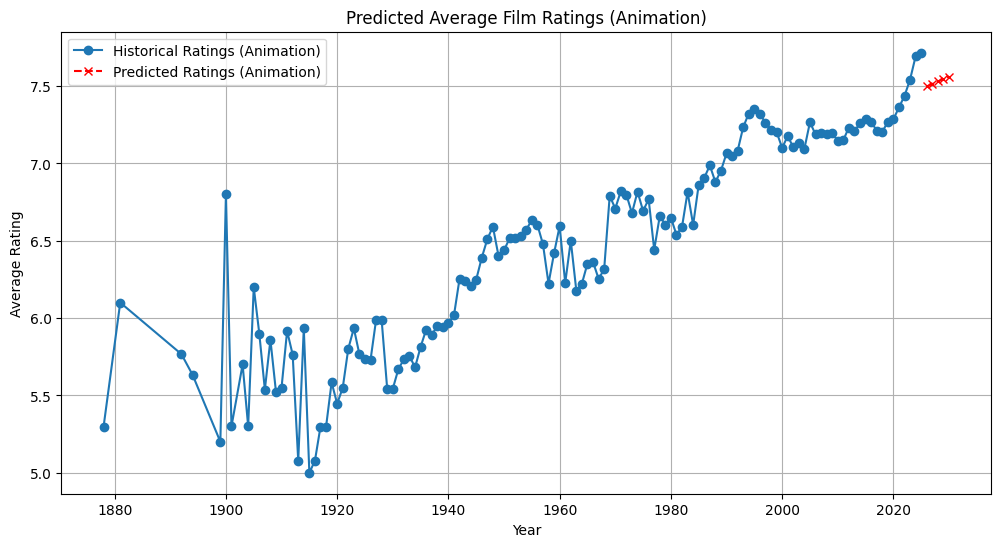

Predicted Ratings for Future Years (Animation):

Year 2026: 7.50
Year 2027: 7.51
Year 2028: 7.53
Year 2029: 7.55
Year 2030: 7.56


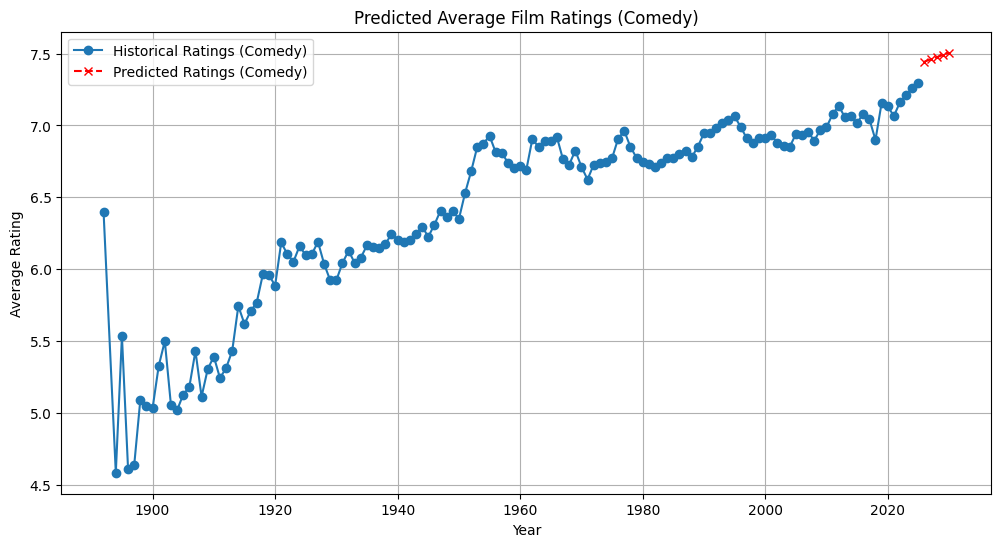

Predicted Ratings for Future Years (Comedy):

Year 2026: 7.44
Year 2027: 7.46
Year 2028: 7.48
Year 2029: 7.49
Year 2030: 7.51


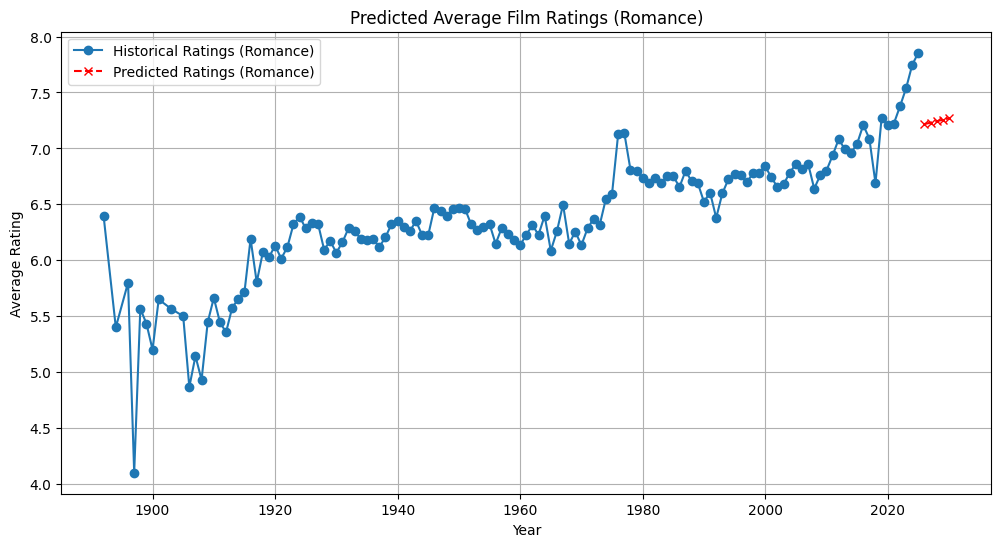

Predicted Ratings for Future Years (Romance):

Year 2026: 7.22
Year 2027: 7.23
Year 2028: 7.24
Year 2029: 7.26
Year 2030: 7.27


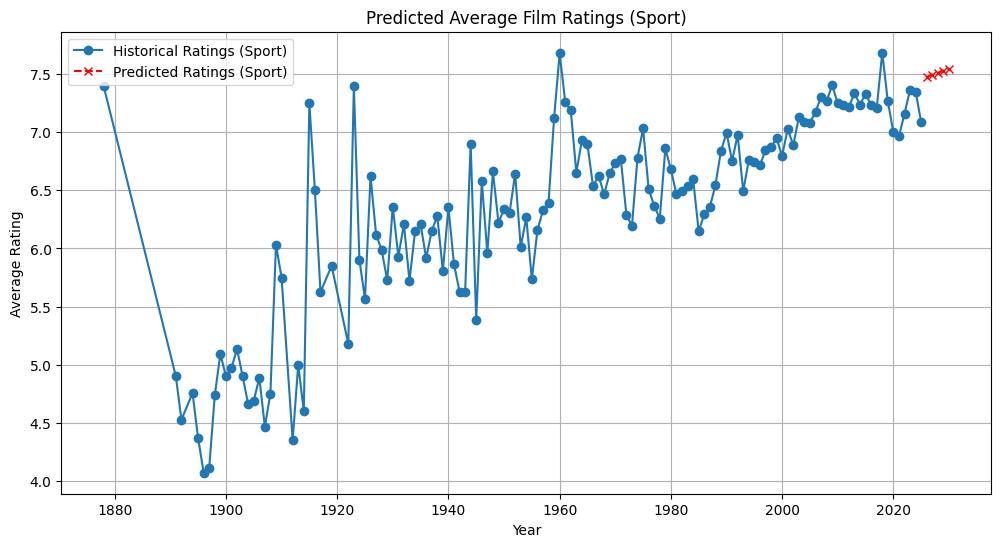

Predicted Ratings for Future Years (Sport):

Year 2026: 7.48
Year 2027: 7.49
Year 2028: 7.51
Year 2029: 7.53
Year 2030: 7.55


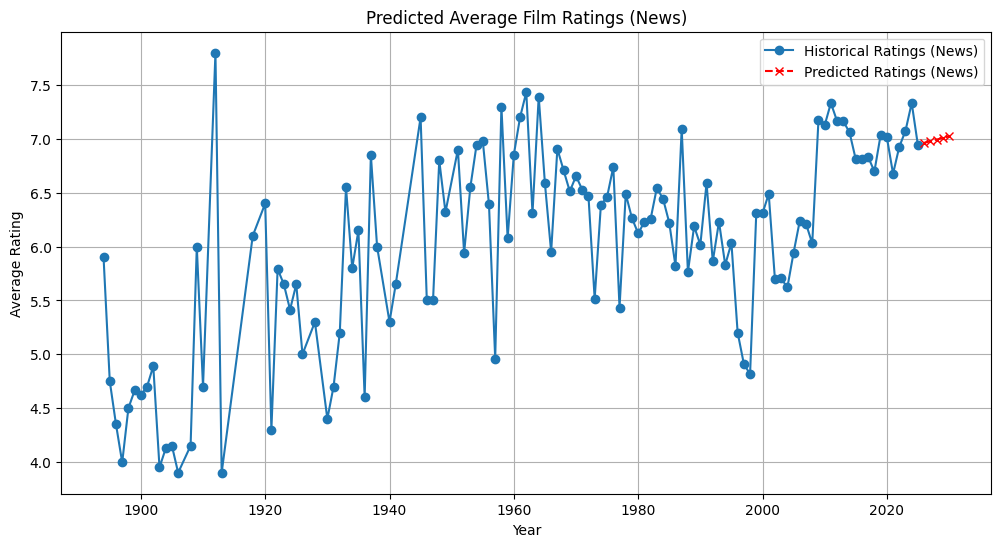

Predicted Ratings for Future Years (News):

Year 2026: 6.96
Year 2027: 6.98
Year 2028: 6.99
Year 2029: 7.01
Year 2030: 7.02


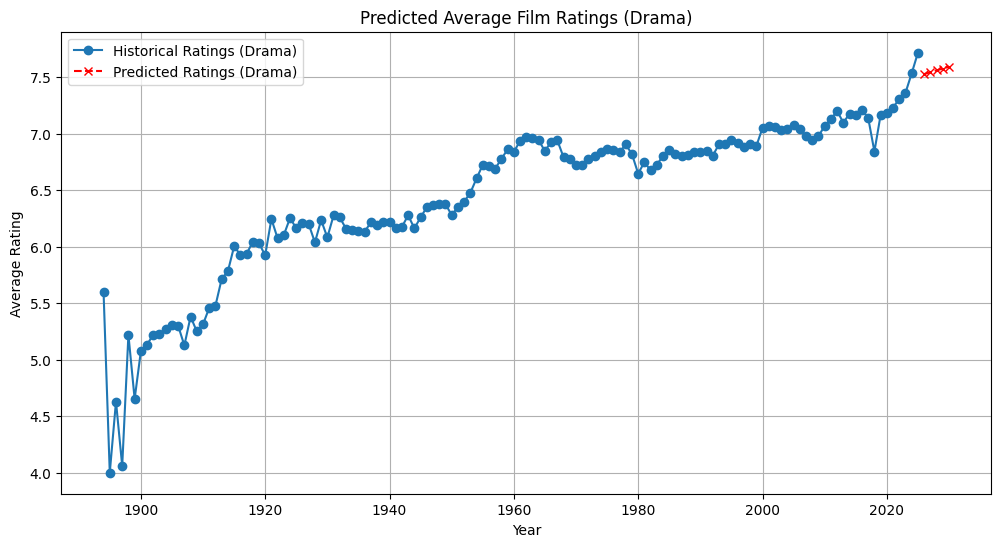

Predicted Ratings for Future Years (Drama):

Year 2026: 7.53
Year 2027: 7.54
Year 2028: 7.56
Year 2029: 7.58
Year 2030: 7.59


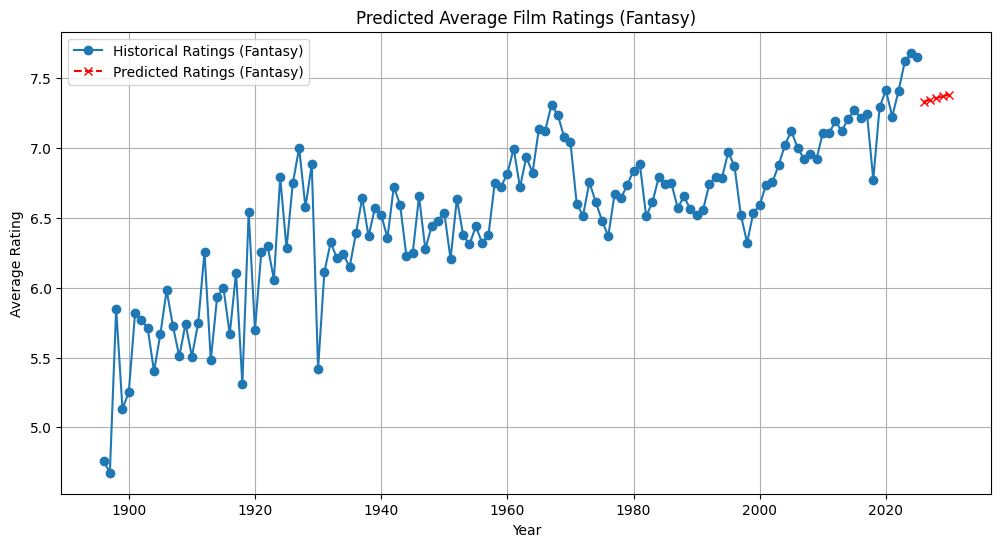

Predicted Ratings for Future Years (Fantasy):

Year 2026: 7.33
Year 2027: 7.35
Year 2028: 7.36
Year 2029: 7.37
Year 2030: 7.38


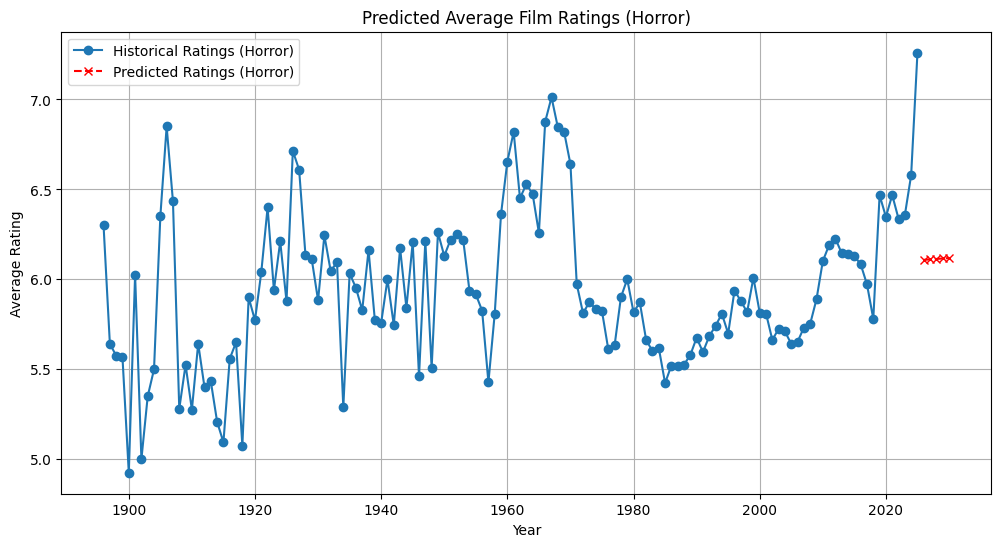

Predicted Ratings for Future Years (Horror):

Year 2026: 6.11
Year 2027: 6.11
Year 2028: 6.11
Year 2029: 6.12
Year 2030: 6.12


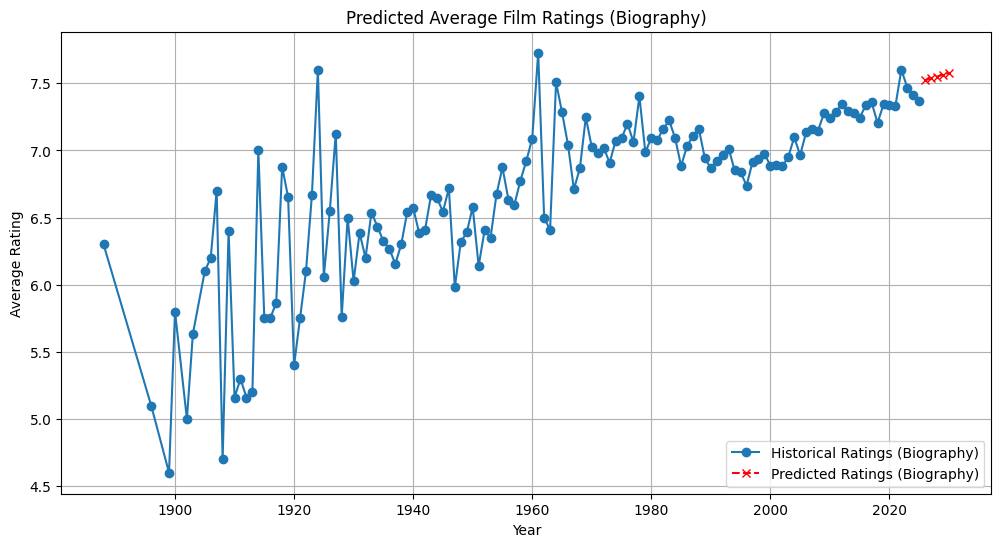

Predicted Ratings for Future Years (Biography):

Year 2026: 7.52
Year 2027: 7.54
Year 2028: 7.55
Year 2029: 7.56
Year 2030: 7.58


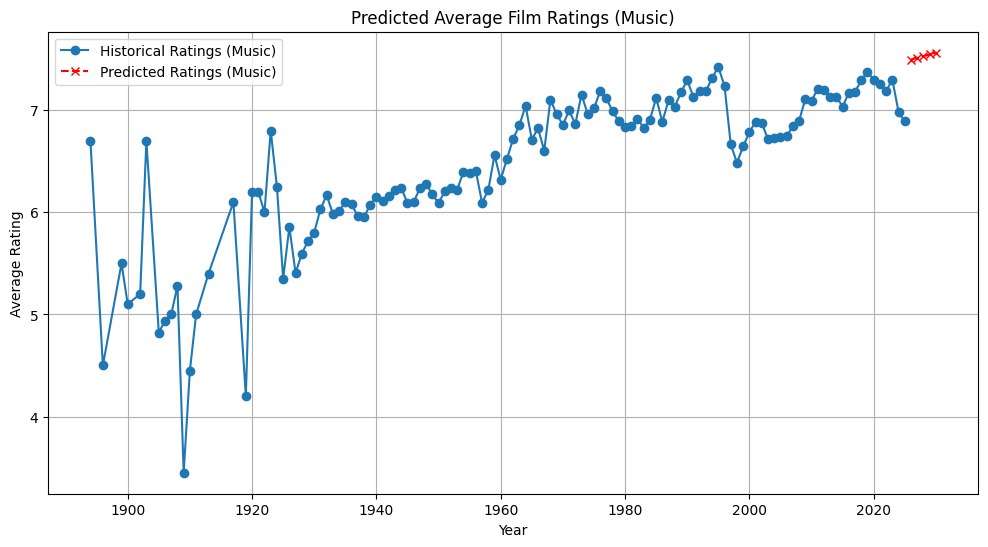

Predicted Ratings for Future Years (Music):

Year 2026: 7.50
Year 2027: 7.51
Year 2028: 7.53
Year 2029: 7.55
Year 2030: 7.56


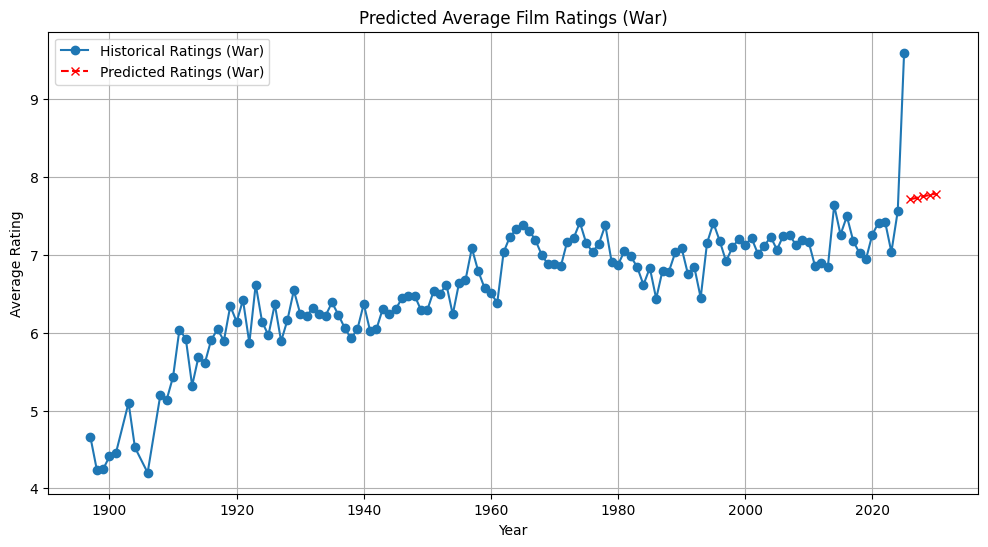

Predicted Ratings for Future Years (War):

Year 2026: 7.72
Year 2027: 7.73
Year 2028: 7.75
Year 2029: 7.77
Year 2030: 7.79


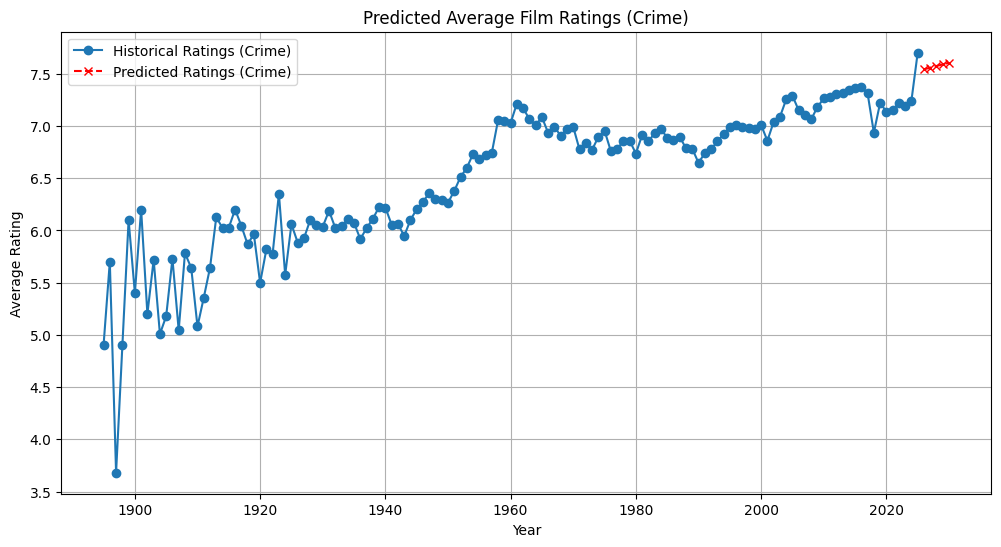

Predicted Ratings for Future Years (Crime):

Year 2026: 7.54
Year 2027: 7.56
Year 2028: 7.57
Year 2029: 7.59
Year 2030: 7.61


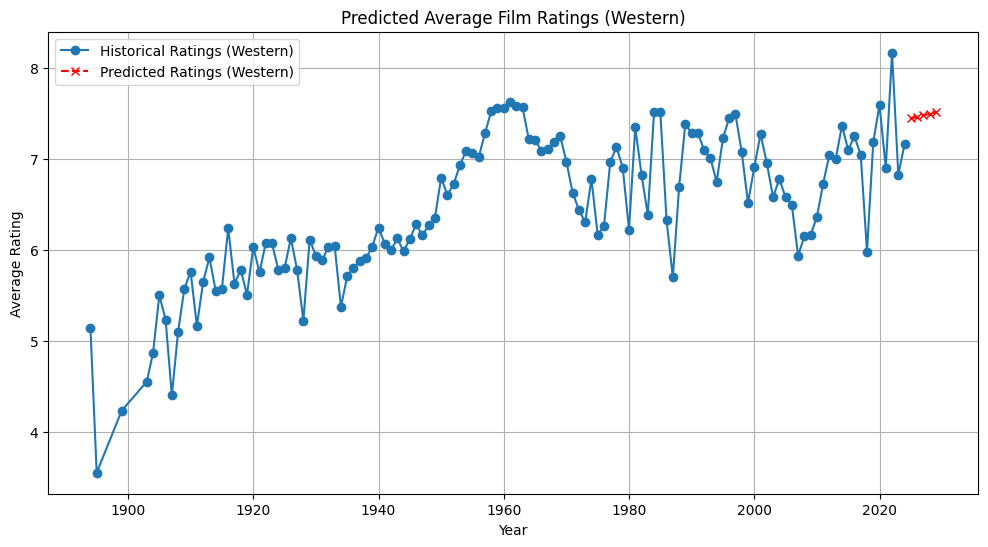

Predicted Ratings for Future Years (Western):

Year 2025: 7.44
Year 2026: 7.46
Year 2027: 7.48
Year 2028: 7.49
Year 2029: 7.51


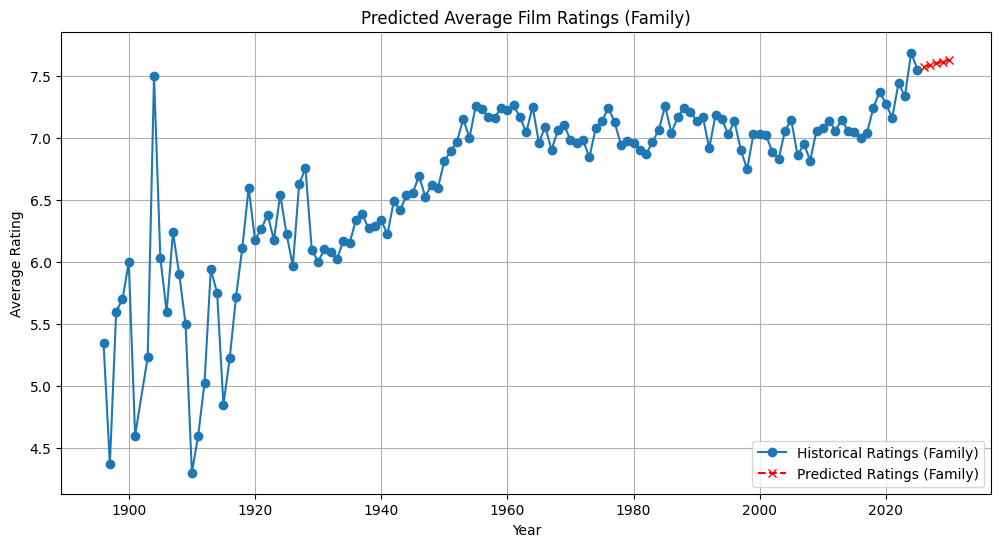

Predicted Ratings for Future Years (Family):

Year 2026: 7.57
Year 2027: 7.59
Year 2028: 7.60
Year 2029: 7.62
Year 2030: 7.63


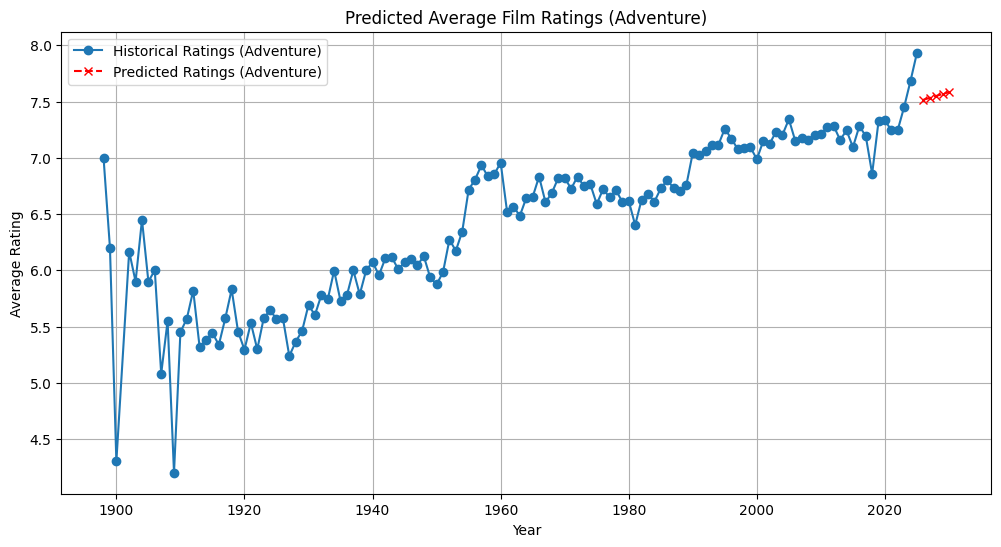

Predicted Ratings for Future Years (Adventure):

Year 2026: 7.52
Year 2027: 7.53
Year 2028: 7.55
Year 2029: 7.57
Year 2030: 7.58


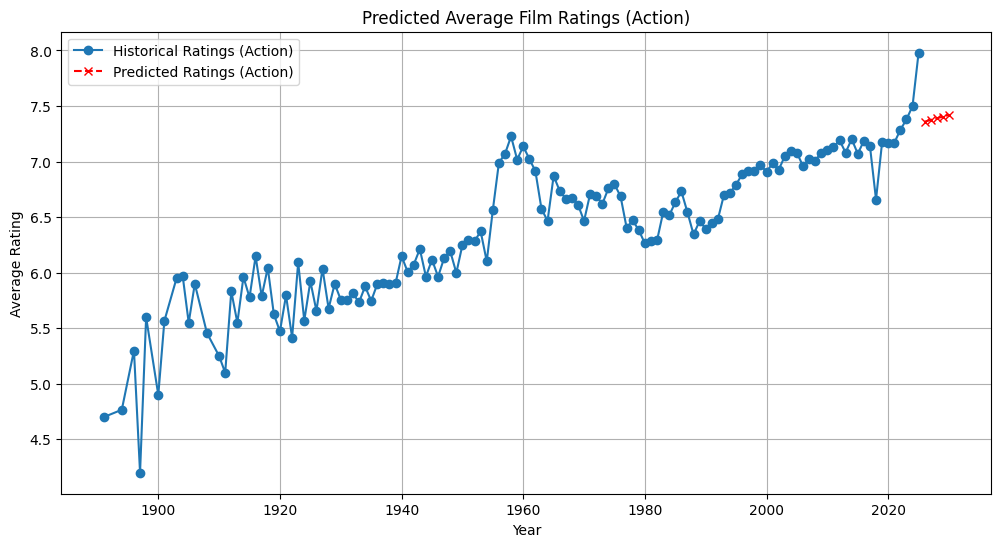

Predicted Ratings for Future Years (Action):

Year 2026: 7.36
Year 2027: 7.37
Year 2028: 7.39
Year 2029: 7.41
Year 2030: 7.42


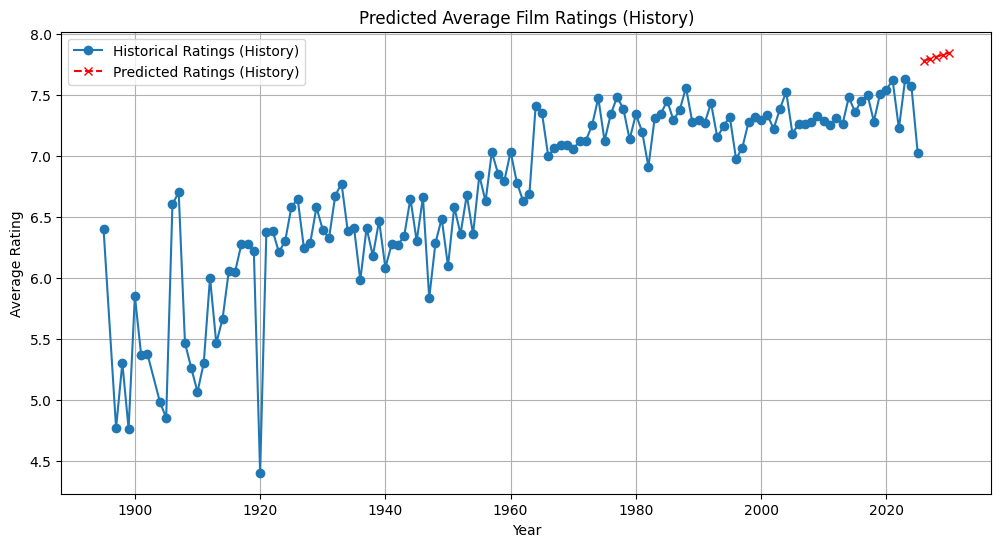

Predicted Ratings for Future Years (History):

Year 2026: 7.78
Year 2027: 7.79
Year 2028: 7.81
Year 2029: 7.83
Year 2030: 7.84


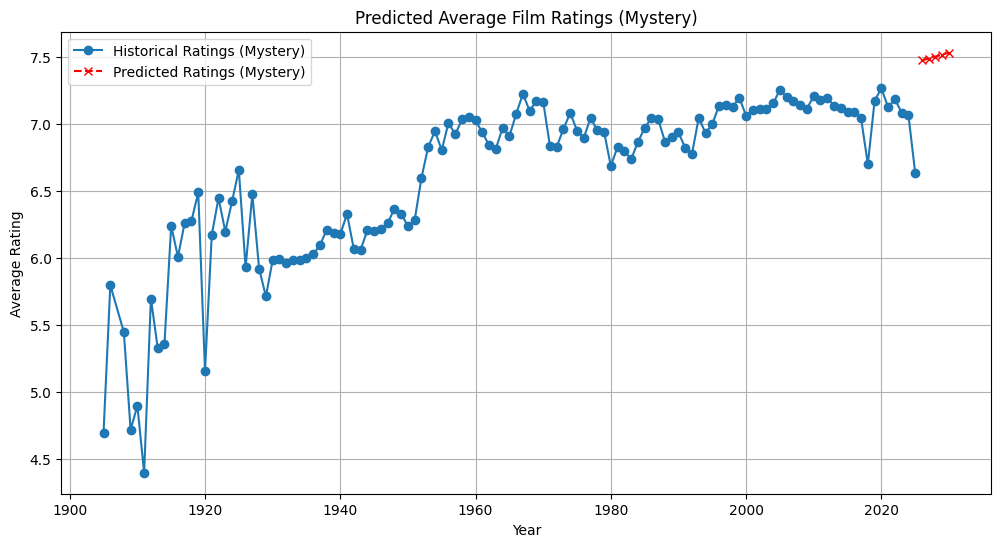

Predicted Ratings for Future Years (Mystery):

Year 2026: 7.48
Year 2027: 7.49
Year 2028: 7.51
Year 2029: 7.52
Year 2030: 7.53


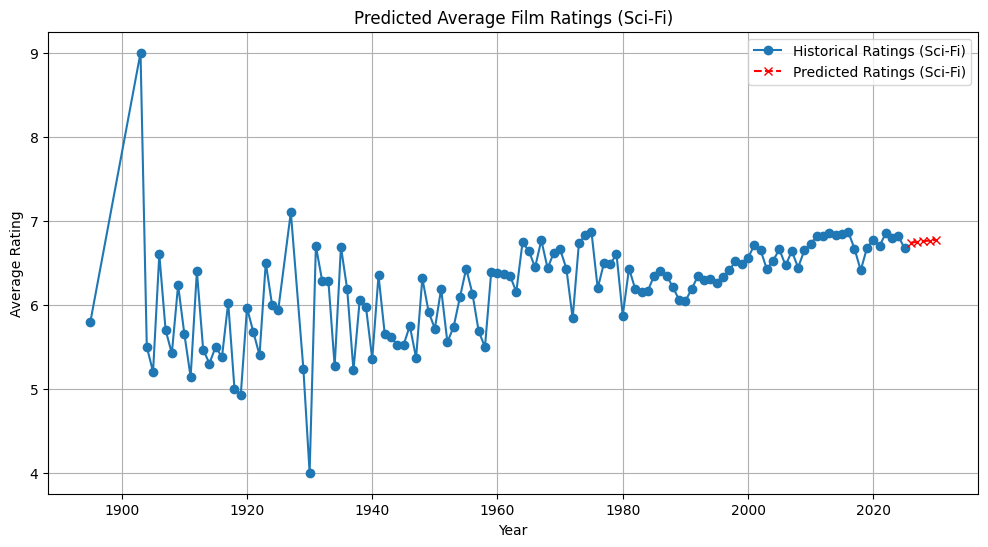

Predicted Ratings for Future Years (Sci-Fi):

Year 2026: 6.74
Year 2027: 6.75
Year 2028: 6.76
Year 2029: 6.76
Year 2030: 6.77


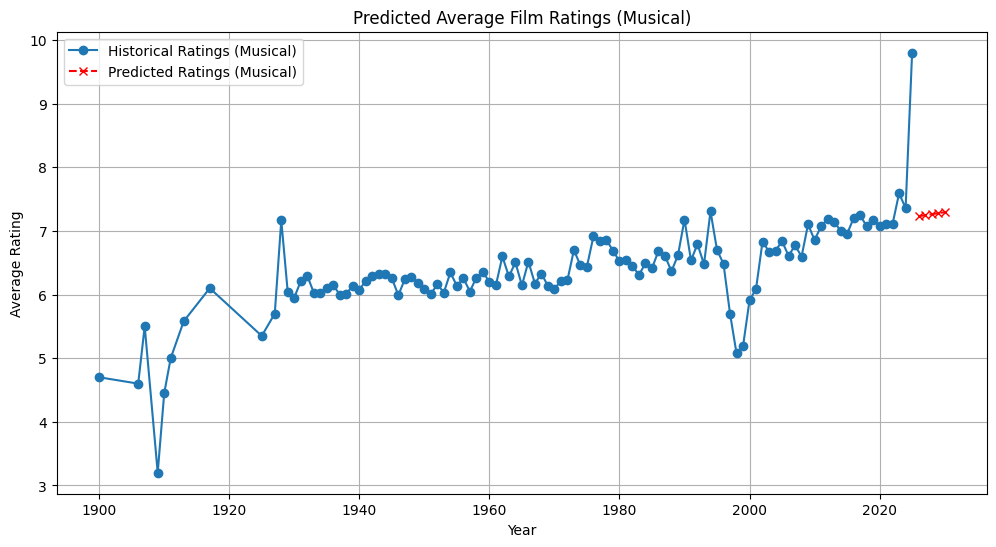

Predicted Ratings for Future Years (Musical):

Year 2026: 7.23
Year 2027: 7.25
Year 2028: 7.26
Year 2029: 7.28
Year 2030: 7.29


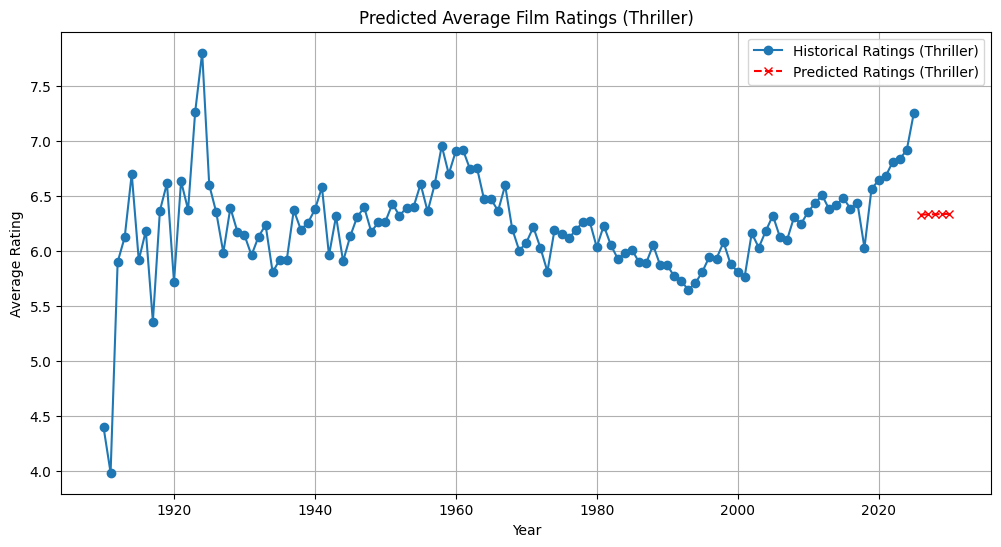

Predicted Ratings for Future Years (Thriller):

Year 2026: 6.33
Year 2027: 6.33
Year 2028: 6.33
Year 2029: 6.34
Year 2030: 6.34


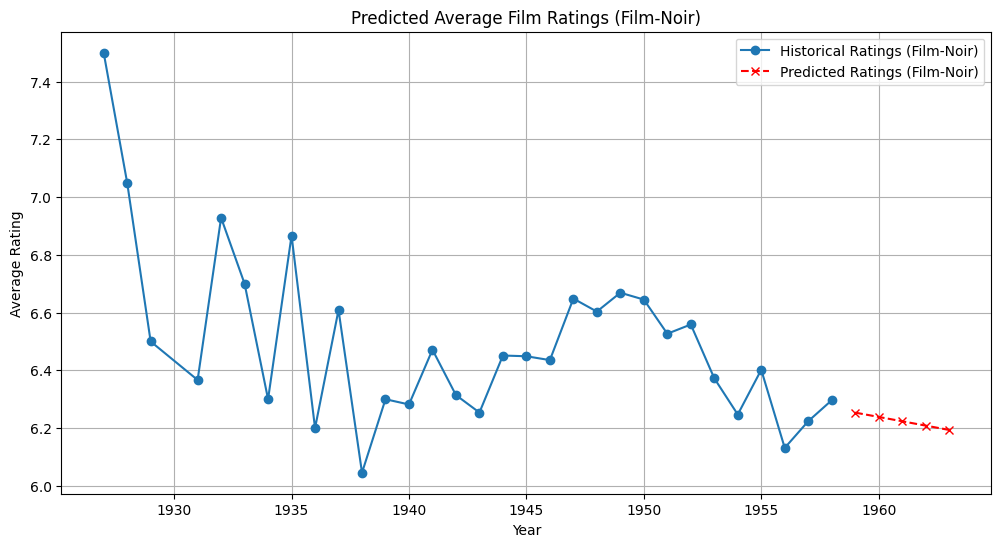

Predicted Ratings for Future Years (Film-Noir):

Year 1959: 6.25
Year 1960: 6.24
Year 1961: 6.22
Year 1962: 6.21
Year 1963: 6.19


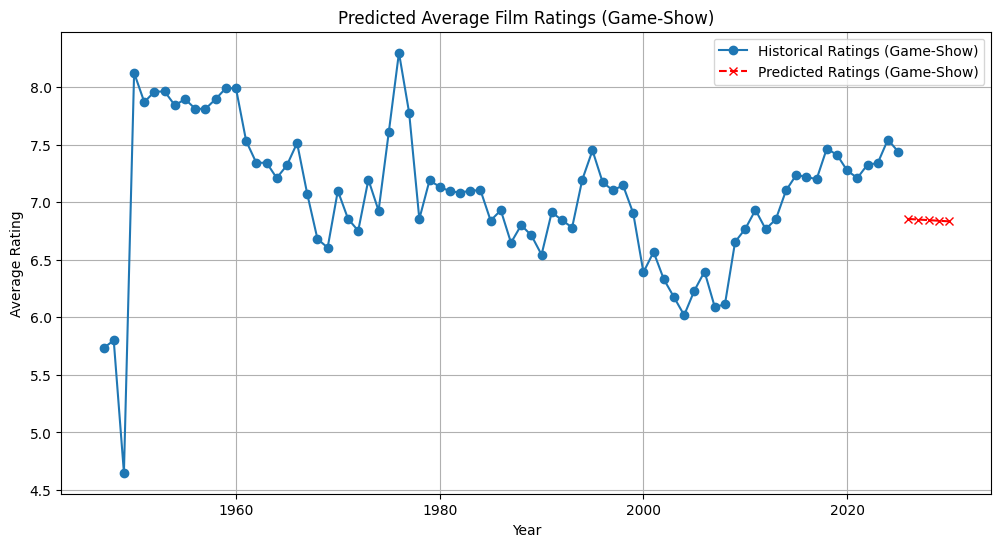

Predicted Ratings for Future Years (Game-Show):

Year 2026: 6.86
Year 2027: 6.85
Year 2028: 6.85
Year 2029: 6.84
Year 2030: 6.83


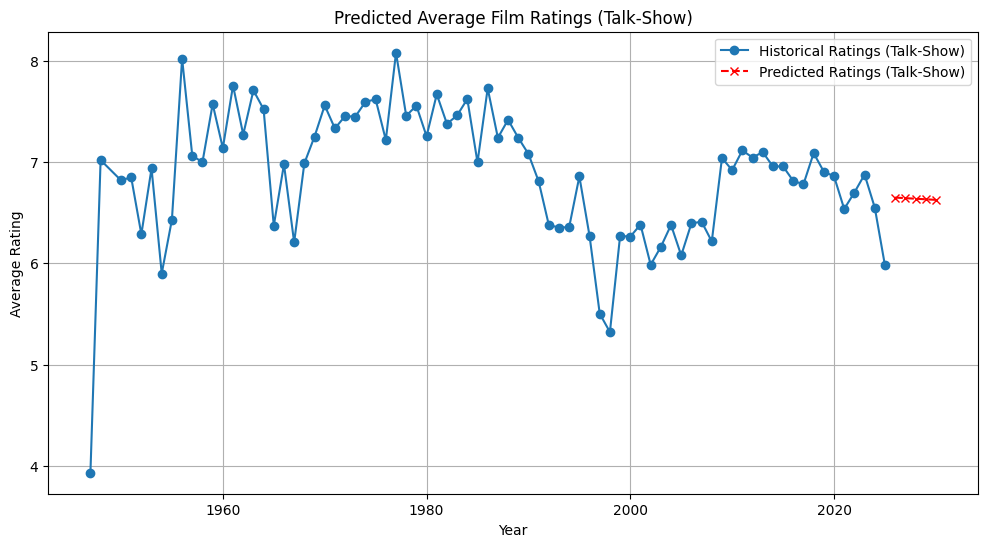

Predicted Ratings for Future Years (Talk-Show):

Year 2026: 6.65
Year 2027: 6.64
Year 2028: 6.64
Year 2029: 6.63
Year 2030: 6.63


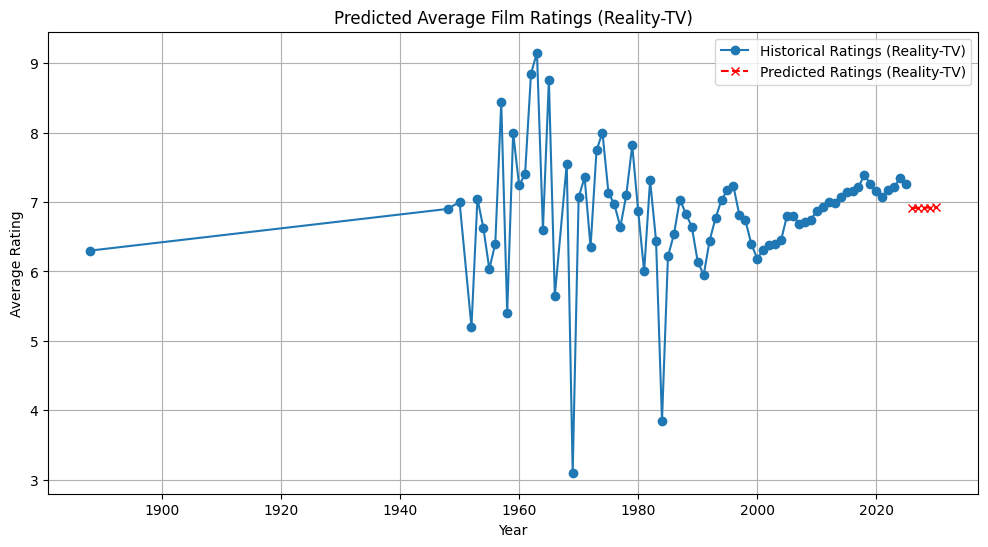

Predicted Ratings for Future Years (Reality-TV):

Year 2026: 6.91
Year 2027: 6.92
Year 2028: 6.92
Year 2029: 6.92
Year 2030: 6.92


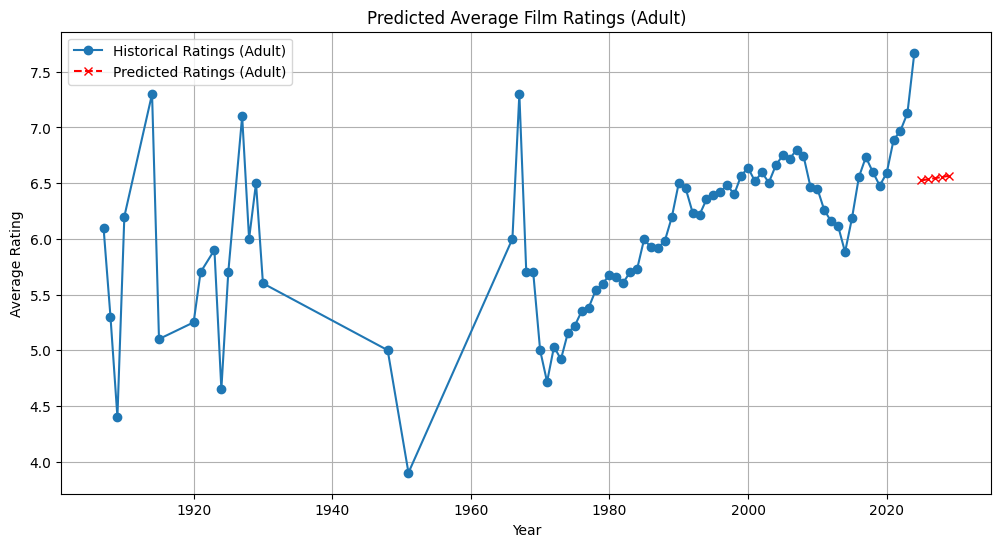

Predicted Ratings for Future Years (Adult):

Year 2025: 6.52
Year 2026: 6.53
Year 2027: 6.55
Year 2028: 6.56
Year 2029: 6.57


In [12]:
# 3. Visualization for each genre
def visualize_trends_for_each_genre(df):
    """Visualize trends in the dataset for each genre."""
    genres = df['genres'].str.split(',', expand=True).stack().unique()
    
    for genre in genres:
        genre_df = df[df['genres'].fillna('').str.contains(genre)]
        
        plt.figure(figsize=(12, 6))
        
        # Average Rating Over Time
        avg_rating = genre_df.groupby('startYear')['averageRating'].mean()
        plt.plot(avg_rating.index, avg_rating.values, marker='o', label=f'Average Rating ({genre})')
        plt.title(f'Average Film Rating Over Time ({genre})')
        plt.xlabel('Year')
        plt.ylabel('Average Rating')
        plt.grid(True)
        plt.legend()
        plt.show()
        
        # Count of Films Per Year
        film_count = genre_df.groupby('startYear').size()
        plt.figure(figsize=(12, 6))
        plt.bar(film_count.index, film_count.values, color='skyblue', label=f'Film Count ({genre})')
        plt.title(f'Number of Films Released Per Year ({genre})')
        plt.xlabel('Year')
        plt.ylabel('Count')
        plt.legend()
        plt.show()

# 4. Prediction for each genre (Simple Linear Regression)
def predict_trends_for_each_genre(df):
    """Predict future trends using Linear Regression for each genre."""
    genres = df['genres'].str.split(',', expand=True).stack().unique()
    
    for genre in genres:
        genre_df = df[df['genres'].fillna('').str.contains(genre)]
        data = genre_df.groupby('startYear')['averageRating'].mean().reset_index()
        X = data['startYear'].values.reshape(-1, 1)
        y = data['averageRating'].values

        model = LinearRegression()
        model.fit(X, y)
        
        future_years = np.arange(data['startYear'].max() + 1, data['startYear'].max() + 6).reshape(-1, 1)
        predictions = model.predict(future_years)

        plt.figure(figsize=(12, 6))
        plt.plot(data['startYear'], y, marker='o', label=f'Historical Ratings ({genre})')
        plt.plot(future_years, predictions, marker='x', linestyle='--', label=f'Predicted Ratings ({genre})', color='red')
        plt.title(f'Predicted Average Film Ratings ({genre})')
        plt.xlabel('Year')
        plt.ylabel('Average Rating')
        plt.legend()
        plt.grid(True)
        plt.show()

        print(f"Predicted Ratings for Future Years ({genre}):\n")
        for year, rating in zip(future_years.flatten(), predictions):
            print(f"Year {year}: {rating:.2f}")
    
# Visualize trends for each genre
visualize_trends_for_each_genre(df)
    
# Predict trends for each genre
predict_trends_for_each_genre(df)


Dataset Head:
       tconst titleType            primaryTitle           originalTitle  \
0  tt0000001     short              Carmencita              Carmencita   
1  tt0000001     short              Carmencita              Carmencita   
2  tt0000001     short              Carmencita              Carmencita   
3  tt0000001     short              Carmencita              Carmencita   
4  tt0000002     short  Le clown et ses chiens  Le clown et ses chiens   

   isAdult  startYear  endYear  runtimeMinutes             genres  \
0        0     1894.0      NaN             1.0  Documentary,Short   
1        0     1894.0      NaN             1.0  Documentary,Short   
2        0     1894.0      NaN             1.0  Documentary,Short   
3        0     1894.0      NaN             1.0  Documentary,Short   
4        0     1892.0      NaN             5.0    Animation,Short   

   averageRating  numVotes  directors writers  ordering     nconst  \
0            5.7      2116  nm0005690     NaN         

/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['startYear'] = df['startYear'].astype(int)                   # Convert Year to integer
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['averageRating'] = df['averageRating'].astype(float)         # Ensure Rating is float


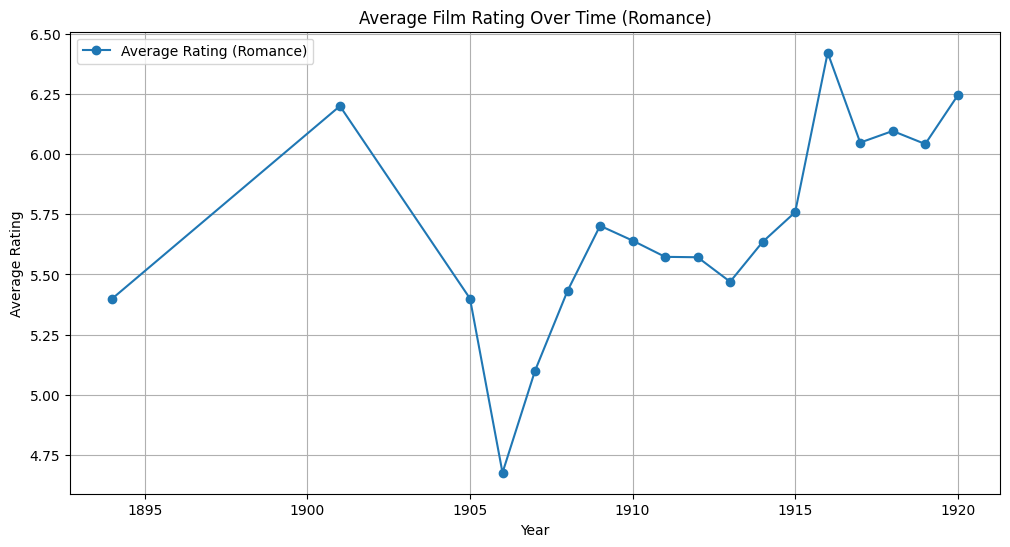

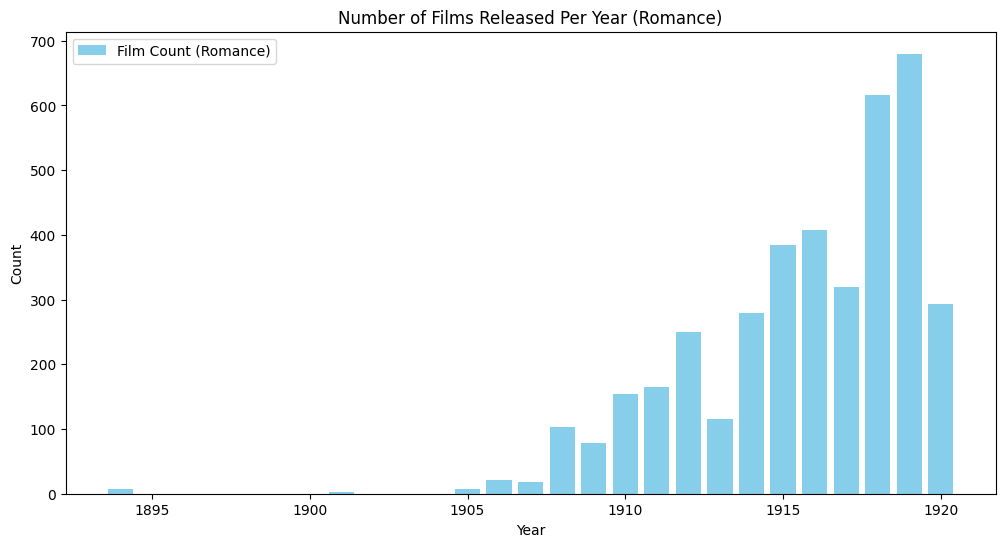

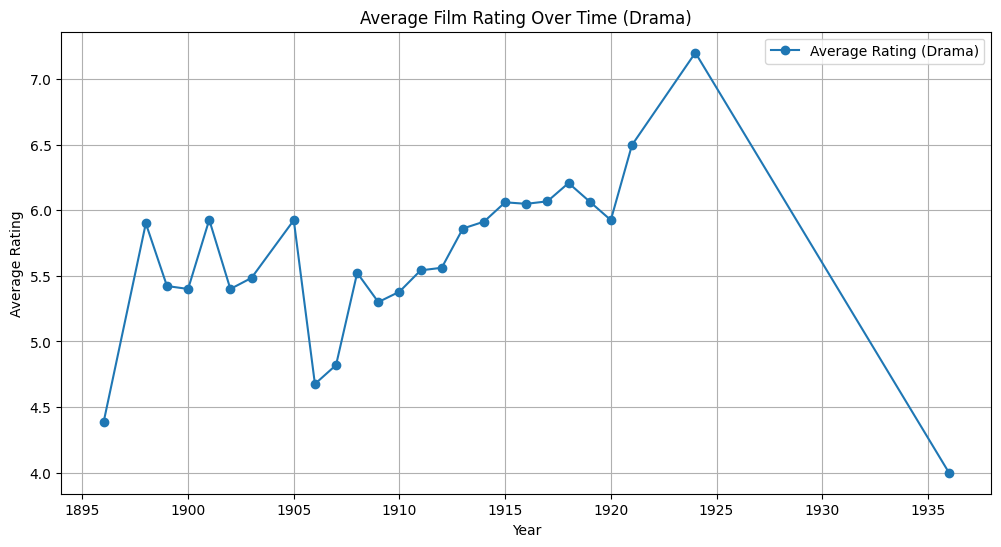

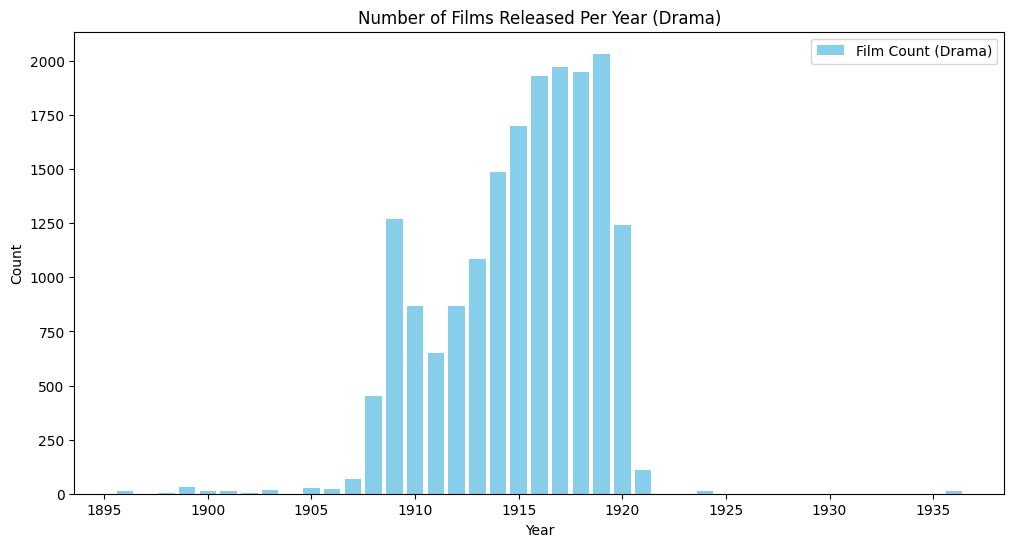

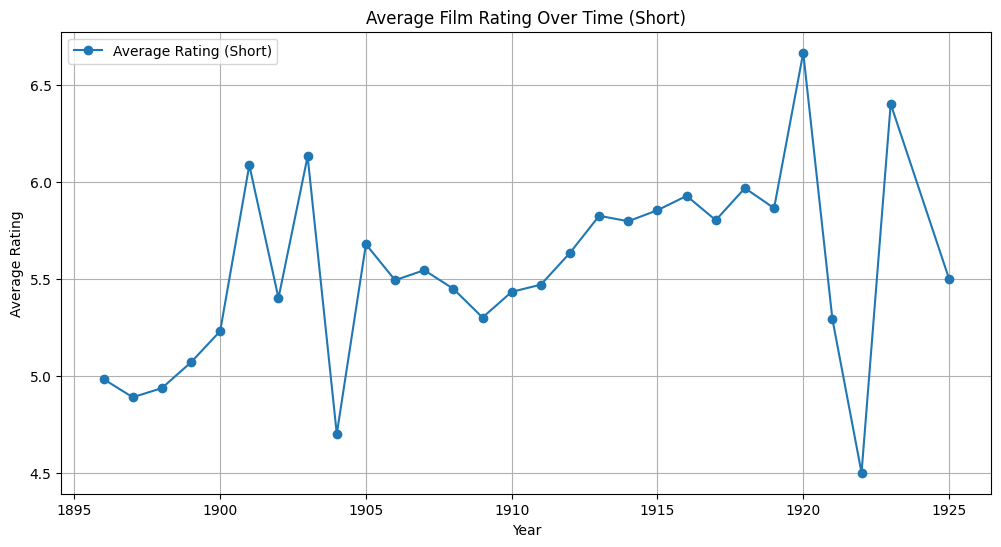

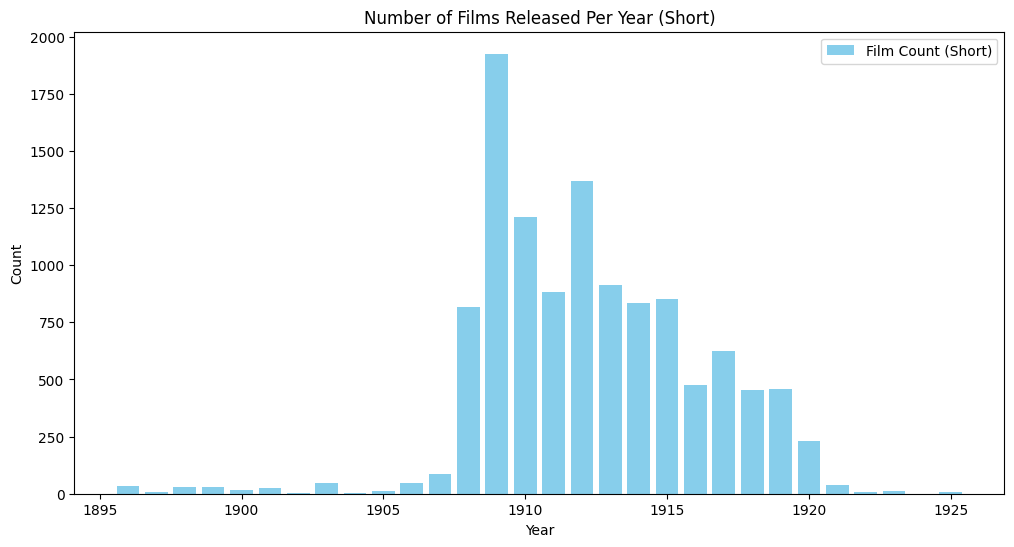

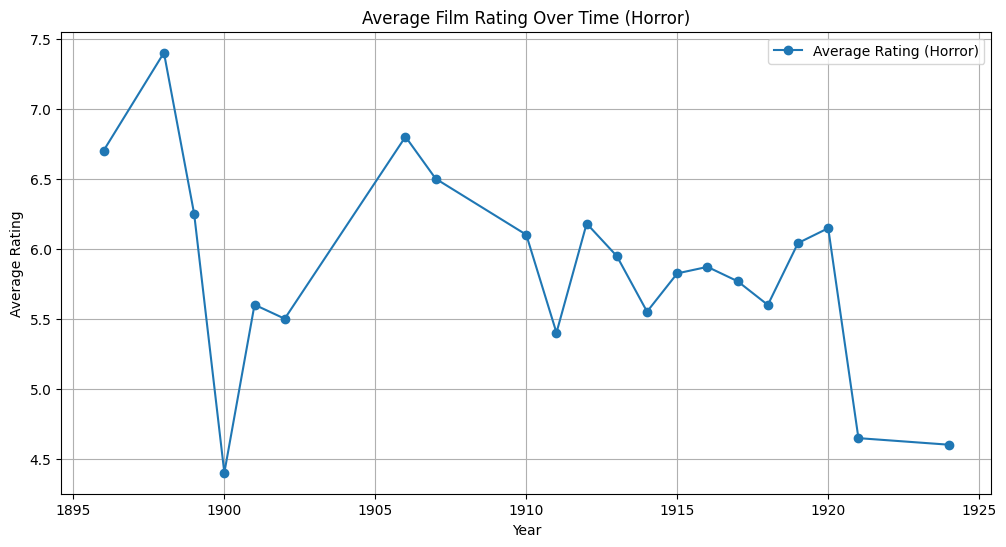

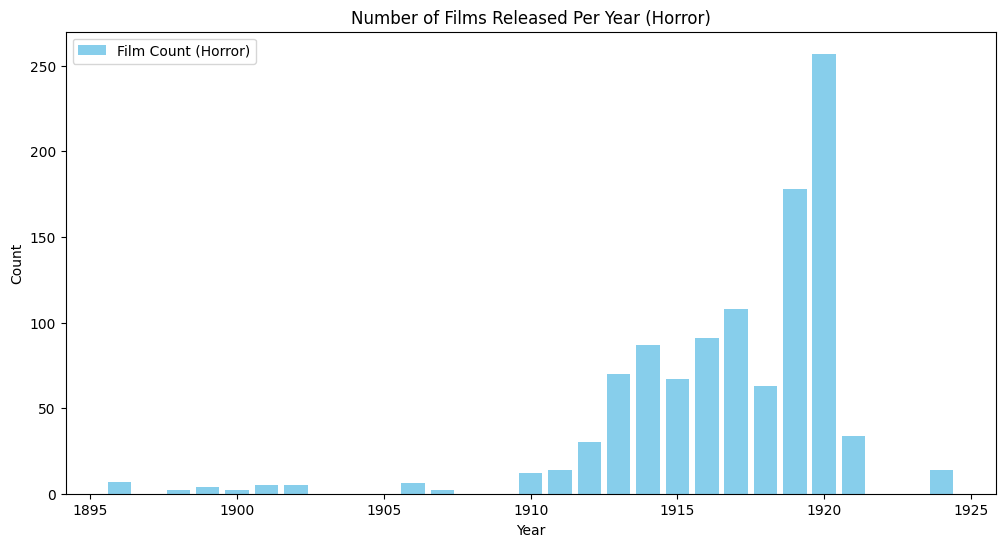

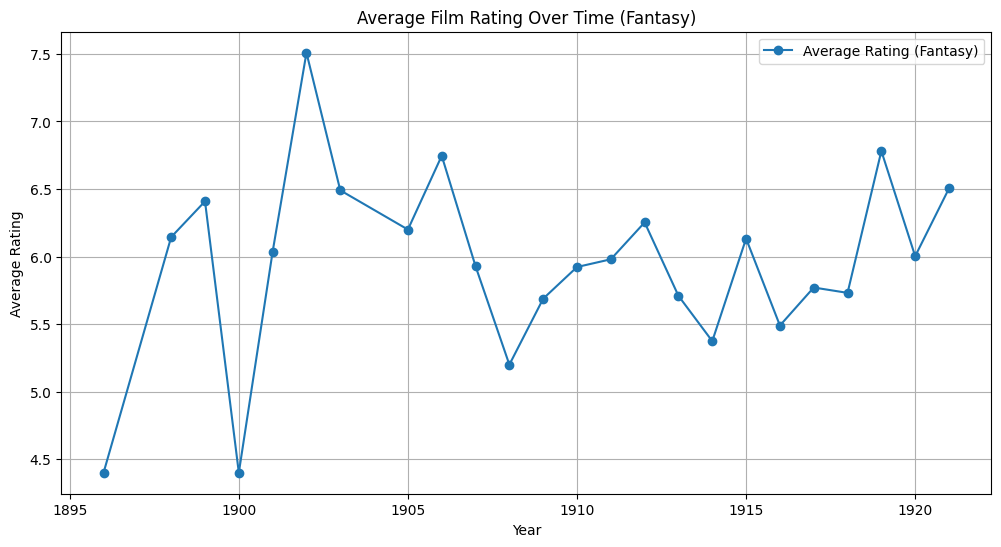

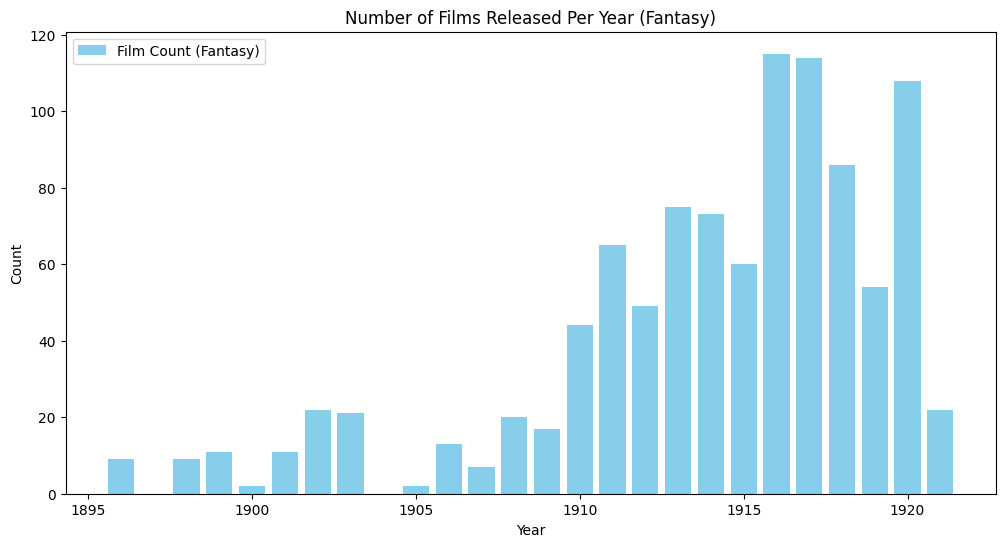

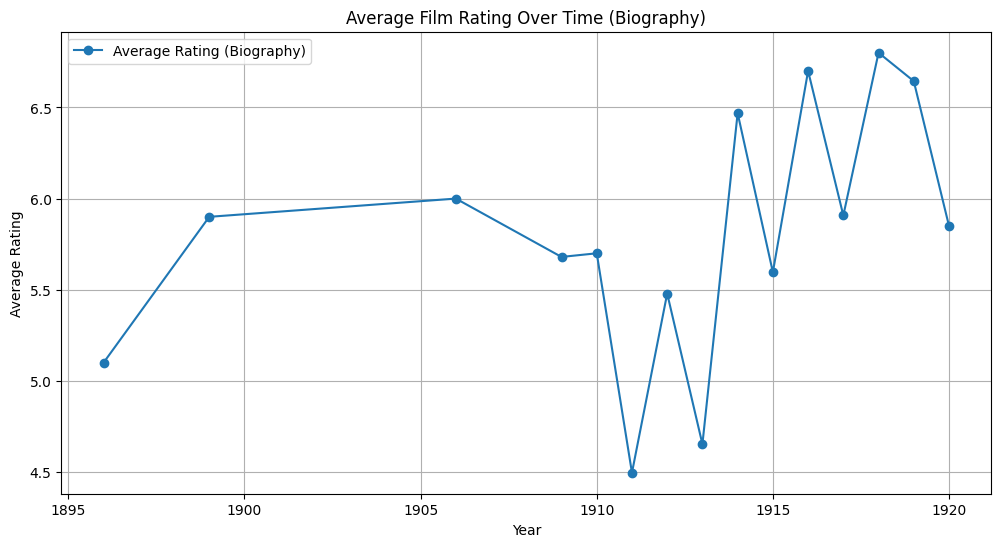

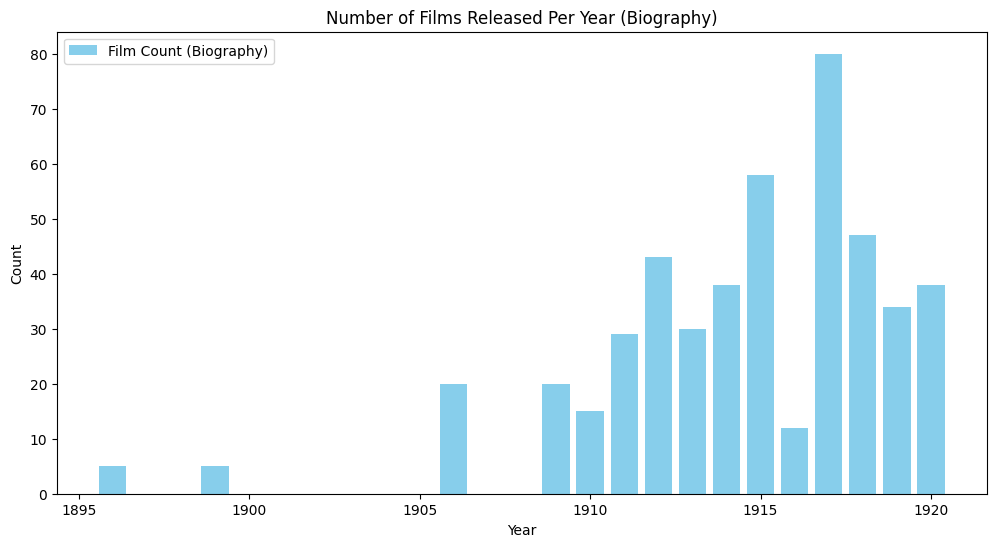

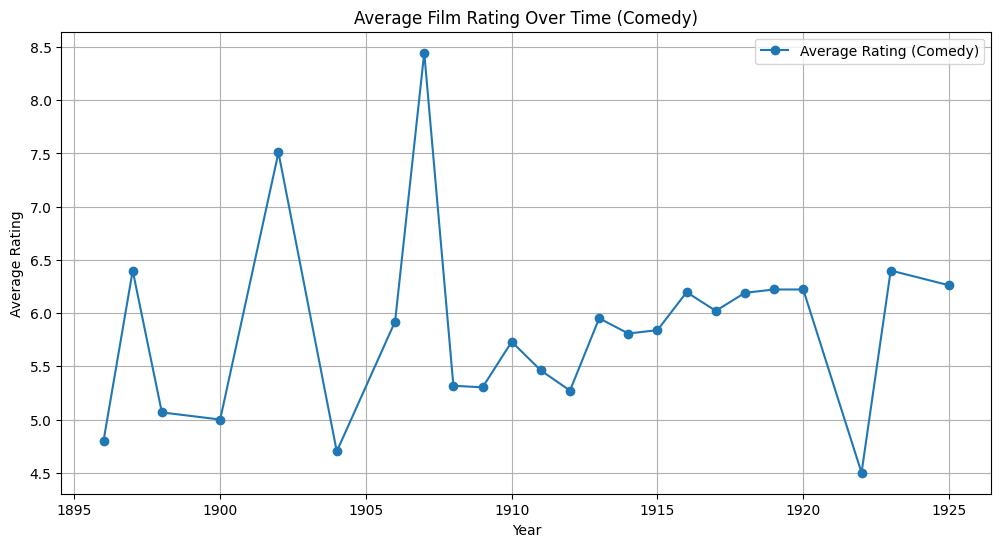

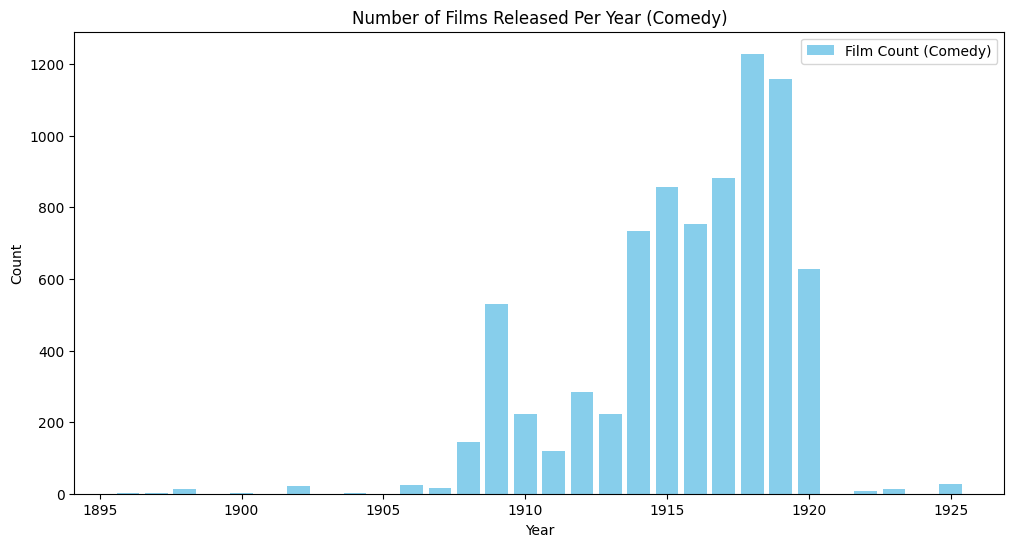

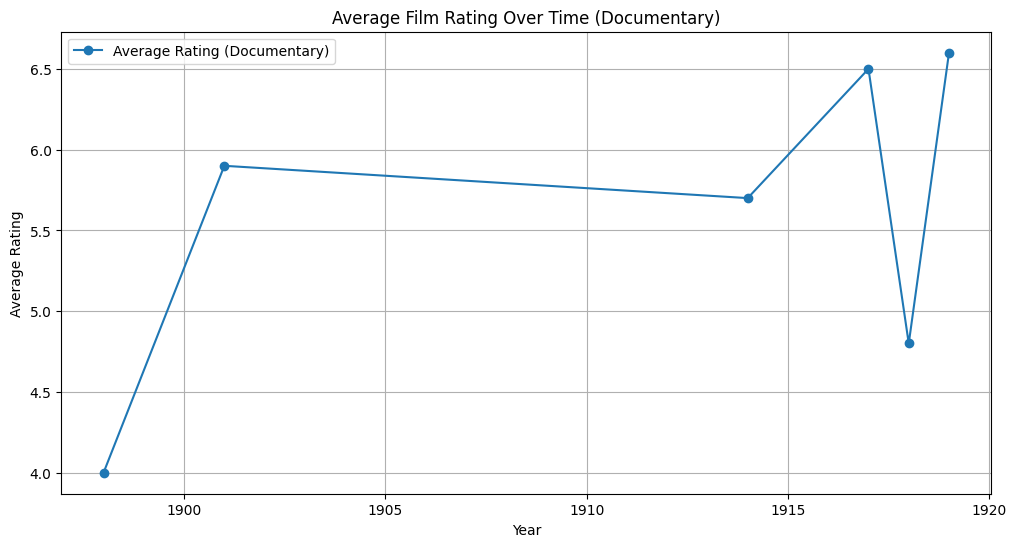

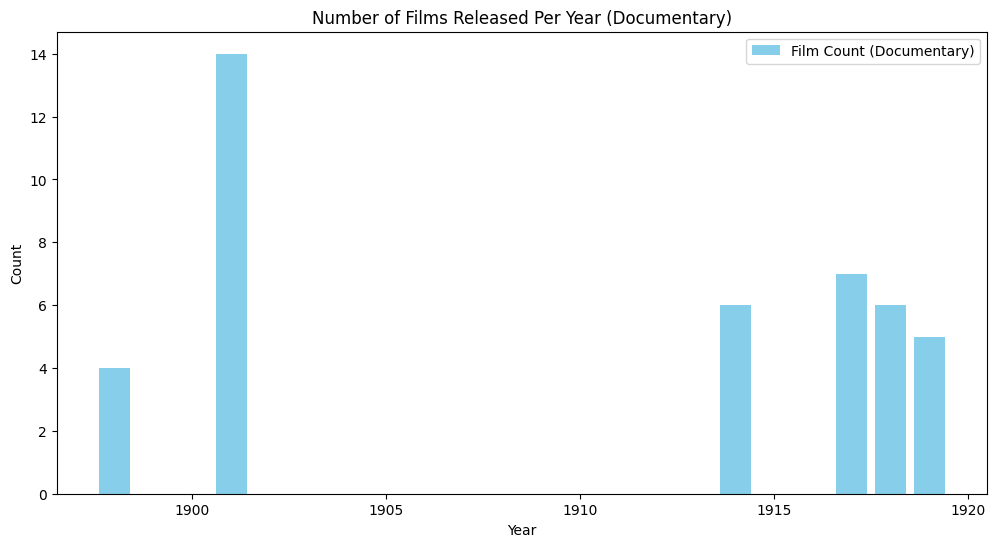

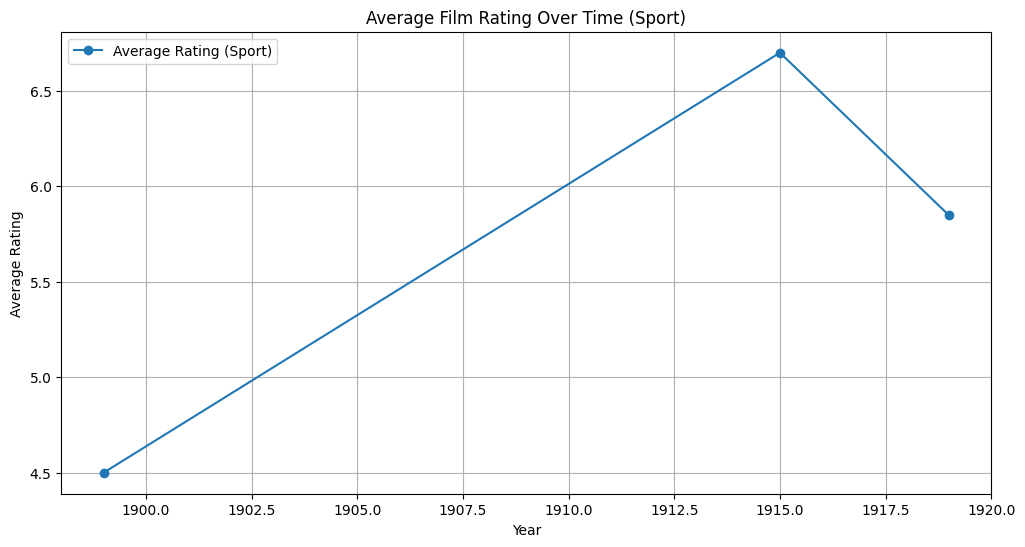

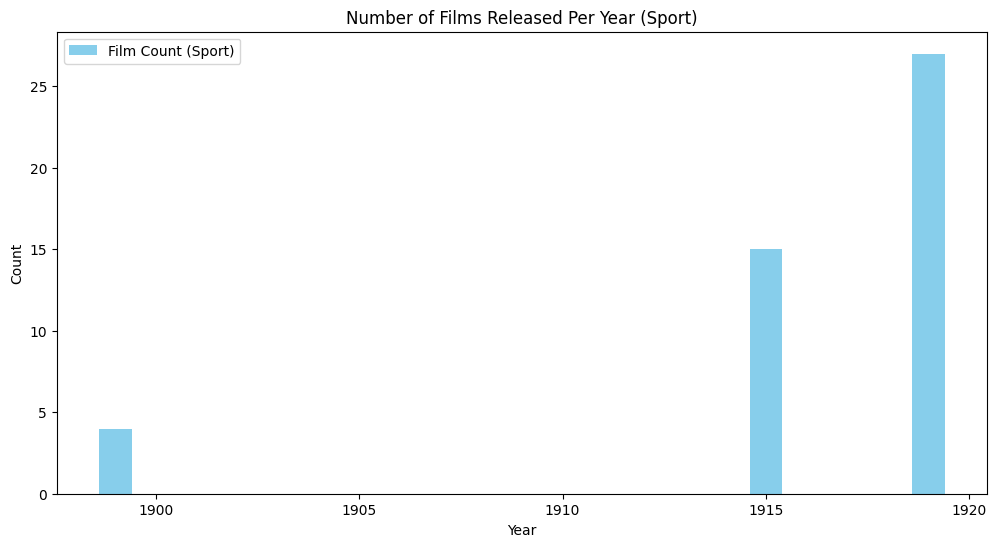

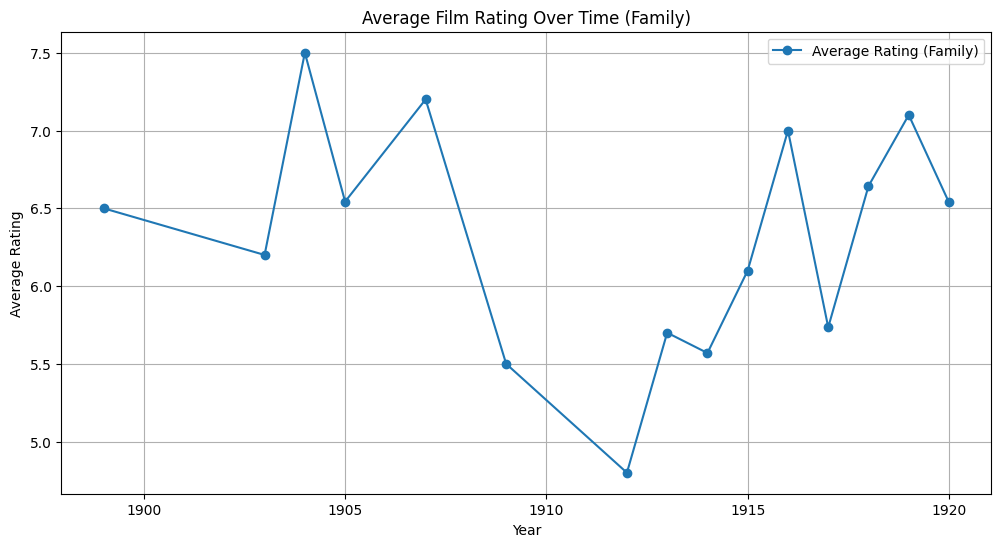

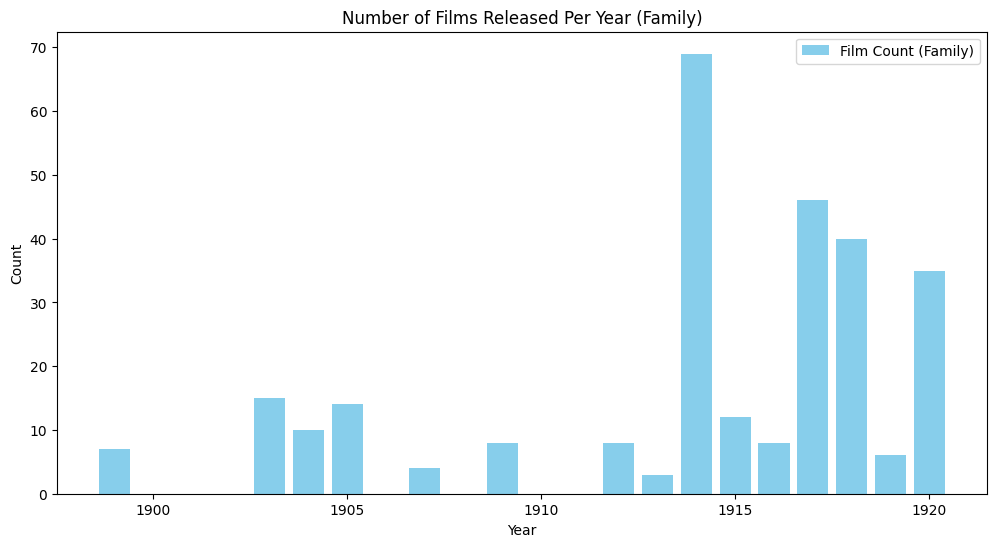

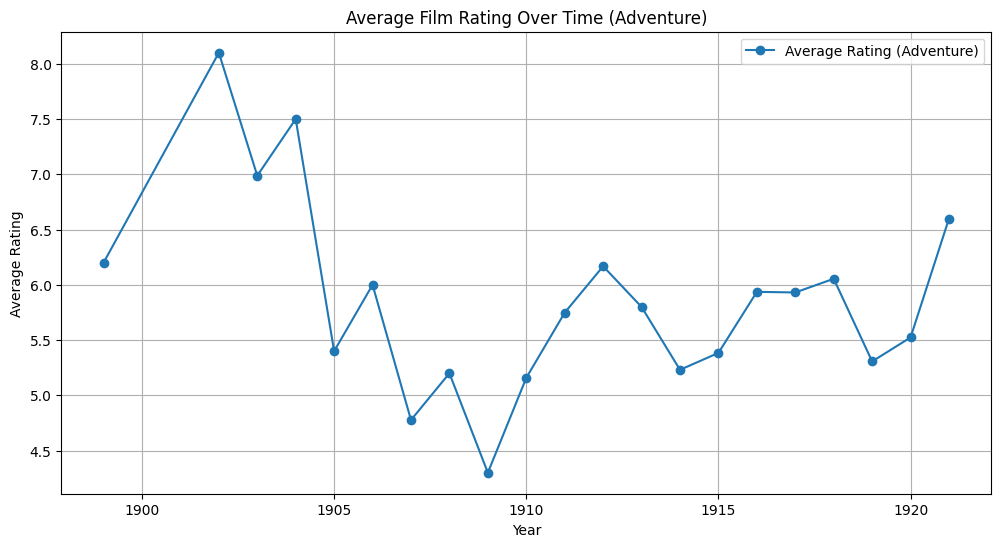

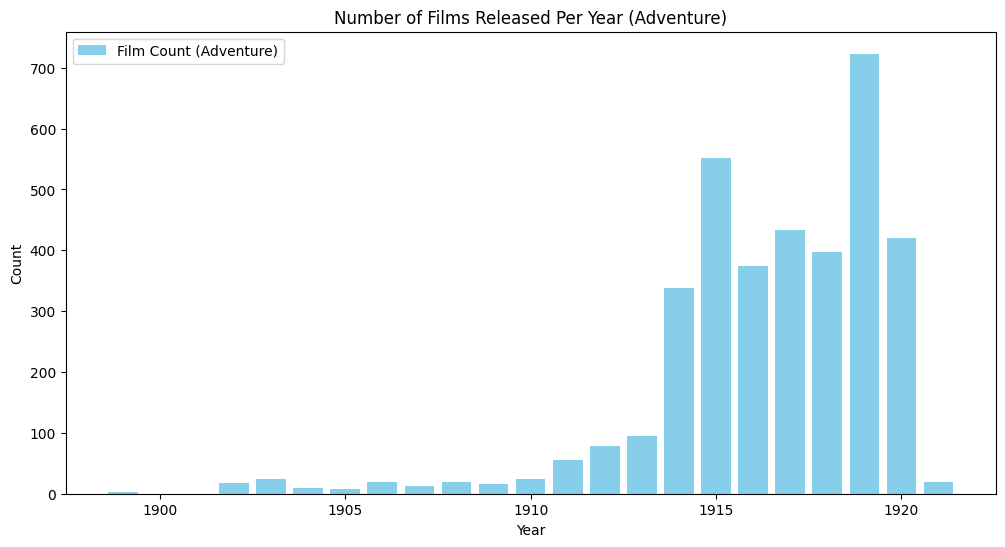

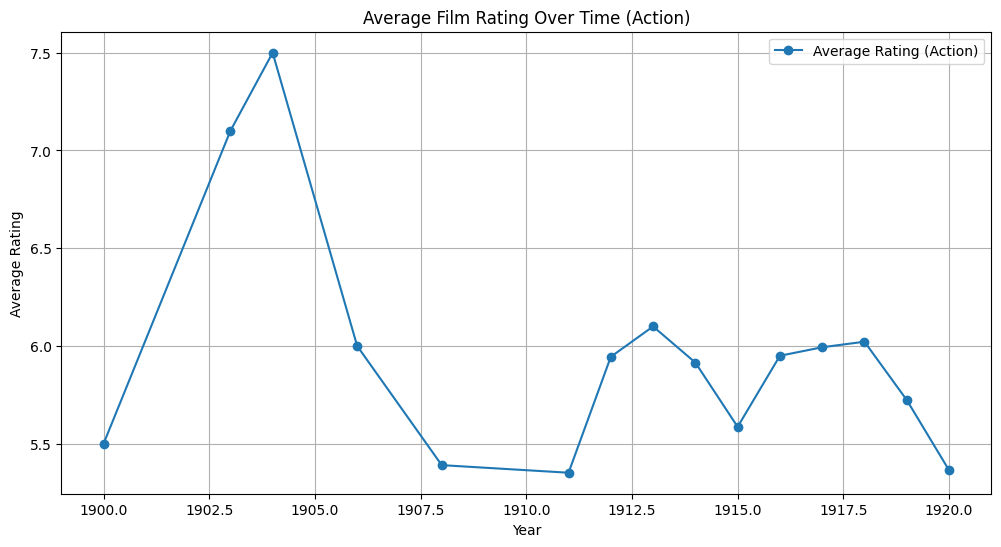

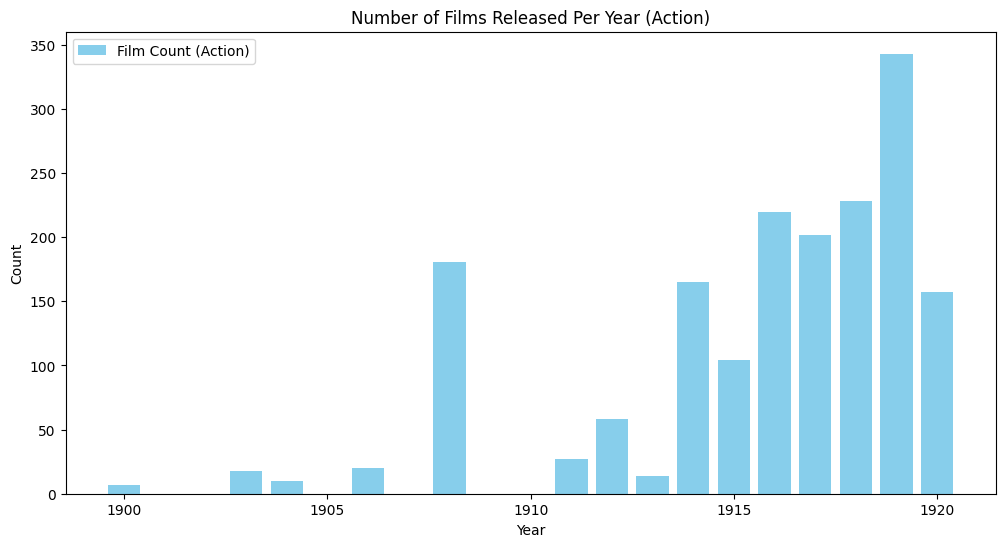

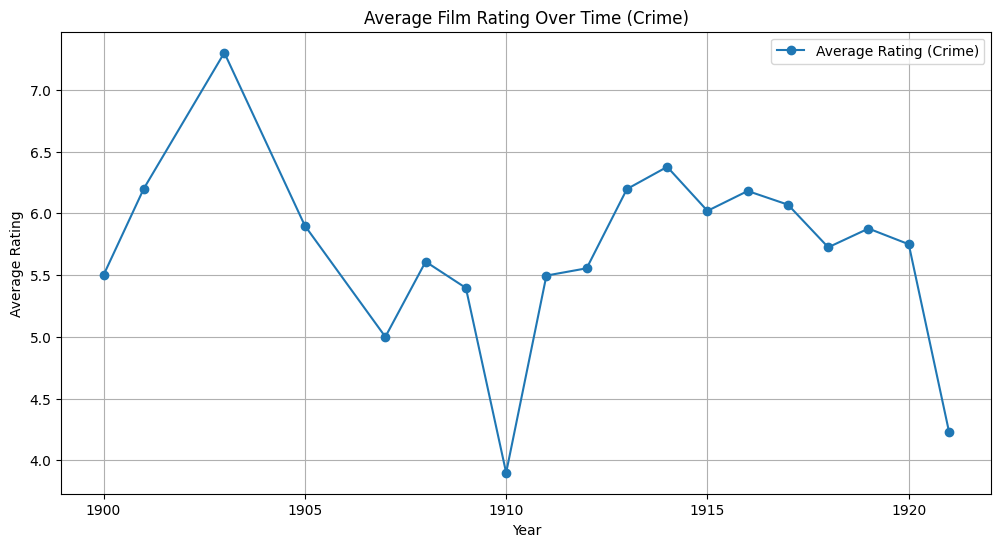

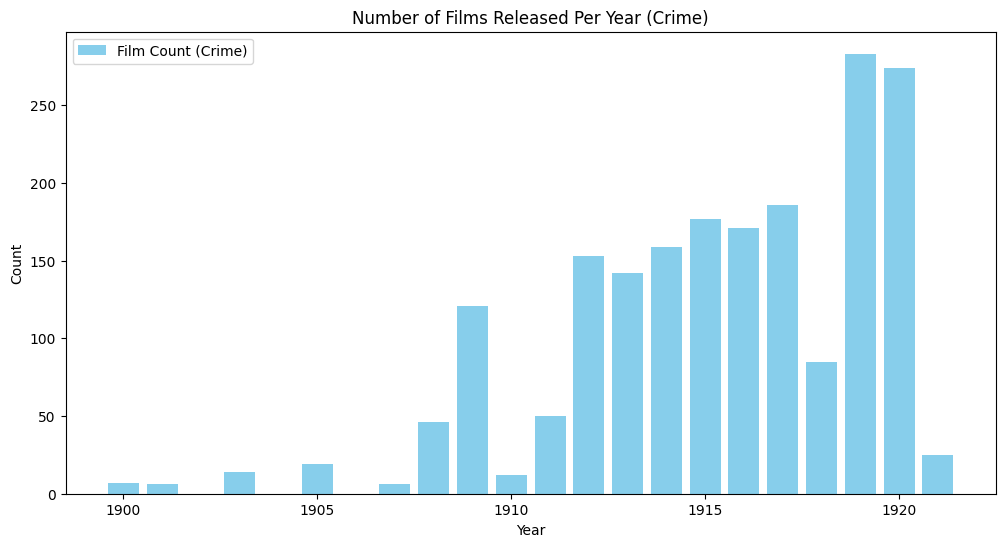

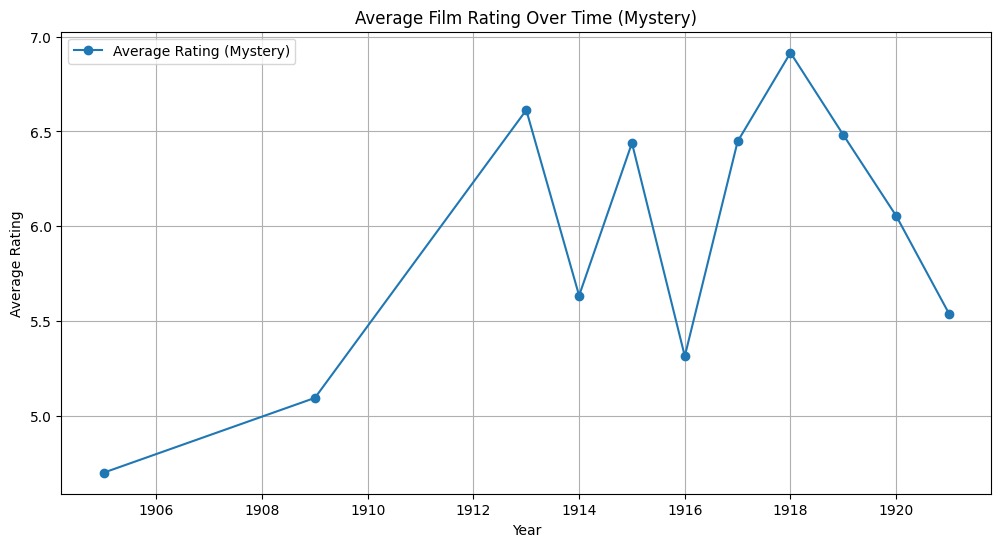

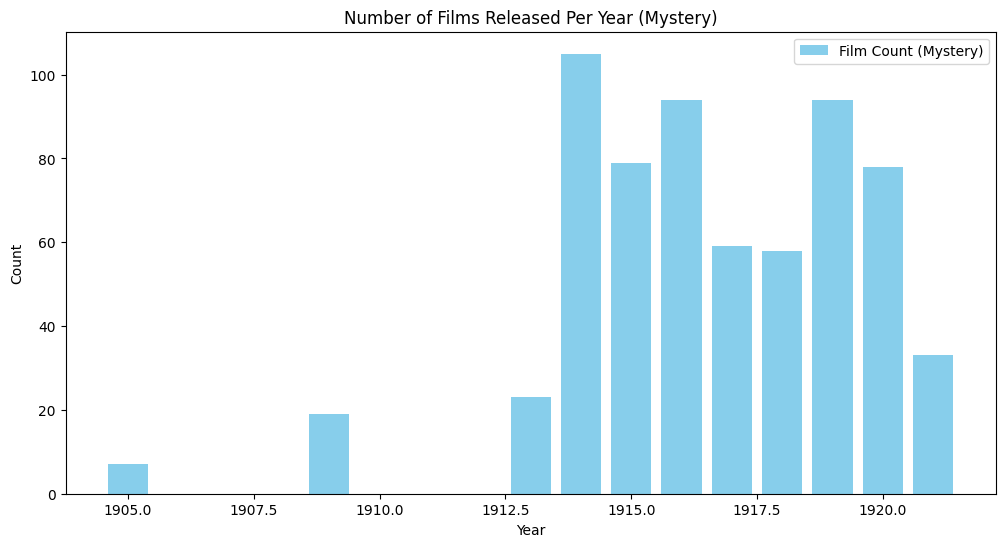

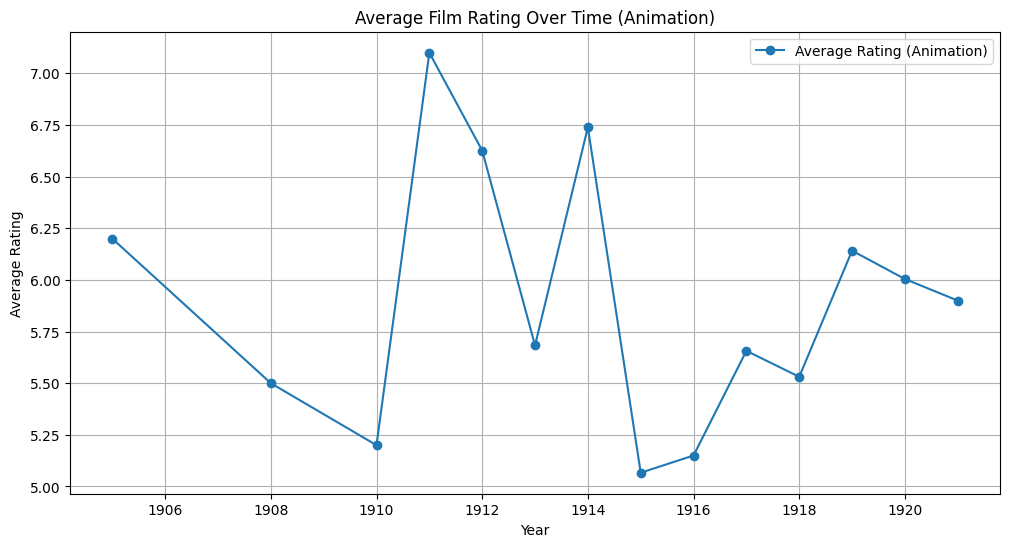

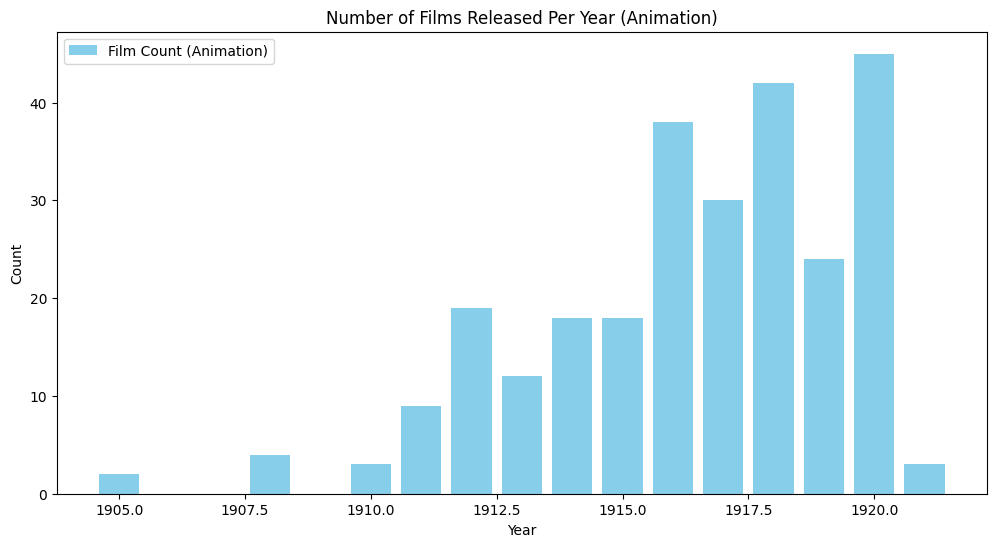

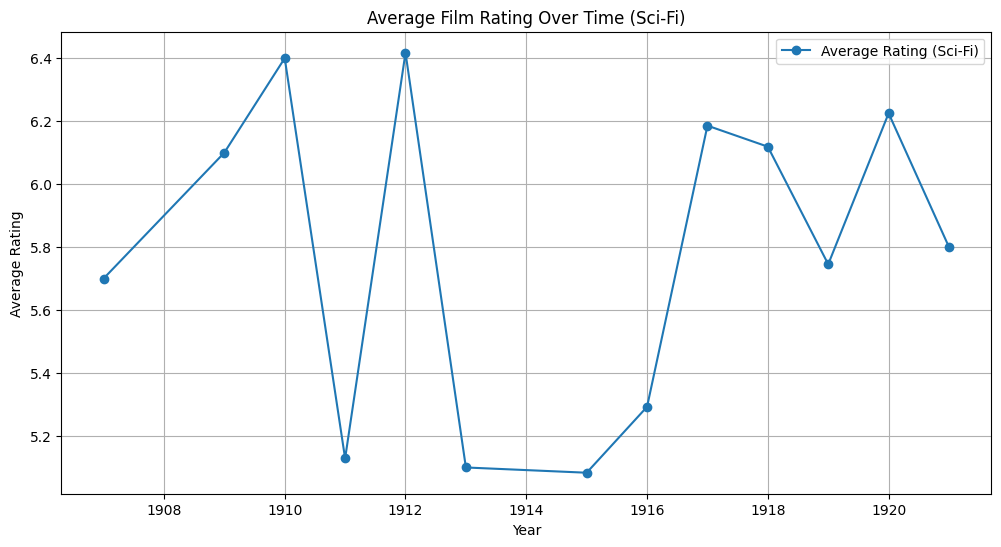

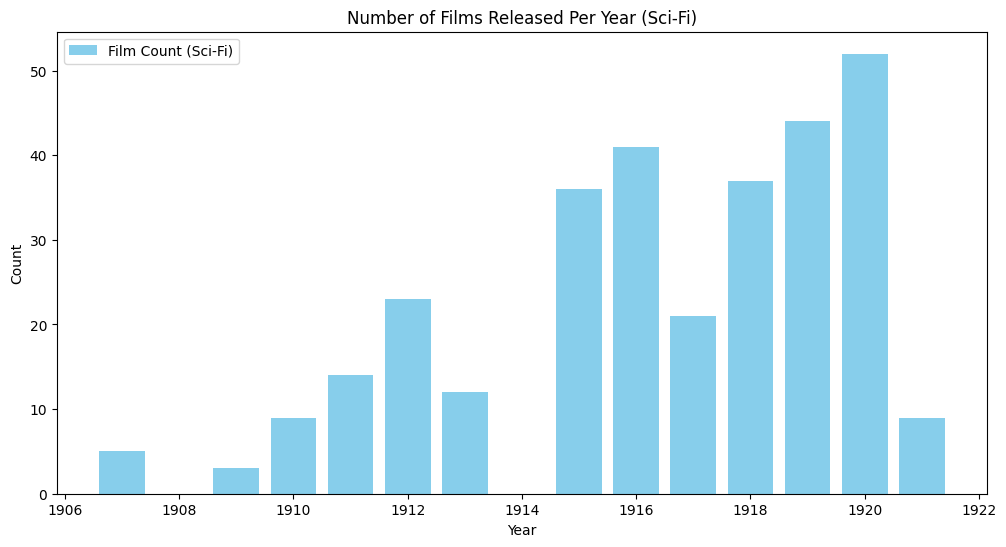

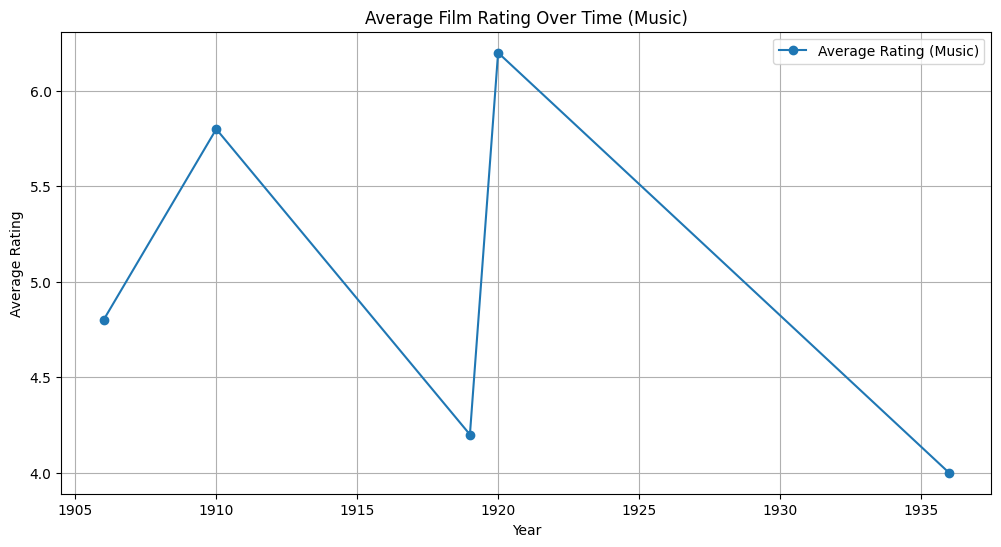

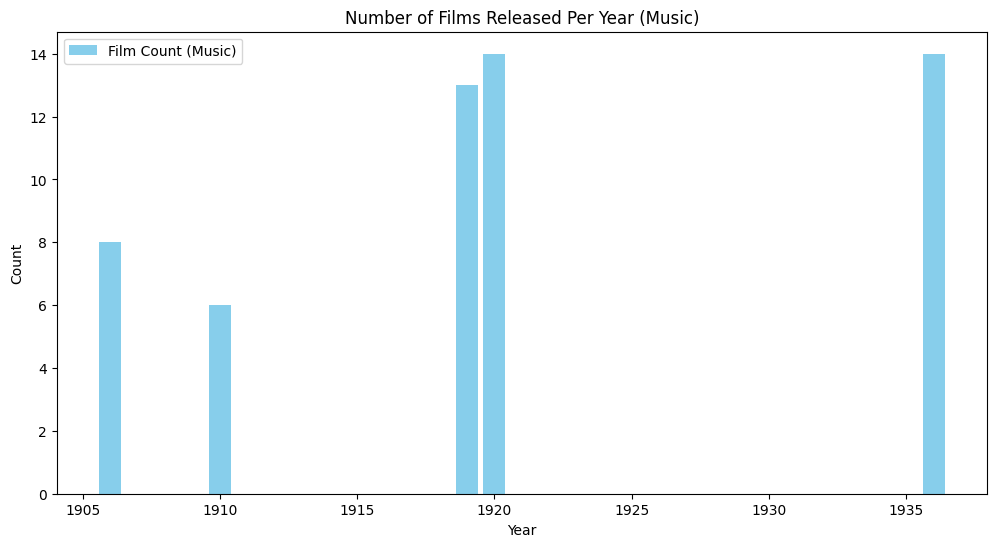

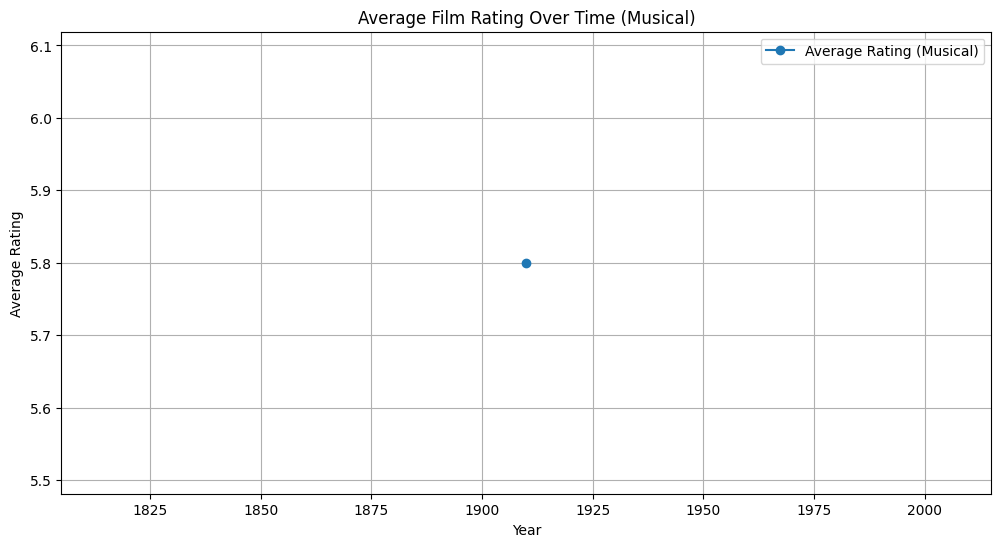

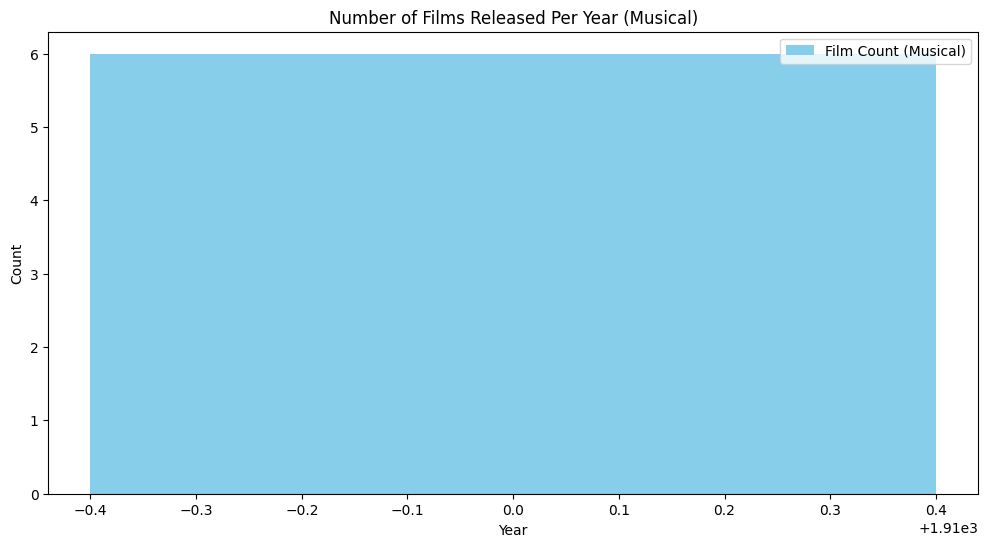

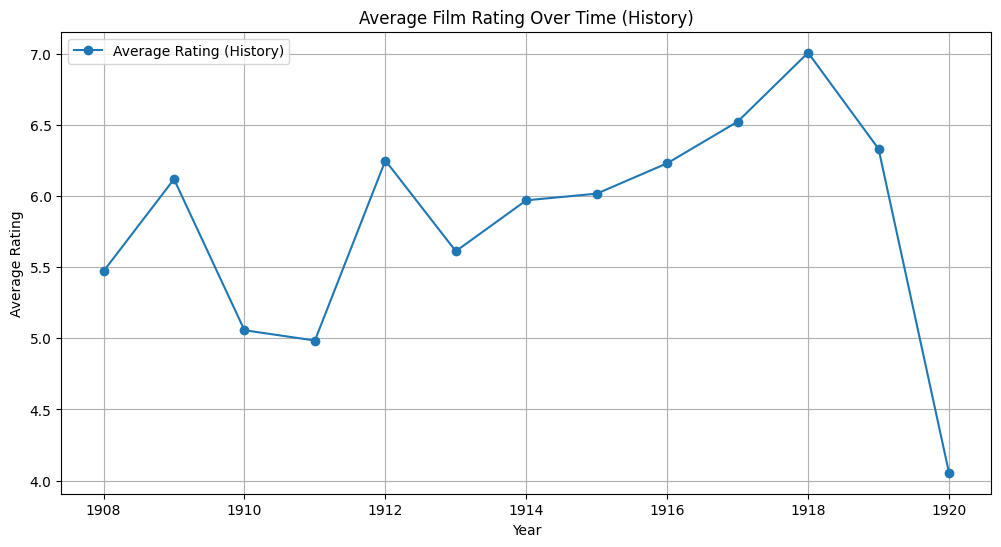

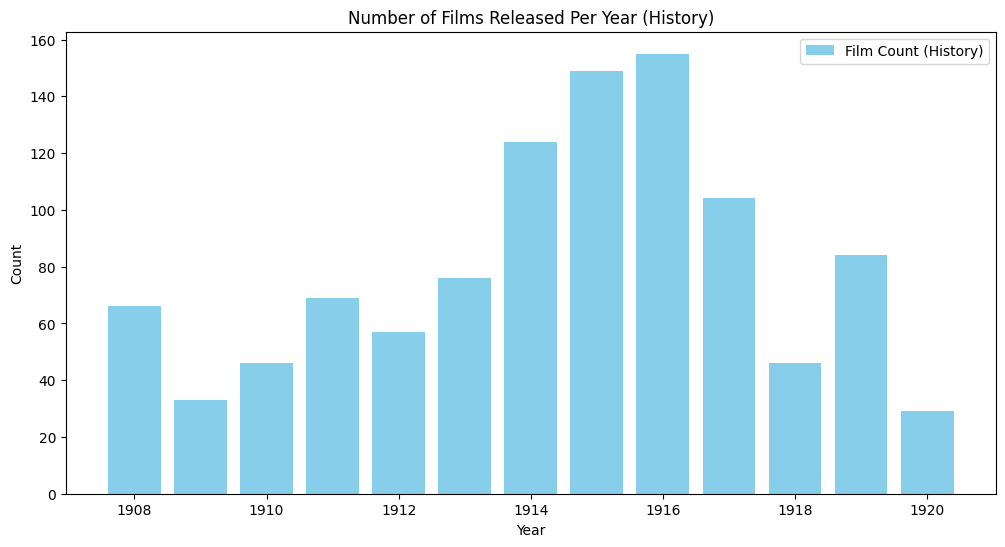

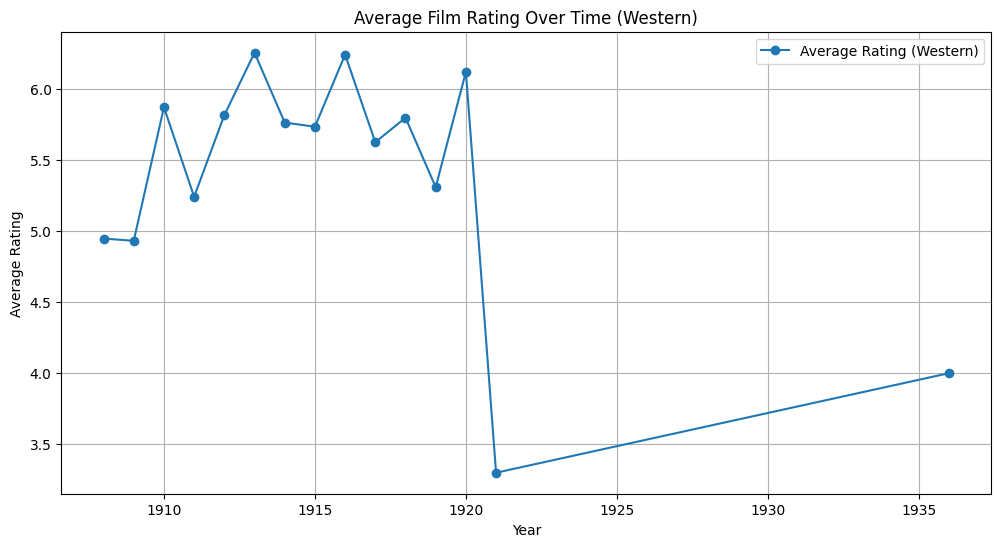

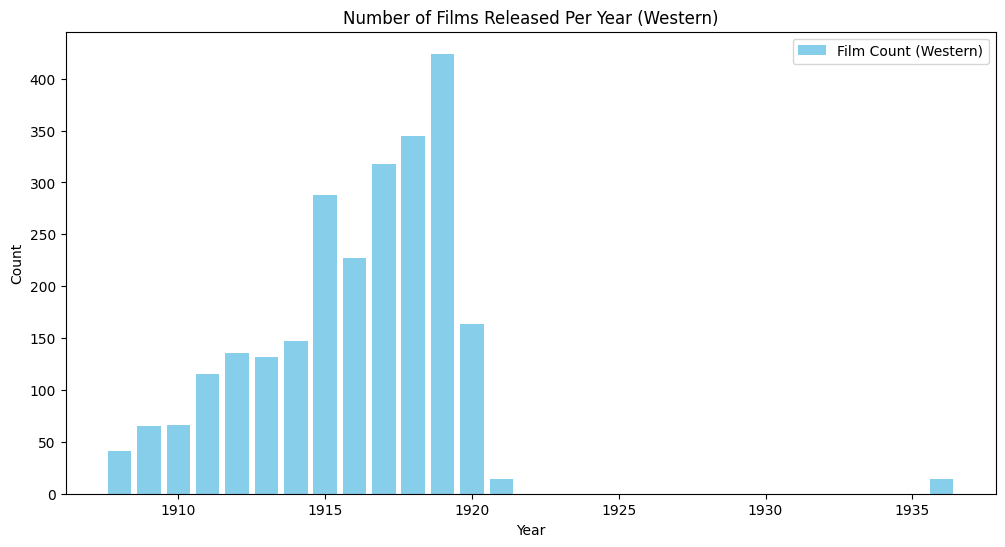

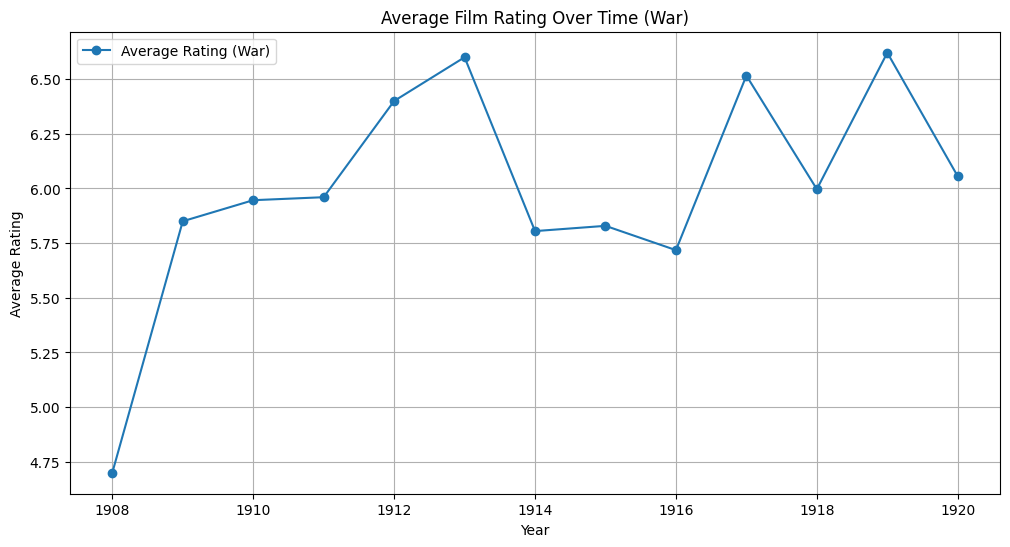

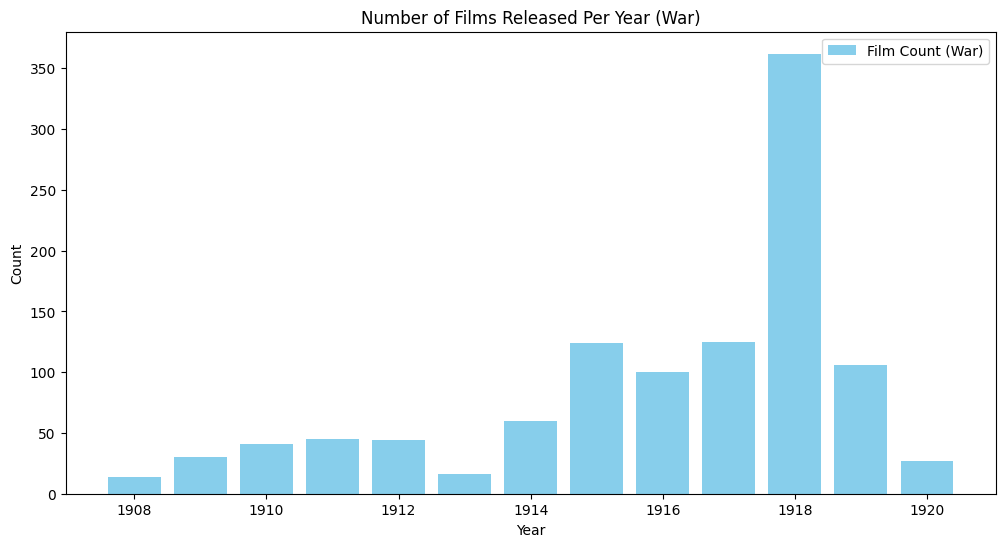

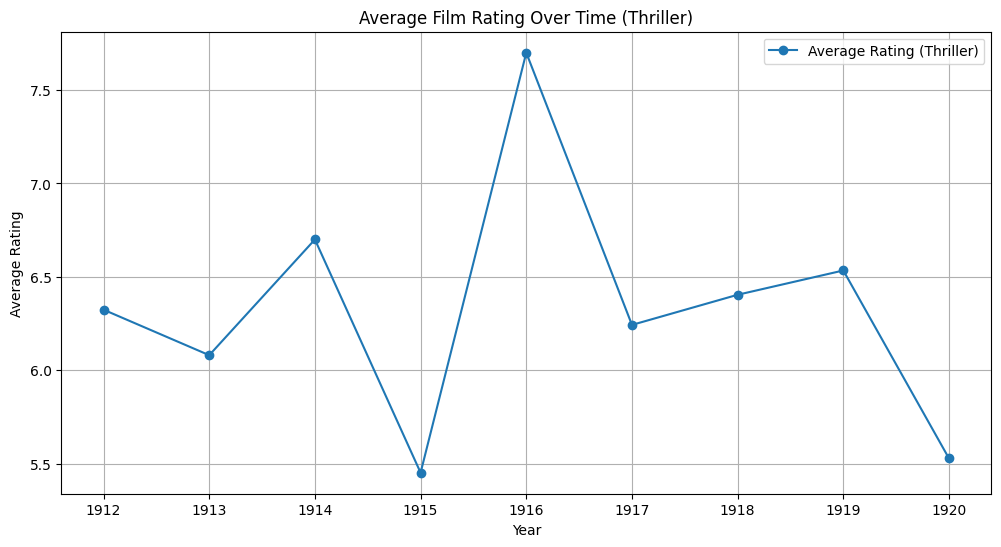

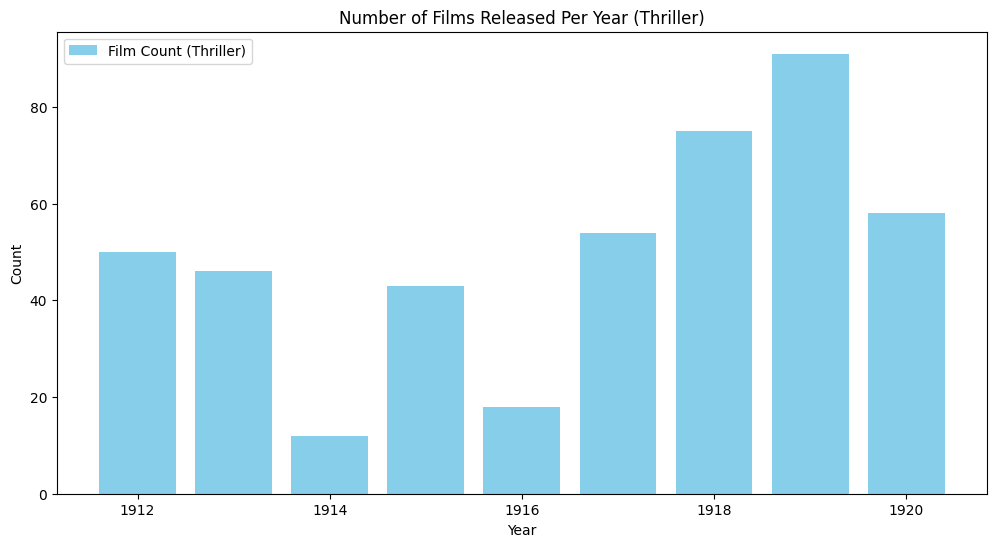

Evaluation for Romance:
Mean Absolute Error: 0.6558290053967863
Mean Squared Error: 0.7329552860010111


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

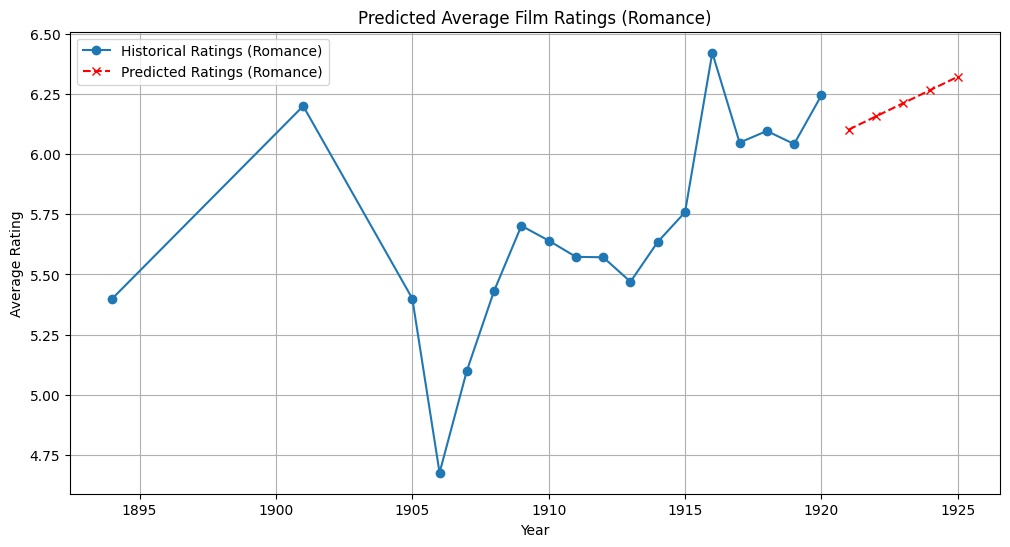

/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')


Predicted Ratings for Future Years (Romance):

Year 1921: 6.10
Year 1922: 6.16
Year 1923: 6.21
Year 1924: 6.27
Year 1925: 6.32
Evaluation for Drama:
Mean Absolute Error: 0.6938898932593164
Mean Squared Error: 0.6840454376462891


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['nconst'] = genre_df['nconst'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['director_count'] = genre_df['directors'].apply(lambda x: len(x.split(',')))
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:93: SettingWithCopyWarning: 
A value i

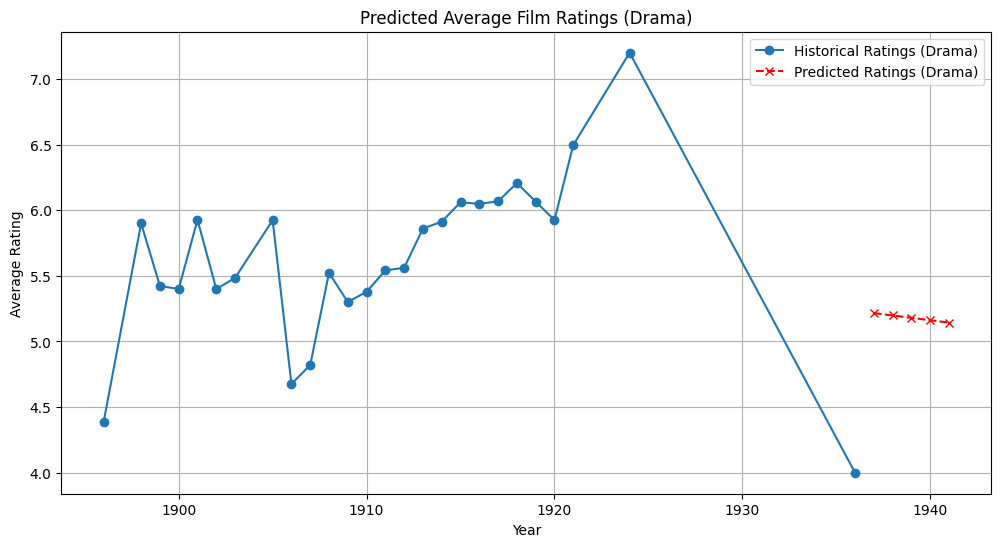

Predicted Ratings for Future Years (Drama):

Year 1937: 5.22
Year 1938: 5.20
Year 1939: 5.18
Year 1940: 5.16
Year 1941: 5.14


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

Evaluation for Short:
Mean Absolute Error: 0.36967776225104404
Mean Squared Error: 0.20049033897755872


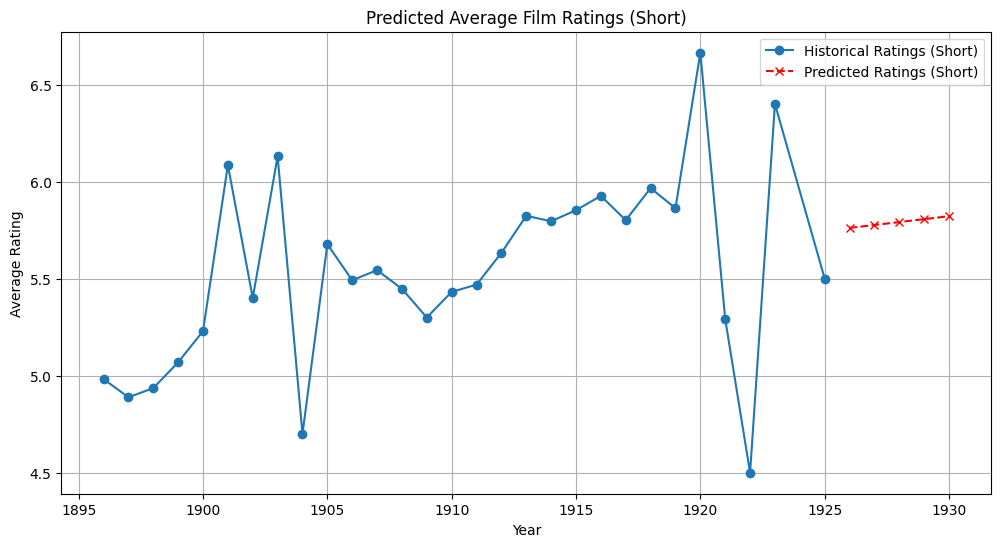

Predicted Ratings for Future Years (Short):

Year 1926: 5.76
Year 1927: 5.78
Year 1928: 5.79
Year 1929: 5.81
Year 1930: 5.82
Evaluation for Horror:
Mean Absolute Error: 0.8607248567909155
Mean Squared Error: 0.9670753682638391


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

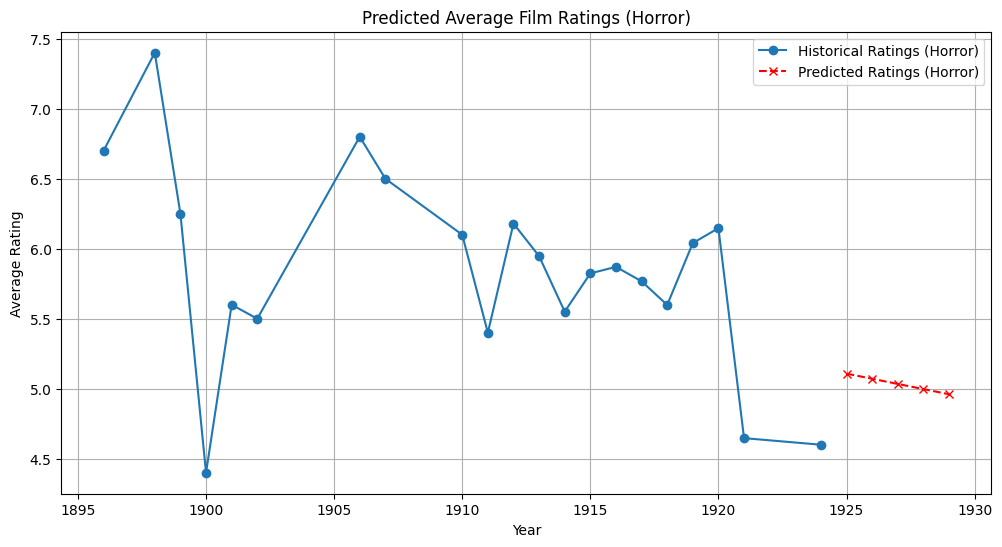

Predicted Ratings for Future Years (Horror):

Year 1925: 5.11
Year 1926: 5.07
Year 1927: 5.03
Year 1928: 5.00
Year 1929: 4.96
Evaluation for Fantasy:
Mean Absolute Error: 0.7930619302898915
Mean Squared Error: 0.882659523281994


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

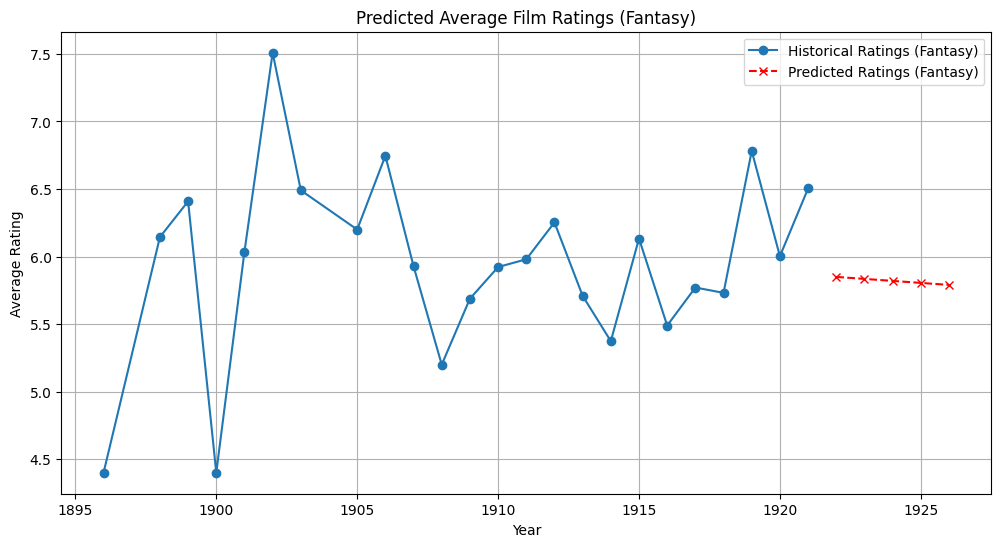

Predicted Ratings for Future Years (Fantasy):

Year 1922: 5.85
Year 1923: 5.83
Year 1924: 5.82
Year 1925: 5.81
Year 1926: 5.79
Evaluation for Biography:
Mean Absolute Error: 0.3225342970079869
Mean Squared Error: 0.11936596026939096


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

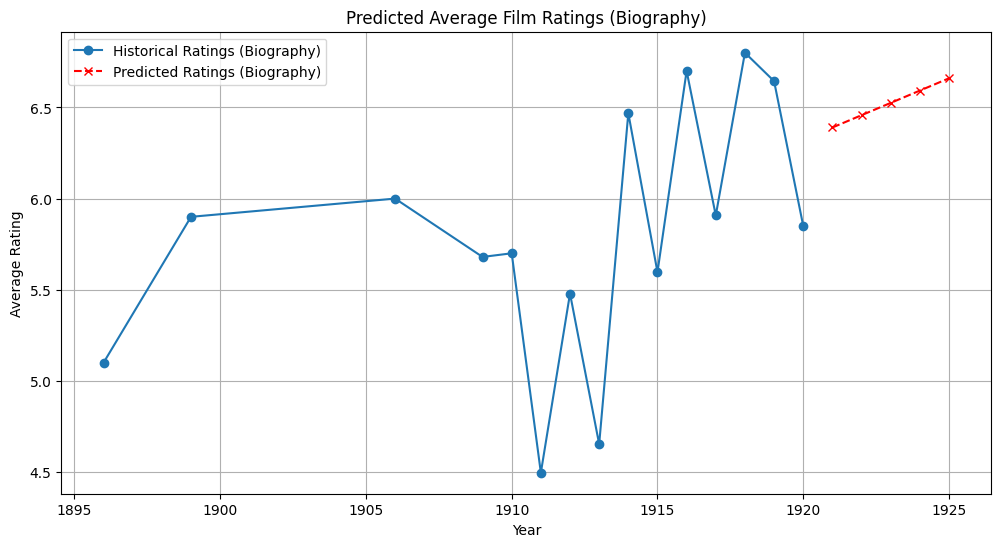

Predicted Ratings for Future Years (Biography):

Year 1921: 6.39
Year 1922: 6.46
Year 1923: 6.52
Year 1924: 6.59
Year 1925: 6.66
Evaluation for Comedy:
Mean Absolute Error: 1.0937162449074298
Mean Squared Error: 4.730657189168408


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

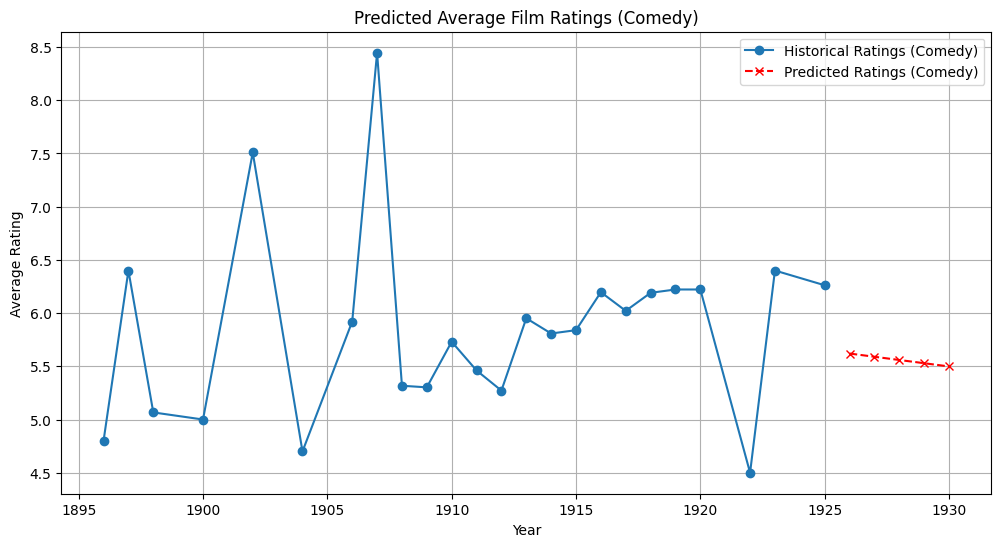

Predicted Ratings for Future Years (Comedy):

Year 1926: 5.62
Year 1927: 5.59
Year 1928: 5.56
Year 1929: 5.53
Year 1930: 5.50
Evaluation for Documentary:
Mean Absolute Error: 0.8535714285714251
Mean Squared Error: 0.7592091836734616


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

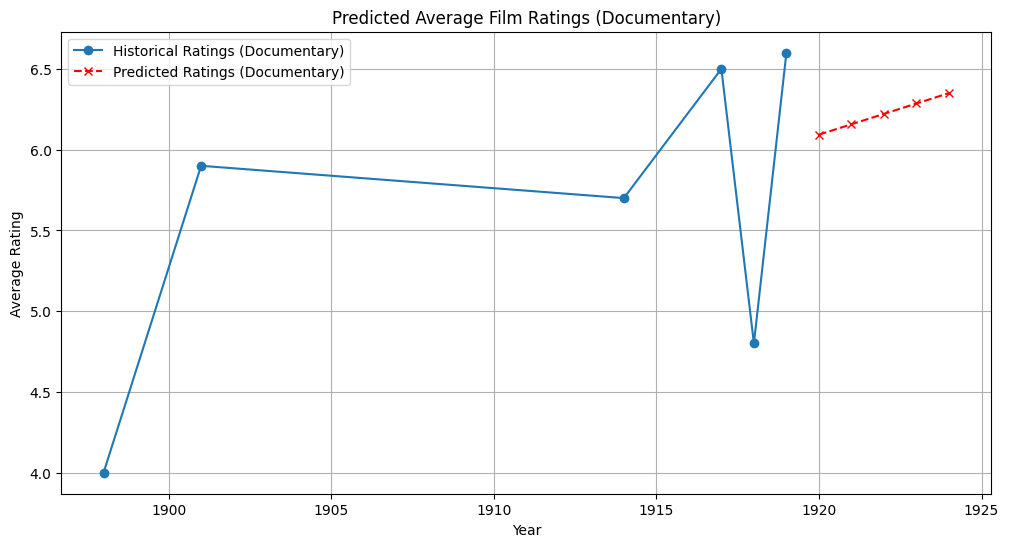

Predicted Ratings for Future Years (Documentary):

Year 1920: 6.09
Year 1921: 6.16
Year 1922: 6.22
Year 1923: 6.29
Year 1924: 6.35
Evaluation for Sport:
Mean Absolute Error: 5.406971677559966
Mean Squared Error: 29.23534272193563


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

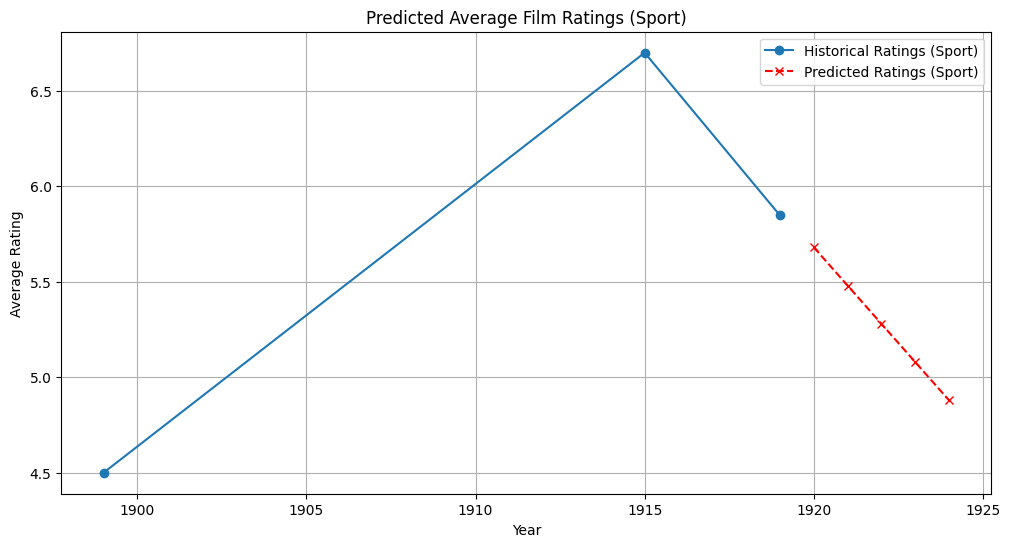

Predicted Ratings for Future Years (Sport):

Year 1920: 5.68
Year 1921: 5.48
Year 1922: 5.28
Year 1923: 5.08
Year 1924: 4.88
Evaluation for Family:
Mean Absolute Error: 0.7451436134158552
Mean Squared Error: 0.6008319856567906


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

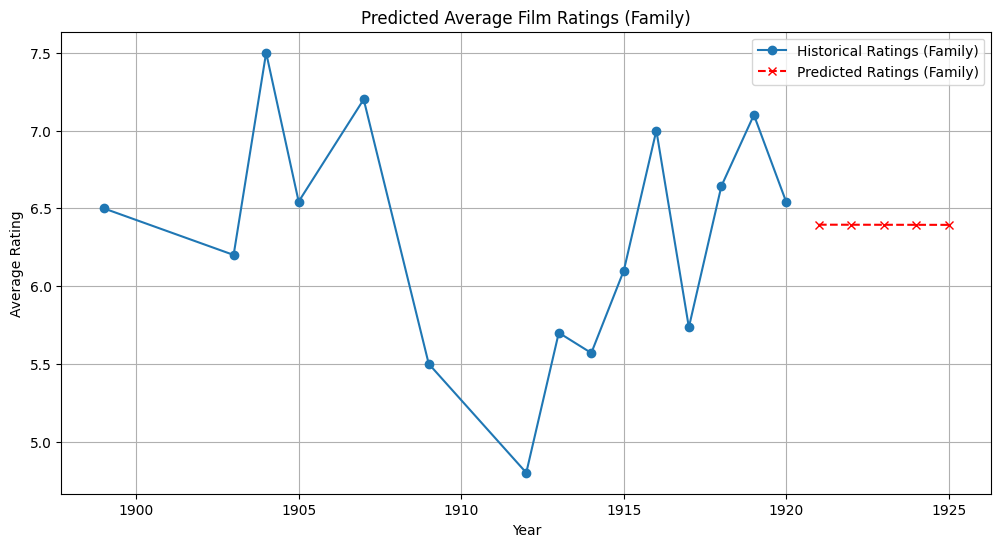

Predicted Ratings for Future Years (Family):

Year 1921: 6.39
Year 1922: 6.39
Year 1923: 6.39
Year 1924: 6.39
Year 1925: 6.39


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

Evaluation for Adventure:
Mean Absolute Error: 0.8332943247186033
Mean Squared Error: 0.980344340738663


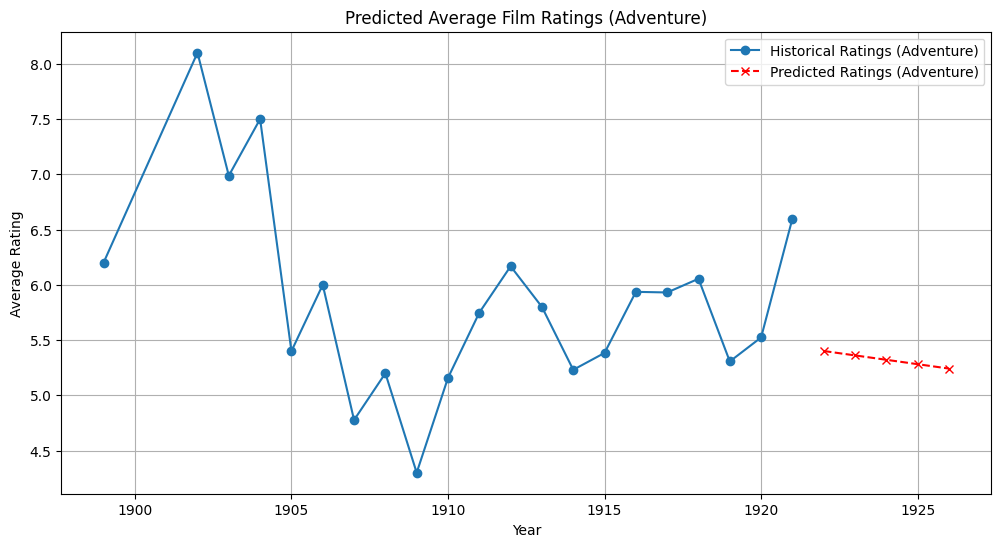

Predicted Ratings for Future Years (Adventure):

Year 1922: 5.40
Year 1923: 5.36
Year 1924: 5.32
Year 1925: 5.28
Year 1926: 5.24


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

Evaluation for Action:
Mean Absolute Error: 0.42681646810288765
Mean Squared Error: 0.3354518830113768


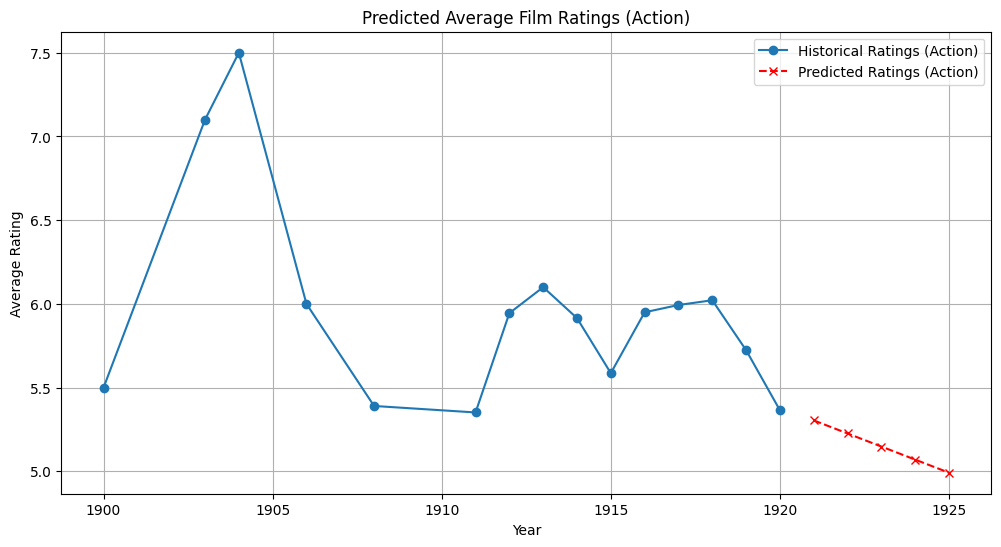

Predicted Ratings for Future Years (Action):

Year 1921: 5.30
Year 1922: 5.23
Year 1923: 5.15
Year 1924: 5.07
Year 1925: 4.99
Evaluation for Crime:
Mean Absolute Error: 0.5062629752274166
Mean Squared Error: 0.29267770986743546


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

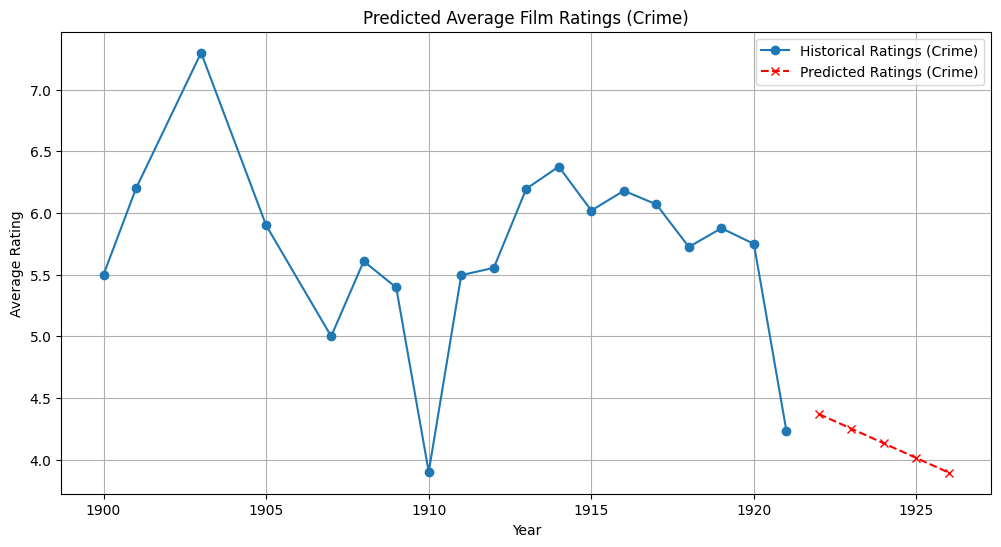

Predicted Ratings for Future Years (Crime):

Year 1922: 4.37
Year 1923: 4.25
Year 1924: 4.13
Year 1925: 4.01
Year 1926: 3.89


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

Evaluation for Mystery:
Mean Absolute Error: 0.5477592311307603
Mean Squared Error: 0.35103824226706287


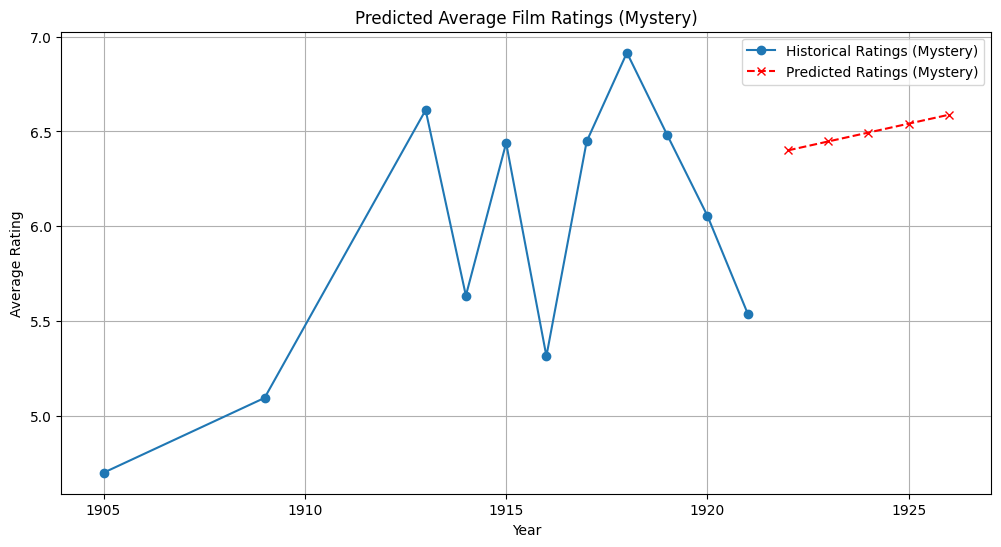

Predicted Ratings for Future Years (Mystery):

Year 1922: 6.40
Year 1923: 6.45
Year 1924: 6.49
Year 1925: 6.54
Year 1926: 6.59
Evaluation for Animation:
Mean Absolute Error: 0.35030303912640576
Mean Squared Error: 0.14044168060926593


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

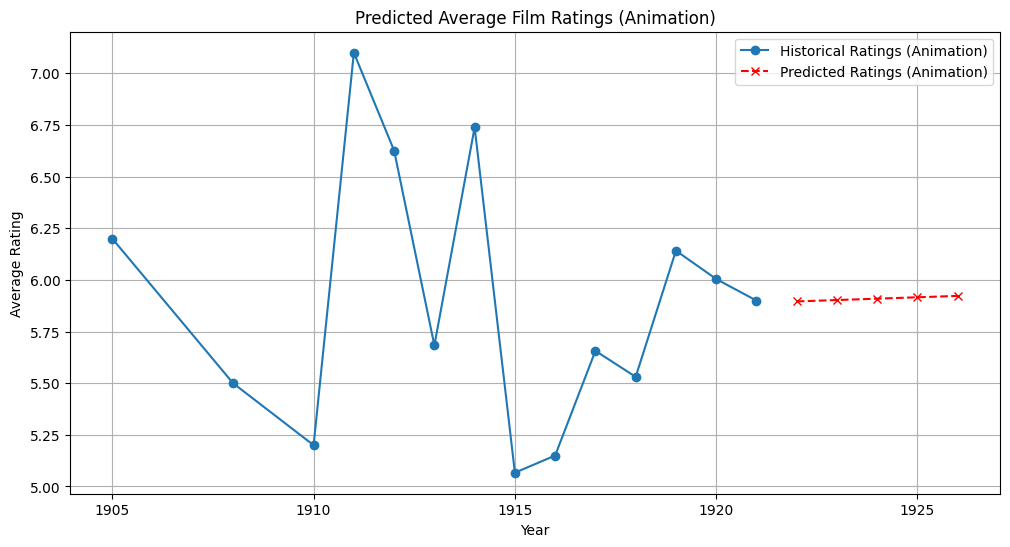

Predicted Ratings for Future Years (Animation):

Year 1922: 5.90
Year 1923: 5.90
Year 1924: 5.91
Year 1925: 5.92
Year 1926: 5.92
Evaluation for Sci-Fi:
Mean Absolute Error: 0.40741931535707526
Mean Squared Error: 0.22185604146428886


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

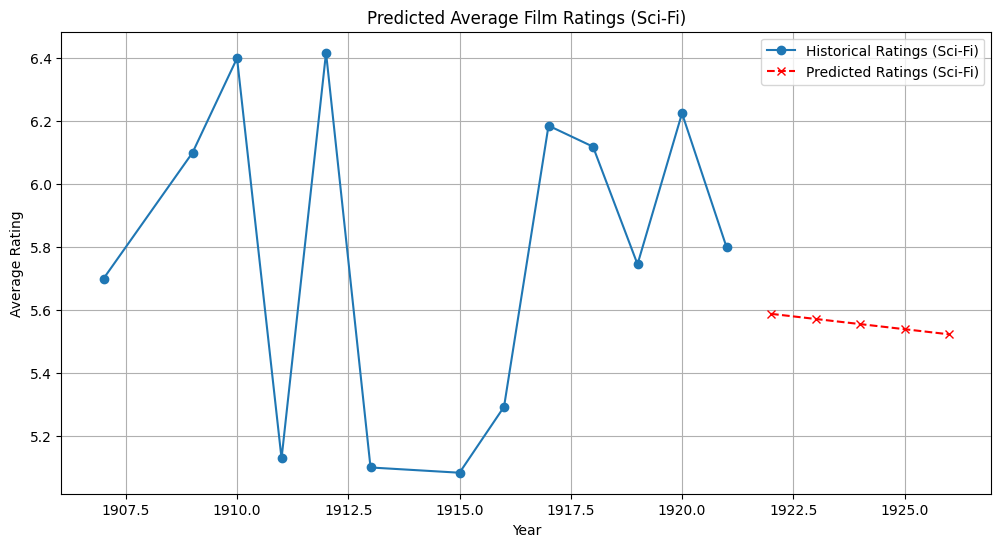

Predicted Ratings for Future Years (Sci-Fi):

Year 1922: 5.59
Year 1923: 5.57
Year 1924: 5.56
Year 1925: 5.54
Year 1926: 5.52
Evaluation for Music:
Mean Absolute Error: 53.8
Mean Squared Error: 2894.4399999999996


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

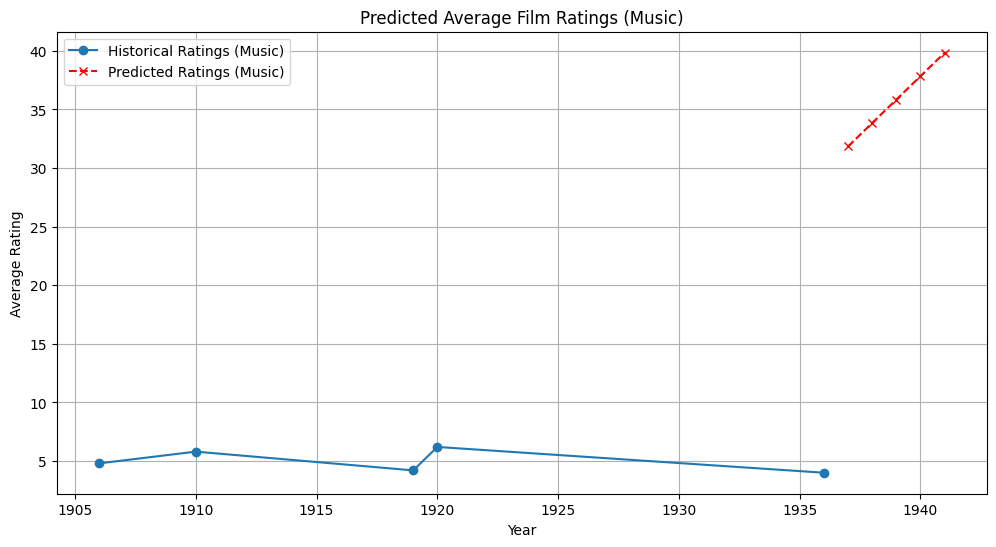

Predicted Ratings for Future Years (Music):

Year 1937: 31.84
Year 1938: 33.84
Year 1939: 35.84
Year 1940: 37.84
Year 1941: 39.84


/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['directors'] = genre_df['directors'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df['writers'] = genre_df['writers'].fillna('')
/var/folders/h9/brqpqy9x10q4n_n6230q8s800000gn/T/ipykernel_13236/4263764991.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Number of rows from each downloaded dataset
NROWS = 100000

# Define the file paths
file_paths = {
    'title_basics': '../data/download/title.basics.tsv',
    'title_akas': '../data/download/title.akas.tsv',
    'title_crew': '../data/download/title.crew.tsv',
    'title_episode': '../data/download/title.episode.tsv',
    'title_principals': '../data/download/title.principals.tsv',
    'title_ratings': '../data/download/title.ratings.tsv',
    'name_basics': '../data/download/name.basics.tsv',
}

# Read the first NROWS from the datasets
df_title_basics = pd.read_csv(file_paths['title_basics'], delimiter='\t', nrows=NROWS, na_values='\\N')
df_title_ratings = pd.read_csv(file_paths['title_ratings'], delimiter='\t', nrows=NROWS, na_values='\\N')
df_title_crew = pd.read_csv(file_paths['title_crew'], delimiter='\t', nrows=NROWS, na_values='\\N')
df_title_principals = pd.read_csv(file_paths['title_principals'], delimiter='\t', nrows=NROWS, na_values='\\N')

# Merge the datasets on 'tconst'
df = pd.merge(df_title_basics, df_title_ratings, on='tconst')
df = pd.merge(df, df_title_crew, on='tconst')
df = pd.merge(df, df_title_principals, on='tconst')

# 1. Data Exploration
def explore_data(df):
    """Basic exploration of the dataset."""
    print("\nDataset Head:\n", df.head())
    print("\nDataset Info:\n")
    df.info()
    print("\nSummary Statistics:\n", df.describe())

# 2. Data Cleaning
def clean_data(df):
    """Clean and preprocess the dataset."""
    df = df.dropna(subset=['startYear', 'averageRating', 'genres', 'directors', 'writers', 'nconst'])  # Drop rows with missing years, ratings, genres, directors, writers, or actors
    df['startYear'] = df['startYear'].astype(int)                   # Convert Year to integer
    df['averageRating'] = df['averageRating'].astype(float)         # Ensure Rating is float
    return df

# 3. Visualization for each genre
def visualize_trends_for_each_genre(df):
    """Visualize trends in the dataset for each genre."""
    genres = df['genres'].str.split(',', expand=True).stack().unique()
    
    for genre in genres:
        genre_df = df[df['genres'].fillna('').str.contains(genre)]
        
        plt.figure(figsize=(12, 6))
        
        # Average Rating Over Time
        avg_rating = genre_df.groupby('startYear')['averageRating'].mean()
        plt.plot(avg_rating.index, avg_rating.values, marker='o', label=f'Average Rating ({genre})')
        plt.title(f'Average Film Rating Over Time ({genre})')
        plt.xlabel('Year')
        plt.ylabel('Average Rating')
        plt.grid(True)
        plt.legend()
        plt.show()
        
        # Count of Films Per Year
        film_count = genre_df.groupby('startYear').size()
        plt.figure(figsize=(12, 6))
        plt.bar(film_count.index, film_count.values, color='skyblue', label=f'Film Count ({genre})')
        plt.title(f'Number of Films Released Per Year ({genre})')
        plt.xlabel('Year')
        plt.ylabel('Count')
        plt.legend()
        plt.show()

# 4. Prediction for each genre with additional fields (Simple Linear Regression)
def predict_trends_for_each_genre_with_additional_fields(df):
    """Predict future trends using Linear Regression for each genre with additional fields."""
    genres = df['genres'].str.split(',', expand=True).stack().unique()
    
    for genre in genres:
        genre_df = df[df['genres'].fillna('').str.contains(genre)]
        
        # Prepare the data for the model
        genre_df['directors'] = genre_df['directors'].fillna('')
        genre_df['writers'] = genre_df['writers'].fillna('')
        genre_df['nconst'] = genre_df['nconst'].fillna('')
        
        genre_df['director_count'] = genre_df['directors'].apply(lambda x: len(x.split(',')))
        genre_df['writer_count'] = genre_df['writers'].apply(lambda x: len(x.split(',')))
        genre_df['actor_count'] = genre_df['nconst'].apply(lambda x: len(x.split(',')))
        
        data = genre_df.groupby('startYear').agg({
            'averageRating': 'mean',
            'director_count': 'mean',
            'writer_count': 'mean',
            'actor_count': 'mean'
        }).reset_index()
        
        X = data[['startYear', 'director_count', 'writer_count', 'actor_count']]
        y = data['averageRating']

        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # Evaluate the model
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        print(f"Evaluation for {genre}:")
        print(f"Mean Absolute Error: {mae}")
        print(f"Mean Squared Error: {mse}")
        
        # Predict future trends
        future_years = np.arange(data['startYear'].max() + 1, data['startYear'].max() + 6)
        future_data = pd.DataFrame({
            'startYear': future_years,
            'director_count': [data['director_count'].mean()] * len(future_years),
            'writer_count': [data['writer_count'].mean()] * len(future_years),
            'actor_count': [data['actor_count'].mean()] * len(future_years)
        })
        predictions = model.predict(future_data)

        plt.figure(figsize=(12, 6))
        plt.plot(data['startYear'], y, marker='o', label=f'Historical Ratings ({genre})')
        plt.plot(future_years, predictions, marker='x', linestyle='--', label=f'Predicted Ratings ({genre})', color='red')
        plt.title(f'Predicted Average Film Ratings ({genre})')
        plt.xlabel('Year')
        plt.ylabel('Average Rating')
        plt.legend()
        plt.grid(True)
        plt.show()

        print(f"Predicted Ratings for Future Years ({genre}):\n")
        for year, rating in zip(future_years, predictions):
            print(f"Year {year}: {rating:.2f}")

# Main Workflow
if __name__ == "__main__":
    # Load and preprocess data
    explore_data(df)
    df = clean_data(df)
    
    # Visualize trends for each genre
    visualize_trends_for_each_genre(df)
    
    # Predict trends for each genre with additional fields
    predict_trends_for_each_genre_with_additional_fields(df)